# **🎯 COX REGRESSION ANALYSIS WITH COMPETING RISKS**

## **Purpose**: Analyze Army officer promotion timing using Cox regression with proper competing risks analysis

### **Key Features**:
- **Competing Risks Analysis**: Promotion vs. Attrition vs. Censoring
- **Realistic Promotion Curves**: Using `scikit-survival` CIF functions
- **No Simulations**: All data from sandbox
- **Clean Structure**: Modular, organized cells

---

## **📋 PHASE 1: DATA LOADING & SETUP**
## **📊 PHASE 2: COMPETING RISKS DATA CREATION**  
## **🔍 PHASE 3: COMPETING RISKS ANALYSIS (CIF)**
## **📈 PHASE 4: COX REGRESSION**
## **✅ PHASE 5: RESULTS & INTERPRETATION**


# **🔧 CELL 0: LIBRARY IMPORTS & GLOBAL SETTINGS**

##### **Environment Setup & Database Connection**
- **Library Imports**: All required packages for analysis
- **Global Settings**: Database connection and configuration
- **Utility Functions**: Helper functions for data processing
- **Environment Variables**: Paths, settings, and constants

##### **Focus**: Initialize the analysis environment


In [1]:
# === CELL 0: LIBRARY IMPORTS & GLOBAL SETTINGS ===
# Imports all necessary libraries and sets up the analysis environment
# Configures plotting styles and database connections

# === 0.1. LIBRARY IMPORTS ===
from functionsG import *
import lifelines
print(lifelines.__version__)

# Import necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from lifelines import datasets, CoxPHFitter
from lifelines.utils import to_long_format
import warnings
warnings.filterwarnings('ignore')

import sys
from IPython.display import IFrame
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# === 0.2. DATABASE CONNECTION ===
# === Ray/Modin Environment Variables ===
from init_ray_cluster import init_ray_cluster
# init_ray_cluster()

# === Secure PostgreSQL Connection String and Create Engine ===
from sqlalchemy import create_engine, text
pp = run_pp()
from urllib.parse import quote_plus
safe_pw = quote_plus(pp)
params_dict = get_params()
conn_str = f"XXXXXXXXXX"

#  === Create SQLAlchemy Engine ---
engine = create_engine(conn_str)
check_sqlalchemy_connection(engine)

# === 0.3. PLOTTING CONFIGURATION ===
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

verbose=True
def print_v(message):
    """Print with verbose formatting for better readability"""
    if verbose:
        print(message)

0.30.0


 Valid SQLAlchemy Engine.


# **⚙️ CELL 00: GLOBAL SETTINGS & HIERARCHY DATA**

##### **Global Configuration & Unit Classification**
- **Global Settings**: Analysis parameters and configuration
- **Hierarchy Data**: Unit classification and prestige definitions
- **Database Connection**: Establish connection to data sources
- **Environment Setup**: Configure analysis environment

##### **Focus**: Set up global analysis parameters and unit classifications


In [5]:
# === CELL 00: GLOBAL SETTINGS & HIERARCHY DATA ===
# Sets up global environment and loads hierarchy data for unit classification
# Each subsequent cell will have its own local parameters

print_v("\n\n🎯 === GLOBAL SETTINGS & HIERARCHY DATA ===\n")

# === 00.1. GLOBAL SETTINGS ===
print_v("🔧 Setting up global environment...")
# Set data directories
var_dir = './running_vars'  # Directory for saved variables
plot_dir = './winbucket_link/Plots/511'  # Directory for saved plots
hn_dir = './big_dfs/2_UIC_hier_data'  # Directory for hierarchy node DataFrames
# Execution Booleans
run_506 = True  # Set to True to run f506.py, False to skip
build_uic_tools = False # Set to True to run f509_uic_tools.py
verbose =True # Set to True to display feedback
nest=0 # Starting indentation for time_start
combine_sfabs = True # Set to True to combine individual SFABs into SFAC as division
# Boolean gates to run cell modules
cell2 = True
cell3 = True
cell4 = True
cell5 = True
cell55 = True
cell6 = True
cell6A = True
cell6B = True
cell7 = True
cell8 = True
cell9 = True
print_v("✅ Global settings configured")

# === 00.2. HIERARCHY DATA LOADING ===
print_v("🔧 Loading hierarchy data for unit classification...")

# Load hierarchy DataFrame for unit classification
if build_uic_tools:
    print_v("🔧 Rebuilding hierarchy data for unit classification...")
    %run f509_uic_tools.py
df_uic_hierarchy = load_feather('df_uic_hierarchy')
print_v(f"✅ Hierarchy data loaded: {df_uic_hierarchy.shape}")

# Combine SFAB units into 1 Division: 'SFAC' if combine_sfabs == True
def combine_sfab_units(df_in, combine_sfabs):
    """Combine SFAB units (those with class=SFAB) 
        into SFAC division"""
    if combine_sfabs:
        df_modified = df_in.copy()
        df_modified['div_name'] = df_modified['top_name']
        units_to_combine = df_modified[df_modified['class'] == 'SFAB']['top_name'].unique().tolist()
        df_modified.loc[df_modified['class'] == 'SFAB', 'div_name'] = 'SFAC'
        print_v(f"✅ Created 'div_name' column from 'top_name' column")
        print_v(f"✅ Combined SFAB units {units_to_combine} into div_name': 'SFAC'")
        return df_modified
    return df_in.copy()

if 'df_uic_hier' not in globals():
    print_v("🔧 Creating df_uic_hier...")
    if 'top_name_sfab' not in df_uic_hierarchy.columns:
        df_uic_hier = combine_sfab_units(df_uic_hierarchy, combine_sfabs)
        store_feather(df_uic_hier,'df_uic_hier')
    else:
        df_uic_hier = load_feather('df_uic_hier')
else:
    print_v("✅ df_uic_hier already in globals()")

# Load lookup dictionaries
uic_lookup_dict = load_json('uic_lookup_dict', var_dir)
uic_subordinate_dict = load_pickle('uic_subordinate_dict', var_dir)
print_v("✅ Lookup dictionaries loaded")


# === 00.3. UNIT CLASSIFICATION SETUP ===
print_v("🔧 Setting up unit classification...")

# 🏢 DIVISION UNITS - Regular Army Divisions (most officers serve here)
unit_list_div = (df_uic_hier[
                       (df_uic_hier['class'] == 'LDIV') | 
                       (df_uic_hier['class'] == 'HDIV')
                       ].dropna(subset='asg_uic_pde').asg_uic_pde.unique().tolist())

# SFAB UNITS - Security Force Assistance Brigades (regular unit)
unit_list_sfab = (df_uic_hier[df_uic_hier['class'] == 'SFAB']
                  .dropna(subset='asg_uic_pde').asg_uic_pde.unique().tolist())

# RANGER UNITS - 75th Ranger Regiment (elite unit)
unit_list_rgr = (df_uic_hier[df_uic_hier['class'] == 'RGR']
                 .dropna(subset='asg_uic_pde').asg_uic_pde.unique().tolist())

# SPECIAL FORCES UNITS - 1st, 3rd, 5th, 7th Special Forces Groups (elite units)
unit_list_sfg = (df_uic_hier[df_uic_hier['class'] == 'SFG']
                 .dropna(subset='asg_uic_pde').asg_uic_pde.unique().tolist())

# SOAR UNITS - 160th Spec Ops Aviation Regiment (elite aviation unit)
unit_list_soar = (df_uic_hier[df_uic_hier['class'] == 'SOAR']
                  .dropna(subset='asg_uic_pde').asg_uic_pde.unique().tolist())

# 🛡️ REGULAR UNITS - Regular Units (Divisions + SFABs)
unit_list_regular = unit_list_div + unit_list_sfab

# 🎖️ PRESTIGE UNITS - Prestige Units (Rangers + Special Forces + SOAR)
unit_list_prestige = unit_list_rgr + unit_list_sfg + unit_list_soar

# 🎖️ GTW UNITS - Go To War Units (Divisions + SFABs)
unit_list_gtw = unit_list_regular + unit_list_prestige

print_v(f"📊 Unit Classification Complete:")
print_v(f"   • Division units: {len(unit_list_div):,} units")
print_v(f"   • SFAB units: {len(unit_list_sfab):,} units")
print_v(f"   • Ranger units: {len(unit_list_rgr):,} units")
print_v(f"   • Special Forces units: {len(unit_list_sfg):,} units")
print_v(f"   • SOAR units: {len(unit_list_soar):,} units")
print_v(f"   • Total Regular units: {len(unit_list_regular):,} units")
print_v(f"   • Total Prestige units: {len(unit_list_prestige):,} units")
print_v(f"   • Total GTW units: {len(unit_list_gtw):,} units")

# === 00.4. FINAL VERIFICATION ===
print_v(f"\n🎯 Global Setup Complete!")
print_v(f"- Hierarchy data: {df_uic_hier.shape}")
print_v(f"- Unit lists: {len(unit_list_gtw):,} total units classified")
print_v(f"- Ready for Phase 1: Data Preparation")

print_v("\n✅ === GLOBAL SETTINGS & HIERARCHY DATA COMPLETE ===")
tyme()



🎯 === GLOBAL SETTINGS & HIERARCHY DATA ===

🔧 Setting up global environment...
✅ Global settings configured
🔧 Loading hierarchy data for unit classification...
 df_uic_hierarchy Loaded!!  - (00.01 seconds and 2.187 MB of memory)
✅ Hierarchy data loaded: (26062, 10)
✅ df_uic_hier already in globals()
✅ Lookup dictionaries loaded
🔧 Setting up unit classification...
📊 Unit Classification Complete:
   • Division units: 2,354 units
   • SFAB units: 157 units
   • Ranger units: 50 units
   • Special Forces units: 320 units
   • SOAR units: 34 units
   • Total Regular units: 2,511 units
   • Total Prestige units: 404 units
   • Total GTW units: 2,915 units

🎯 Global Setup Complete!
- Hierarchy data: (26062, 11)
- Unit lists: 2,915 total units classified
- Ready for Phase 1: Data Preparation

✅ === GLOBAL SETTINGS & HIERARCHY DATA COMPLETE ===


'12/09/2025 11:26:23'

# **📋 CELL 1: PARAMETER DEFINITIONS**

##### **Centralized Parameter Configuration**
- **Job Code Groups**: CBTA, CBTS, CBTSS
- **Time Intervals**: Early Prime, Late Prime, Critical Promotion Window
- **Filtering Options**: Date ranges, gender, division, unit type filters
- **Quick Functions**: GTW, job code, and time filtering functions

##### **Focus**: Centralized definitions for easy parameter configuration


In [6]:
# === CELL 1: PARAMETER DEFINITIONS ===
# Centralized definitions for easy parameter configuration
# Contains job code groups, time intervals, and filtering definitions

print_v("\n\n=== PARAMETER DEFINITIONS ===\n")

# === 1.1. JOB CODE DEFINITIONS ===
print_v("🔧 Setting up job code definitions...")

# Problematic job codes (to exclude)
PROBLEMATIC_JOB_CODES = ['MC', 'DC', 'VC', 'SP', 'AN', 'JA', 'CH', 'MS']

# Combat Arms job codes
CBTA_JOB_CODES = ['IN', 'AR', 'FA', 'EN', 'AV', 'SF','AD']

# Combat Support job codes  
CBTS_JOB_CODES = ['CM','CA','MI','MP','SC']

# Combat Service Support job codes
CBTSS_JOB_CODES = ['AG','FI','OD','QM','TC','LG']

print_v("✅ Job code definitions created")

# === 1.2. TIME INTERVAL DEFINITIONS ===
print_v("🔧 Setting up time interval definitions...")

# Early Prime intervals (years 4-6)
EARLY_PRIME_INTERVALS = {
    'start_year': 4,
    'end_year': 6,
    'description': 'Early Prime Captain Period (Years 4-6)'
}

# Late Prime intervals (years 6-8)
LATE_PRIME_INTERVALS = {
    'start_year': 6,
    'end_year': 8,
    'description': 'Late Prime Captain Period (Years 6-8)'
}

# Critical promotion window (years 5.25-7)
CRITICAL_PROMOTION_WINDOW = {
    'start_year': 5.25,
    'end_year': 7,
    'description': 'Critical Promotion Window (Years 5.25-7)'
}

# Full Captain period (years 0-10)
FULL_CAPTAIN_PERIOD = {
    'start_year': 0,
    'end_year': 10,
    'description': 'Full Captain Period (Years 0-10)'
}

print_v("✅ Time interval definitions created")

# === 1.3. FILTERING DEFINITIONS ===
print_v("🔧 Setting up filtering definitions...")

# Date range definitions
DATE_RANGES = {
    'full_analysis': {
        'start_date': '2000-12-31',
        'end_date': '2022-06-30',
        'description': 'Full Analysis Period'
    },
    'recent_analysis': {
        'start_date': '2010-01-01',
        'end_date': '2022-06-30',
        'description': 'Recent Analysis Period'
    },
    'pandemic_analysis': {
        'start_date': '2020-01-01',
        'end_date': '2022-06-30',
        'description': 'Pandemic Analysis Period'
    }
}

# Gender filtering options
GENDER_FILTERS = {
    'all': 'All officers',
    'male': 'Male officers only',
    'female': 'Female officers only'
}

print_v("✅ Filtering definitions created")

# === 1.4. UNIT CLASSIFICATION DEFINITIONS ===
print_v("🔧 Setting up unit classification definitions...")

# Unit type definitions
UNIT_TYPES = {
    'DIV': {
        'name': 'Division Units',
        'description': 'Regular Army Divisions (most officers serve here)',
        'units': 'unit_list_div'
    },
    'SFAB': {
        'name': 'SFAB Units', 
        'description': 'Security Force Assistance Brigades (regular unit)',
        'units': 'unit_list_sfab'
    },
    'RGR': {
        'name': 'Ranger Units',
        'description': '75th Ranger Regiment (elite unit)',
        'units': 'unit_list_rgr'
    },
    'SFG': {
        'name': 'Special Forces Units',
        'description': '1st, 3rd, 5th, 7th Special Forces Groups (elite units)',
        'units': 'unit_list_sfg'
    },
    'SOAR': {
        'name': 'SOAR Units',
        'description': '160th Spec Ops Aviation Regiment (elite aviation unit)',
        'units': 'unit_list_soar'
    }
}

# Unit category definitions
UNIT_CATEGORIES = {
    'REGULAR': {
        'name': 'Regular Units',
        'description': 'Divisions + SFABs',
        'units': 'unit_list_regular'
    },
    'PRESTIGE': {
        'name': 'Prestige Units', 
        'description': 'Rangers + Special Forces + SOAR',
        'units': 'unit_list_prestige'
    },
    'GTW': {
        'name': 'Go To War Units',
        'description': 'All combat units (Regular + Prestige)',
        'units': 'unit_list_gtw'
    }
}

print_v("✅ Unit classification definitions created")

# === 1.5. QUICK FILTERING FUNCTIONS ===
print_v("🔧 Creating quick filtering functions...")

def get_gtw_filter():
    """Quick function to get GTW unit filter"""
    return {
        'enabled': True,
        'filter_method': 'any',  # 'any' = ever served in GTW, 'current' = currently in GTW
        'include_remf_units': True,  # Include REMF units for officers who ever served in GTW
        'remf_label': 'REMF',  # Label for non-GTW units
        'description': 'Filter to officers who ever served in GTW units (includes REMF units)'
    }

def get_job_code_filter(job_group='all'):
    """Quick function to get job code filter by group"""
    if job_group == 'combat_arms':
        return {
            'enabled': True,
            'include_specific': CBTA_JOB_CODES,
            'description': 'Combat Arms job codes only'
        }
    elif job_group == 'combat_support':
        return {
            'enabled': True,
            'include_specific': CBTS_JOB_CODES,
            'description': 'Combat Support job codes only'
        }
    elif job_group == 'exclude_problematic':
        return {
            'enabled': True,
            'exclude_problematic': True,
            'problematic_codes': PROBLEMATIC_JOB_CODES,
            'description': 'Exclude problematic job codes'
        }
    else:
        return {
            'enabled': False,
            'description': 'No job code filtering'
        }

def get_time_filter(interval_type='full'):
    """Quick function to get time interval filter"""
    if interval_type == 'early_prime':
        return EARLY_PRIME_INTERVALS
    elif interval_type == 'late_prime':
        return LATE_PRIME_INTERVALS
    elif interval_type == 'critical':
        return CRITICAL_PROMOTION_WINDOW
    else:
        return FULL_CAPTAIN_PERIOD

print_v("✅ Quick filtering functions created")

# === 1.6. DEFINITION SUMMARY ===
print_v("\n📊 Parameter Definitions Summary:")
print_v(f"  • Job code groups: {len([CBTA_JOB_CODES, CBTS_JOB_CODES, CBTSS_JOB_CODES])} groups")
print_v(f"  • Time intervals: {len([EARLY_PRIME_INTERVALS, LATE_PRIME_INTERVALS, CRITICAL_PROMOTION_WINDOW, FULL_CAPTAIN_PERIOD])} intervals")
print_v(f"  • Date ranges: {len(DATE_RANGES)} ranges")
print_v(f"  • Unit types: {len(UNIT_TYPES)} types")
print_v(f"  • Unit categories: {len(UNIT_CATEGORIES)} categories")
print_v(f"  • Quick functions: 3 functions created")

print_v("\n=== PARAMETER DEFINITIONS COMPLETE ===")

def build_df_eigen_div():
    import pandas as pd
    eigen_div_dict = load_json('eigen_dict_PAX_NET_ocn_os_18_21_DIV',var_dir)
    lu_dict = load_json('uic_lookup_dict',var_dir)
    div_tups_list = load_json('no_7ID_div_tups_list',var_dir)
    div_lu_dict = {tup[0]:{'uic':tup[1],'div_name':tup[2]} for tup in div_tups_list}
    div_list = []; div_name_list = []; eigen_div_list = []
    for div in eigen_div_dict:
        div_list.append(div)
        div_name_list.append(div_lu_dict[div]['div_name'])
        eigen_div_list.append(eigen_div_dict[div])
    df_eigen_div = pd.DataFrame({'div_name':div_name_list,'eigen_div':eigen_div_list})
    return df_eigen_div

tyme()



=== PARAMETER DEFINITIONS ===

🔧 Setting up job code definitions...
✅ Job code definitions created
🔧 Setting up time interval definitions...
✅ Time interval definitions created
🔧 Setting up filtering definitions...
✅ Filtering definitions created
🔧 Setting up unit classification definitions...
✅ Unit classification definitions created
🔧 Creating quick filtering functions...
✅ Quick filtering functions created

📊 Parameter Definitions Summary:
  • Job code groups: 3 groups
  • Time intervals: 4 intervals
  • Date ranges: 3 ranges
  • Unit types: 5 types
  • Unit categories: 3 categories
  • Quick functions: 3 functions created

=== PARAMETER DEFINITIONS COMPLETE ===


'12/09/2025 11:26:28'

# **📊 CELL 2: DATA LOADING & INITIAL CLEANING**

##### **Raw Data Processing & Quality Control**
- **Data Loading**: Load raw data from database
- **Initial Cleaning**: Remove obsolete columns and clean data
- **Quality Checks**: Verify data integrity and completeness
- **CPT Filtering**: Filter to Captain rank snapshots only

##### **Focus**: Load and clean raw data for analysis


In [8]:
# === CELL 2: DATA LOADING & INITIAL CLEANING ===
# Loads and cleans the raw officer data for comprehensive variable creation
# Creates the foundation for all subsequent analysis

if cell2:
    print_v("\n\n=== DATA LOADING & INITIAL CLEANING ===\n")

    # === 2.1. LOAD RAW DATA ===
    print_v("🔧 Loading raw data...")
    
    # Prepare and load the dataframe input data df506
    if run_506:
        %run f506.py
    df506 = load_feather('df_506_base_exact')
    
    snap_dict = load_pickle('snap_dict_506',var_dir)
    cpt_promo_dict = load_pickle('cpt_promo_dict',var_dir)
    cpt_promo_num_dict = load_pickle('cpt_promo_num_dict',var_dir)
    top_cpt_idxs = load_json('top_cpt_idxs',var_dir)
    df_cpt_promo_nums = pd.DataFrame(cpt_promo_num_dict)
    
    # Load hierarchy DataFrame and set the year to use to generalize relationships across all years.
    df_uic_hier = load_feather('df_uic_hier')
    display(df_uic_hier.fy.unique())
    uic_lookup_dict = load_json('uic_lookup_dict',var_dir)
    uic_subordinate_dict = load_pickle('uic_subordinate_dict',var_dir)
    # df_508_raw = load_feather('df_507_base_exact')
    df_508_raw = df506.copy()
    
    print_v("✅ Raw data loaded successfully!")
    
    # === 2.2. DATA SOURCE CONFIGURATION ===
    print_v("🔧 Setting up data source...")
    
    # 🎯 DATA SOURCE OPTION
    use_csv_file = False  # Set to True for local CSV, False for imported DataFrame
    
    if use_csv_file:
        print_v("🏢 Loading cox_data_prestige.csv with manual prestige unit assignments...")
        
        # Load the CSV with manual prestige assignments and remove blank separator rows
        df = pd.read_csv('cox_model/cox_data_prestige.csv')
        df = df.dropna(subset=['pid_pde'])  # Remove blank separator rows
        print_v("✅ CSV data loaded successfully!")
        
    else:
        print_v("🏢 Using imported DataFrame df_508_raw...")
        
        # Use the imported DataFrame (for cloud deployment)
        if 'df_508_raw' in globals():
            df = df_508_raw.copy()
            print_v("✅ DataFrame loaded successfully!")
            
        else:
            raise NameError("df_508_raw not found! Please import the DataFrame first or set use_csv_file=True")
    
    # === 2.3. BASIC DATA CLEANING ===
    print_v("🧹 Applying basic data cleaning...")
    
    # APPLY CLEANUP FUNCTION HERE
    def remove_obsolete_columns(df):
        """Remove obsolete/redundant columns from the dataset"""
        # Remove redundant age variables
        age_cols_to_remove = ['age', 'pn_age_qy', 'age_maj']
        # Remove redundant occupational codes  
        occ_cols_to_remove = ['occ_crer_grp_cd', 'dty_svc_occ_cd', 'pri_dod_occ_cd', 
                             'pri_svc_occ_cd', 'dty_dod_occ_cd']
        # Remove source date (already used to create dor_cpt, dor_maj, and sex)
        source_cols_to_remove = ['ppln_pgrd_eff_dt', 'pn_sex_cd']
        # Remove PCS status columns
        pcs_cols_to_remove = ['prm_dty_stn_arrv_dt', 'prm_dty_stn_dprt_dt', 'ofcr_act_stat_pe_dt']
        # Remove useless columns
        useless_cols_to_remove = ['grad_pro_edu_stat_cd']
        # Combine all columns to remove
        cols_to_remove = age_cols_to_remove + occ_cols_to_remove + source_cols_to_remove + pcs_cols_to_remove + useless_cols_to_remove
        # Remove columns that exist in the dataframe
        existing_cols_to_remove = [col for col in cols_to_remove if col in df.columns]
        if existing_cols_to_remove:
            df = df.drop(columns=existing_cols_to_remove)
            print_v(f"Removed obsolete columns: {existing_cols_to_remove}")
        
        return df
    print_v('Removing obsolete columns...')
    df = remove_obsolete_columns(df)
    print_v(f"✅ Data Cleaned: {df.shape}")
    
    # === 2.4. DATA INFORMATION & VALIDATION ===
    print_v(f"\n📊 Dataset Information:")
    print_v(f"- Shape: {df.shape}")
    print_v(f"- Columns: {list(df.columns)}")
    
    # Core required columns
    required_columns = [
        'snpsht_dt', 'pid_pde', 'yg', 'rank_pde', 'dor_cpt','dor_maj',
        'asg_uic_pde', 'date_birth_pde'
    ]
    
    # Check for missing required columns
    missing_required = [col for col in required_columns if col not in df.columns]
    if missing_required:
        raise ValueError(f"Missing required columns: {missing_required}")
    else:
        print_v("✅ All required core columns present!")
    
    # Optional columns (will be created if missing)
    optional_columns = ['job_code_changed', 'prestige_unit', 'div_name', 'age_exact']
    missing_optional = [col for col in optional_columns if col not in df.columns]
    if missing_optional:
        print_v(f"⚠️ Missing optional columns (will be created): {missing_optional}")
    
    # === 2.5. SNAPSHOT FILTERING ===
    print_v(f"\n🧹 Filtering to Captain rank snapshots...")
    
    # Convert date columns to datetime
    date_columns = ['snpsht_dt', 'dor_cpt', 'dor_maj']
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print_v(f"✅ Converted {col} to datetime")
    
    # Filter to Captain rank snapshots only
    print_v("Filtering to Captain rank snapshots...")
    df_clean = df[df['rank_pde'] == 'CPT'].copy()
    print_v(f"✅ Filtered to Captain snapshots: {len(df_clean):,} records")
    
    # Remove snapshots after Major promotion (if promoted)
    print_v("Removing snapshots after Major promotion...")
    mask_after_maj = df_clean['dor_maj'].notna() & (df_clean['snpsht_dt'] > df_clean['dor_maj'])
    df_clean = df_clean[~mask_after_maj].copy()
    print_v(f"✅ Removed snapshots after Major promotion: {len(df_clean):,} records")
    
    # === 2.6. DATA QUALITY CHECKS ===
    print_v(f"\n📊 Data Quality Summary:")
    print_v(f"- Total officers: {df_clean['pid_pde'].nunique():,}")
    print_v(f"- Total snapshots: {len(df_clean):,}")
    print_v(f"- Year groups: {sorted(df_clean['yg'].unique())}")
    print_v(f"- Date range: {df_clean['snpsht_dt'].min()} to {df_clean['snpsht_dt'].max()}")
    
    # Check for missing values in critical columns
    critical_columns = ['pid_pde', 'snpsht_dt', 'dor_cpt', 'sex', 'date_birth_pde', 'asg_uic_pde']
    for col in critical_columns:
        if col in df_clean.columns:
            missing_count = df_clean[col].isna().sum()
            if missing_count > 0:
                print_v(f"⚠️ {col}: {missing_count:,} missing values")
            else:
                print_v(f"✅ {col}: No missing values")
    
    # === 2.7. FINAL VERIFICATION ===
    print_v(f"\n🎯 Data Loading Complete!")
    print_v(f"- Clean dataset shape: {df_clean.shape}")
    print_v(f"- Ready for variable creation")
    print_v(f"- Available columns: {list(df_clean.columns)}")
    
    print_v("\n=== DATA LOADING & INITIAL CLEANING COMPLETE ===")
    
    store_feather(df_clean,'df_clean_post_loading_and_cleaning')
else:
    print_v("By-passing CELL 2...")
tyme()



=== DATA LOADING & INITIAL CLEANING ===

🔧 Loading raw data...
 df_with_met_20021231_20120930 Loaded!!  - (02.73 seconds and 1,854.086 MB of memory)
 df_506_base_exact Stored!!  - (08.49 seconds and 1,221.127 MB of memory)
df_506_exact_base created and stored......!!!!
cpt_promo_dict created and stored......!!!!
cpt_promo_num_dict created and stored......!!!!
 df_506_base_exact Loaded!!  - (01.78 seconds and 1,221.127 MB of memory)
 df_uic_hier Loaded!!  - (00.01 seconds and 2.386 MB of memory)


array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])

✅ Raw data loaded successfully!
🔧 Setting up data source...
🏢 Using imported DataFrame df_508_raw...
✅ DataFrame loaded successfully!
🧹 Applying basic data cleaning...
Removing obsolete columns...
Removed obsolete columns: ['age', 'pn_age_qy', 'occ_crer_grp_cd', 'ppln_pgrd_eff_dt', 'pn_sex_cd', 'prm_dty_stn_arrv_dt', 'prm_dty_stn_dprt_dt']
✅ Data Cleaned: (1141216, 132)

📊 Dataset Information:
- Shape: (1141216, 132)
- Columns: ['pid_pde', 'snpsht_dt', 'date_birth_pde', 'service', 'compo', 'rank_pde', 'rank_pde_enu', 'rank_grp_pde', 'rank_grp_pde_enu', 'paygrade_pde', 'paygrade_grp_pde', 'asg_uic_pde', 'flag_parent_asg_uic_grp', 'dty_uic_pde', 'flag_parent_dty_uic_grp', 'zip_code_pde_asg_unt_loc', 'zip_code_pde_dty_unt_loc', 'zip_code_pde_pn_ma', 'afm_osvc_base_dt', 'afms_base_dt', 'afms_mn_qy', 'afms_yr_qy', 'asg_base_fac_id', 'asg_unt_loc_iso_a3_ctry_cd', 'asg_unt_loc_us_st_cd', 'asg_unt_loc_us_st_cnty_cd', 'cmd_stat_cd', 'edu_lvl_cd', 'eth_aff_cd', 'faith_grp_cd', 'mrtl_stat_cd', 'o

ValueError: Missing required columns: ['yg']

# **⏰ CELL 3: TIME-VARYING VARIABLES CREATION**

##### **Dynamic Variables That Change Over Time**
- **Unit Assignments**: Prestige units, GTW units, division assignments & eigenvalues
- **Personal Variables**: Age, marriage status, job codes
- **Time Calculations**: Exact age, time in rank, assignment duration
- **Granular Classifications**: RGR, SOAR, SFG, HDIV, LDIV, SFAB units

##### **Focus**: Create variables that change at each snapshot


In [5]:
# === CELL 3: TIME-VARYING VARIABLES CREATION ===
# Creates all time-varying variables that change across snapshots
# These variables capture officer status at each point in time

if cell3:
    print_v("\n\n=== TIME-VARYING VARIABLES CREATION ===\n")
    
    # === 3.0. LOAD CLEAN DATA ===
    print_v("🔧 Loading clean data...")
    
    # Load the clean data from Cell 2
    df_clean = load_feather('df_clean_post_loading_and_cleaning')
    print_v(f"✅ Clean data loaded: {df_clean.shape}")
    
    # === 3.1. ADD FISCAL YEAR COLUMN (if not already added) ===
    if 'fy' not in df_clean.columns:
        print_v("�� Adding fiscal year column...")
        df_clean = add_fy_col(df_clean, date_column='snpsht_dt', show=True)
        print_v(f"✅ Fiscal year column added")
    else:
        print_v("✅ Fiscal year column already exists")
        
    # === 3.2. LOCAL PARAMETERS ===
    print_v("🔧 Setting up time-varying variable parameters...")
    
    # ⚠️ MANUAL UPDATE REQUIRED: Time-varying variable configuration
    # 🔧 TO MODIFY TIME-VARYING VARIABLES:
    #    1. Update the parameters below
    #    2. Set variable creation options to True/False
    #    3. Modify unit classification and demographic settings
    
    time_varying_params = {
        # Unit assignment variables
        'create_div_name': True, # Create div_name variable
        'create_unit_variables': True,  # Create unit assignment variables
        'create_prestige_unit': True,   # Create prestige_unit variable
        'create_granular_units': True, # Create granular unit variables (rgr, sfg, soar, etc.)
        
        # Demographic variables
        'create_age_exact': True,      # Create exact age calculation
        'age_precision': 2,           # Decimal places for age calculation
        
        # Career variables
        'create_job_code': True,       # Create job code variables
        'create_division_name': True,  # Create division name variables
        'create_division_eigen': True,  # Create division eigenvalue variables
        'create_eigen_mean': True,  # Create a running cumulative mean of division eigenvalue variables
        'create_eigen_sum': True,  # Create a running cumulative sum of division eigenvalue variables
        'create_prestige_sum': True,  # Create a running cumulative sum of prestige_unit snapshots
        'create_prestige_mean': True,  # Create a running cumulative average of prestige_unit snapshots
        
        # Quality checks
        'run_quality_checks': True,    # Run data quality checks
        'check_missing_values': True,  # Check for missing values
        'check_value_ranges': True,    # Check value ranges
    }
    
    print_v("✅ Time-varying variable parameters configured")
    
    
    # === 3.3. UNIT ASSIGNMENT VARIABLES ===
    print_v("\n🔧 Creating unit assignment variables...")
    
    
    # === 3.3.1. UNIT CLASSIFICATION ===
    print_v("📊 Classifying units into regular and prestige categories...")
    
    # Create unit classification dictionary
    unit_list_dict = {
        'DIV': {'column': 'div_unit', 'unit_list': unit_list_div},
        'SFAB': {'column': 'sfab_unit', 'unit_list': unit_list_sfab},
        'REG': {'column': 'reg_unit', 'unit_list': unit_list_regular},
        'RGR': {'column': 'rgr_unit', 'unit_list': unit_list_rgr},
        'SFG': {'column': 'sfg_unit', 'unit_list': unit_list_sfg},
        'SOAR': {'column': 'soar_unit', 'unit_list': unit_list_soar},
        'SOF': {'column': 'sof_unit', 'unit_list': unit_list_prestige},
        'GTW': {'column': 'gtw_unit', 'unit_list': unit_list_gtw},
    }
    
    print_v(f"📊 Unit classification dictionary created with {len(unit_list_dict)} unit types")
    
    # === 3.3.2. CREATE UNIT ASSIGNMENT COLUMNS ===
    if time_varying_params['create_unit_variables']:
        print_v("📊 Creating unit assignment columns...")
        
        def add_unit_columns(df_in, unit_list_dict, nest=0):
            """Create unit assignment columns (TIME-VARYING)"""
            df = df_in.copy()
            bud = time_start('Building Unit Columns', nest=nest)
            
            for uclass, data in unit_list_dict.items():
                if data['column'] in df.columns:
                    print(f"{data['column']} is already in the DataFrame")
                else:                
                    buk = time_start(f"📊 Creating {data['column']} column (time-varying)...", nest=nest+2)
                    df[data['column']] = df['asg_uic_pde'].apply(
                        lambda x: 1 if x in data['unit_list'] else 0)
                    time_stop(buk, action=f"✅ Creating {data['column']} column (time-varying)", nest=nest+2)
            
            time_stop(bud, action="Building Unit Columns", nest=nest)
            return df
        
        # Create unit columns
        if time_varying_params['create_granular_units']:
            df_clean = add_unit_columns(df_clean, unit_list_dict, 1)
        
        # Create prestige_unit variable
        if time_varying_params['create_prestige_unit']:
            df_clean['prestige_unit'] = df_clean['sof_unit']
            print_v("✅ prestige_unit created from sof_unit")
        
        # Create prestige_sum variable
        if time_varying_params['create_prestige_sum']:
            df_clean = df_clean.sort_values(by=['pid_pde','snpsht_dt'])
            df_clean['prestige_sum'] = df_clean.groupby('pid_pde')['prestige_unit'].cumsum()
            print_v("✅ prestige_sum created from prestige_unit")
    
        # Create prestige_mean variable
        if time_varying_params['create_prestige_mean']:
            df_clean = df_clean.sort_values(by=['pid_pde','snpsht_dt'])
            df_clean['prestige_mean'] = df_clean.groupby('pid_pde')['prestige_unit'].transform(lambda x: x.expanding().mean())
            print_v("✅ prestige_mean created from prestige_unit")
            
        print_v("✅ Unit assignment columns created")
        
    # === 3.3.5. ENHANCED DIV_NAME CREATION ===
    if time_varying_params['create_div_name']:
        print_v("🏢 Creating enhanced division name column...")
        
        def create_enhanced_div_name_column(df_in, df_uic_hier, nest=0):
            """Create div_name column with fiscal year handling"""
            df = df_in.copy()
            dfh = df_uic_hier.copy()
            
            # Add fiscal year column if needed
            if 'fy' not in df.columns:
                print_v("📅 Adding fiscal year column...")
                df = add_fy_col(df, date_column='snpsht_dt', show=True)
                print_v(f"✅ Fiscal year column added")
            
            # Create hierarchy merge data
            hierarchy_merge = dfh[['asg_uic_pde', 'fy', 'div_name']].copy()
            
            # Handle fy < 2018 by using fy=2018 values
            print_v("�� Handling fiscal years before 2018...")
            pre_2018_mask = df['fy'] < 2018
            if pre_2018_mask.any():
                print_v(f"  • Found {pre_2018_mask.sum():,} records with fy < 2018")
                
                # Create 2018 version for pre-2018 records
                hierarchy_2018 = dfh[dfh['fy'] == 2018][['asg_uic_pde', 'div_name']].copy()
                hierarchy_2018['fy'] = 2018
                
                # For each fy < 2018, create a copy
                for fy_val in df[df['fy'] < 2018]['fy'].unique():
                    fy_hierarchy = hierarchy_2018.copy()
                    fy_hierarchy['fy'] = fy_val
                    hierarchy_merge = pd.concat([hierarchy_merge, fy_hierarchy], ignore_index=True)
            
            # Perform the merge
            print_v("�� Merging hierarchy data...")
            df = df.merge(hierarchy_merge, on=['asg_uic_pde', 'fy'], how='left')
                        
            # Fill missing values with 'REMF'
            df['div_name'] = df['div_name'].fillna('REMF')
            
            # Check results
            merge_success = df['div_name'].notna().sum()
            total_records = len(df)
            print_v(f"✅ Enhanced div_name creation complete:")
            print_v(f"  • Successfully merged: {merge_success:,} / {total_records:,} records")
            print_v(f"  • Success rate: {merge_success/total_records*100:.1f}%")
            
            return df
        
        # Apply the enhanced function
        df_clean = create_enhanced_div_name_column(df_clean, df_uic_hier)
        print_v("✅ Enhanced div_name column created")
else:
    print_v("By-passing CELL 2...")
tyme()

By-passing CELL 2...


'11/19/2025 16:15:40'

In [6]:
if cell3:
    # === 3.3.5. EIGEN_DIV AND EIGEN_MEAN CREATION ===
    if time_varying_params['create_division_eigen']:
        print_v("🏢 Creating division eigenvalue column...")
        
        # Create eigen_div column if not already present
        if 'eigen_div' not in df_clean.columns:
            df_eigen_div = build_df_eigen_div()
    
            # Perform the merge 
            print_v("�� Merging division eigenvalue data...")
            df_clean = df_clean.merge(df_eigen_div, on=['div_name'], how='left')
    
            # Check results
            merge_success = df_clean['eigen_div'].notna().sum()
            total_records = len(df_clean)
            print_v(f"✅ eigen_div creation complete:")
            print_v(f"  • Successfully merged: {merge_success:,} / {total_records:,} records")
            print_v(f"  • Success rate: {merge_success/total_records*100:.1f}%")
            ##### DEBUG #####
            store_feather(df_clean,'debug2')
            #### DEBUG ####
            print_v(f"�� Now filling NaN eigen_div values with 0")
            df_clean = df_clean.fillna({'eigen_div':0})
            merge_success = df_clean['eigen_div'].notna().sum()
            print_v(f"  • Success rate: {merge_success/total_records*100:.1f}%")
            print_v("✅ eigen_div column created")         
        else:
            print_v("✅ eigen_div already exists")        
   
    if time_varying_params['create_eigen_mean']:
        print_v("🏢 Creating cumulative division eigenvalue mean column...")
        
        # Create eigen_mean column if not already present
        if 'eigen_mean' not in df_clean.columns:
            df_clean = df_clean.sort_values(by=['pid_pde','snpsht_dt'])
            df_clean['eigen_mean'] =(df_clean.groupby('pid_pde')['eigen_div']
                .expanding().mean().reset_index(level=0, drop=True).round(6))
    
            # Check results
            mean_success = df_clean['eigen_mean'].notna().sum()
            total_records = len(df_clean)
            print_v(f"✅ eigen_mean creation complete:")
            print_v(f"  • Successfully averaged: {mean_success:,} / {total_records:,} records")
            print_v(f"  • Success rate: {mean_success/total_records*100:.1f}%")
    
            print_v("✅ eigen_mean column created")         
        else:
            print_v("✅ eigen_mean already exists")        

    if time_varying_params['create_eigen_sum']:
        print_v("🏢 Creating cumulative division eigenvalue sum column...")
        
        # Create eigen_sum column if not already present
        if 'eigen_sum' not in df_clean.columns:
            df_clean = df_clean.sort_values(by=['pid_pde','snpsht_dt'])
            df_clean['eigen_sum'] =df_clean.groupby('pid_pde')['eigen_div'].cumsum()
    
            # Check results
            sum_success = df_clean['eigen_sum'].notna().sum()
            total_records = len(df_clean)
            print_v(f"✅ eigen_sum creation complete:")
            print_v(f"  • Successfully averaged: {sum_success:,} / {total_records:,} records")
            print_v(f"  • Success rate: {sum_success/total_records*100:.1f}%")
    
            print_v("✅ eigen_sum column created")         
        else:
            print_v("✅ eigen_sum already exists") 



    
    # === 3.4. DEMOGRAPHIC TIME-VARYING VARIABLES ===
    print_v("\n🔧 Creating demographic time-varying variables...")
    
    # === 3.4.1. AGE EXACT CALCULATION ===
    if time_varying_params['create_age_exact']:
        print_v("📊 Calculating exact age from birth date...")
        
        def calculate_exact_age(birth_date, snapshot_date):
            """Calculate exact age in years with specified decimal places"""
            if pd.isna(birth_date) or pd.isna(snapshot_date):
                return np.nan
            return round((snapshot_date - birth_date).days / 365.25, time_varying_params['age_precision'])
        
        # Calculate exact age if not already present
        if 'age_exact' not in df_clean.columns:
            print_v("Creating age_exact column...")
            df_clean['age_exact'] = df_clean.apply(
                lambda row: calculate_exact_age(row['date_birth_pde'], row['snpsht_dt']), 
                axis=1
            )
            print_v(f"✅ age_exact calculated with {time_varying_params['age_precision']} decimal precision")
        else:
            print_v("✅ age_exact already exists")
    
    # === 3.4.2. MARITAL STATUS (TIME-VARYING) ===
    print_v("📊 Marital status is already time-varying in the data...")
    if 'married' in df_clean.columns:
        print_v("✅ married column already exists")
    else:
        print_v("⚠️ married column missing - will need to create")
    
    # === 3.5. CAREER TIME-VARYING VARIABLES ===
    print_v("\n🔧 Creating career time-varying variables...")
    
    # === 3.5.1. JOB CODE (TIME-VARYING) ===
    print_v("📊 Job code is already time-varying in the data...")
    if 'job_code' in df_clean.columns:
        print_v("✅ job_code column already exists")
    else:
        print_v("⚠️ job_code column missing - will need to create")
    
    # === 3.5.2. UNIT ASSIGNMENT (TIME-VARYING) ===
    print_v("📊 Unit assignment is already time-varying in the data...")
    if 'asg_uic_pde' in df_clean.columns:
        print_v("✅ asg_uic_pde column already exists")
    else:
        print_v("⚠️ asg_uic_pde column missing - will need to create")
    
    # === 3.6. TIME-VARYING VARIABLE QUALITY CHECKS ===
    if time_varying_params['run_quality_checks']:
        print_v("\n📊 Time-varying variable quality checks...")
        
        # Check for missing values in time-varying variables
        time_varying_vars = ['age_exact', 'married', 'job_code', 'asg_uic_pde', 'prestige_unit','eigen_mean', 'eigen_sum', 'prestige_sum','prestige_mean']
        for var in time_varying_vars:
            if var in df_clean.columns:
                missing_count = df_clean[var].isna().sum()
                if missing_count > 0:
                    print_v(f"⚠️ {var}: {missing_count:,} missing values")
                else:
                    print_v(f"✅ {var}: No missing values")
        
        # Check value ranges for numeric variables
        if 'age_exact' in df_clean.columns:
            print_v(f"📊 age_exact range: {df_clean['age_exact'].min():.1f} to {df_clean['age_exact'].max():.1f} years")
        
        # Check binary variables
        binary_vars = ['married', 'prestige_unit']
        for var in binary_vars:
            if var in df_clean.columns:
                unique_vals = df_clean[var].unique()
                print_v(f"📊 {var} unique values: {unique_vals}")
    
    # === 3.7. SAVE RESULTS ===
    print_v("\n📊 Saving time-varying variables...")
    store_feather(df_clean, 'df_clean_post_time_varying')
    print_v(f"✅ Time-varying variables saved: {df_clean.shape}")
    
    print_v("\n=== TIME-VARYING VARIABLES CREATION COMPLETE ===")
else:
    print_v("By-passing CELL 3...")
tyme()

By-passing CELL 3...


'11/19/2025 16:15:40'

# **🔒 CELL 4: STATIC VARIABLES CREATION**

##### **Fixed Variables That Don't Change Over Time**
- **Demographics**: Sex, year group, age at promotion
- **Career History**: Prestige unit experience, job code changes
- **Lifetime Variables**: Ever married, ever in prestige units
- **Baseline Characteristics**: Initial conditions and career patterns

##### **Focus**: Create variables that remain constant tsroughout career


In [7]:
# === CELL 4: STATIC VARIABLES CREATION ===
# Creates all static variables that don't change over time
# These variables capture officer characteristics that remain constant
if cell4:    
    print_v("\n\n=== STATIC VARIABLES CREATION ===\n")
    
    # === 4.1. LOCAL PARAMETERS ===
    print_v("🔧 Setting up static variable parameters...")
    
    # ⚠️ MANUAL UPDATE REQUIRED: Static variable configuration
    # 🔧 TO MODIFY STATIC VARIABLES:
    #    1. Update the parameters below
    #    2. Set variable creation options to True/False
    #    3. Modify demographic and career history settings
    
    static_params = {
        # Basic demographics
        'create_basic_demographics': True,  # Create basic demographic variables
        'create_age_at_promotion': True,   # Create age at Captain promotion
        
        # Career history variables
        'create_prestige_history': True,    # Create prestige service history
        'create_marriage_history': True,   # Create marriage history
        'create_job_change_history': True, # Create job code change history
        
        # Final assignment variables
        'create_final_assignments': True,  # Create final assignment variables
        'create_final_job_code': True,     # Create final job code
        
        # Quality checks
        'run_quality_checks': True,        # Run data quality checks
        'check_missing_values': True,      # Check for missing values
        'check_value_ranges': True,        # Check value ranges
    }
    
    print_v("✅ Static variable parameters configured")
    
    # === 4.2. LOAD TIME-VARYING DATA ===
    print_v("🔧 Loading time-varying data...")
    
    # Load the time-varying data from Cell 3
    df_time_varying = load_feather('df_clean_post_time_varying')
    print_v(f"✅ Time-varying data loaded: {df_time_varying.shape}")
    
    # === 4.3. BASIC DEMOGRAPHICS ===
    print_v("\n🔧 Creating basic demographic variables...")
    
    # === 4.3.1. GENDER AND YEAR GROUP ===
    if static_params['create_basic_demographics']:
        print_v("📊 Gender and year group are already static in the data...")
        if 'sex' in df_time_varying.columns:
            print_v("✅ sex column already exists")
        else:
            print_v("⚠️ sex column missing - will need to create")
        
        if 'yg' in df_time_varying.columns:
            print_v("✅ yg column already exists")
        else:
            print_v("⚠️ yg column missing - will need to create")
    
    # === 4.3.2. AGE AT CAPTAIN PROMOTION ===
    if static_params['create_age_at_promotion']:
        print_v("📊 Creating age at Captain promotion...")
        
        # Calculate age at Captain promotion
        if 'age_cpt' not in df_time_varying.columns:
            print_v("Creating age_cpt column...")
            df_time_varying['age_cpt'] = df_time_varying.apply(
                lambda row: calculate_exact_age(row['date_birth_pde'], row['dor_cpt']), 
                axis=1
            )
            print_v("✅ age_cpt calculated")
        else:
            print_v("✅ age_cpt already exists")
    
    # === 4.4. CAREER HISTORY VARIABLES ===
    print_v("\n🔧 Creating career history variables...")
    
    
    # # === 4.4.2. MARRIAGE EXPERIENCE (STATIC) ===
    # if static_params['create_marriage_history']:
    #     print_v("📊 Creating marriage history...")
        
    #     # Create married_cpt: Ever married during Captain period
    #     if 'married_cpt' not in df_time_varying.columns:
    #         print_v("Creating married_cpt column...")
    #         marriage_history = df_time_varying.groupby('pid_pde')['married'].max().reset_index()
    #         marriage_history.columns = ['pid_pde', 'married_cpt']
    #         df_time_varying = df_time_varying.merge(marriage_history, on='pid_pde', how='left')
    #         print_v("✅ married_cpt created")
    #     else:
    #         print_v("✅ married_cpt already exists")
    
    # === 4.4.3. JOB CODE CHANGE HISTORY ===
    if static_params['create_job_change_history']:
        print_v("📊 Creating job code change history...")
        
        # Create job_code_changed: Ever changed job codes during Captain period
        if 'job_code_changed' not in df_time_varying.columns:
            print_v("Creating job_code_changed column...")
            job_change_history = df_time_varying.groupby('pid_pde')['job_code'].nunique().reset_index()
            job_change_history['job_code_changed'] = (job_change_history['job_code'] > 1).astype(int)
            job_change_history = job_change_history[['pid_pde', 'job_code_changed']]
            df_time_varying = df_time_varying.merge(job_change_history, on='pid_pde', how='left')
            print_v("✅ job_code_changed created")
        else:
            print_v("✅ job_code_changed already exists")
    
    # === 4.5. FINAL ASSIGNMENT VARIABLES ===
    print_v("\n🔧 Creating final assignment variables...")
    
    # === 4.5.1. FINAL JOB CODE ===
    if static_params['create_final_job_code']:
        print_v("📊 Creating final job code...")
        
        # Create final_job_code: Last job code during Captain period
        if 'final_job_code' not in df_time_varying.columns:
            print_v("Creating final_job_code column...")
            final_job = df_time_varying.groupby('pid_pde')['job_code'].last().reset_index()
            final_job.columns = ['pid_pde', 'final_job_code']
            df_time_varying = df_time_varying.merge(final_job, on='pid_pde', how='left')
            print_v("✅ final_job_code created")
        else:
            print_v("✅ final_job_code already exists")
      
    # === 4.6. STATIC VARIABLE QUALITY CHECKS ===
    if static_params['run_quality_checks']:
        print_v("\n📊 Static variable quality checks...")
        
        # Check for missing values in static variables
        static_vars = ['sex', 'yg', 'age_cpt', 'job_code_changed', 'final_job_code']
        for var in static_vars:
            if var in df_time_varying.columns:
                missing_count = df_time_varying[var].isna().sum()
                if missing_count > 0:
                    print_v(f"⚠️ {var}: {missing_count:,} missing values")
                else:
                    print_v(f"✅ {var}: No missing values")
        
        # Check value ranges for numeric variables
        if 'age_cpt' in df_time_varying.columns:
            print_v(f"📊 age_cpt range: {df_time_varying['age_cpt'].min():.1f} to {df_time_varying['age_cpt'].max():.1f} years")
        
        # Check binary variables
        binary_vars = ['job_code_changed']
        for var in binary_vars:
            if var in df_time_varying.columns:
                unique_vals = df_time_varying[var].unique()
                print_v(f"📊 {var} unique values: {unique_vals}")
    
    # === 4.7. SAVE RESULTS ===
    print_v("\n📊 Saving static variables...")
    store_feather(df_time_varying, 'df_clean_post_static')
    print_v(f"✅ Static variables saved: {df_time_varying.shape}")
    
    print_v("\n=== STATIC VARIABLES CREATION COMPLETE ===")
else:
    print_v("By-passing CELL 4...")
tyme()

By-passing CELL 4...


'11/19/2025 16:15:40'

# **💾 CELL 5: BASE DATAFRAME CREATION**

##### **Consolidated Dataset for Future Use**
- **Data Integration**: Combine all variables into master dataset
- **Base DataFrames**: Create df_501_base.feather and df_501_gtw.feather
- **Quality Validation**: Verify data completeness and consistency
- **Future-Ready**: Save for easy loading in subsequent analyses

##### **Focus**: Create consolidated base datasets for reusability


In [8]:
# === CELL 5: BASE DATAFRAME CREATION ===
# Creates comprehensive base dataframes for all future analysis
# Saves df_501_base.feather and df_501_gtw.feather for easy access
if cell5:    
    print_v("\n\n=== BASE DATAFRAME CREATION ===\n")
    
    # === 5.1. LOCAL PARAMETERS ===
    print_v("🔧 Setting up base dataframe parameters...")
    
    # ⚠️ MANUAL UPDATE REQUIRED: Base dataframe configuration
    # 🔧 TO MODIFY BASE DATAFRAMES:
    #    1. Update the parameters below
    #    2. Set dataframe creation options to True/False
    #    3. Modify GTW filtering and quality check settings
    
    base_dataframe_params = {
        # Dataframe creation
        'create_base_dataframe': True,     # Create df_501_base.feather
        'create_gtw_dataframe': True,     # Create df_501_gtw.feather (Go To War subset)
        
        # GTW filtering
        'gtw_filter_method': 'any',        # 'any' = ever served in GTW, 'current' = currently in GTW
        'include_remf_units': False,       # Include REMF units in GTW dataframe
        
        # Quality checks
        'run_quality_checks': True,        # Run comprehensive quality checks
        'check_missing_values': True,      # Check for missing values
        'check_value_ranges': True,       # Check value ranges
        'check_data_consistency': True,   # Check data consistency
    }
    
    print_v("✅ Base dataframe parameters configured")
    
    # === 5.2. LOAD ALL VARIABLES ===
    print_v("🔧 Loading all created variables...")
    
    # Load time-varying variables
    df_time_varying = load_feather('df_clean_post_time_varying')
    print_v(f"✅ Time-varying variables loaded: {df_time_varying.shape}")
    
    # Load static variables  
    df_static = load_feather('df_clean_post_static')
    print_v(f"✅ Static variables loaded: {df_static.shape}")
    
    # === 5.3. COMBINE ALL VARIABLES ===
    print_v("\n📊 Combining time-varying and static variables...")
    
    # Get columns that exist in both DataFrames (duplicates)
    common_columns = set(df_time_varying.columns) & set(df_static.columns)
    print_v(f"📊 Common columns found: {sorted(common_columns)}")
    
    # Get static columns that are NOT in time-varying (unique to static)
    static_unique_columns = [col for col in df_static.columns if col not in df_time_varying.columns]
    print_v(f"📊 Static only columns: {sorted(static_unique_columns)}")
    
    # Merge on BOTH pid_pde AND snpsht_dt only the static_unique_columns
    action = "Merge df_time_varying and df_static on pid_pde and snpsht_dt..."
    sttv = time_start(action, nest=nest+1)
    df_combined = df_time_varying.merge(
        df_static[['pid_pde', 'snpsht_dt'] + static_unique_columns], 
        on=['pid_pde', 'snpsht_dt'],
        how='left'
    )
    time_stop(sttv, action=action,nest=nest+1)
    
    print_v(f"✅ Variables combined: {df_combined.shape}")
    print_v(f"📊 Total columns: {len(df_combined.columns)}")
    
    # === 5.4. FINAL DATA QUALITY CHECKS ===
    if base_dataframe_params['run_quality_checks']:
        print_v("\n📊 Final data quality checks...")
        
        # Check for missing values in key variables
        key_vars = ['pid_pde', 'snpsht_dt', 'dor_cpt', 'sex', 'prestige_unit', 'married']
        for var in key_vars:
            if var in df_combined.columns:
                missing_count = df_combined[var].isna().sum()
                if missing_count > 0:
                    print_v(f"⚠️ {var}: {missing_count:,} missing values")
                else:
                    print_v(f"✅ {var}: No missing values")
        
        # Check data ranges
        print_v(f"\n📊 Data ranges:")
        print_v(f"  - Total officers: {df_combined['pid_pde'].nunique():,}")
        print_v(f"  - Total snapshots: {len(df_combined):,}")
        print_v(f"  - Date range: {df_combined['snpsht_dt'].min()} to {df_combined['snpsht_dt'].max()}")
        
        # Check GTW unit distribution
        if 'gtw_unit' in df_combined.columns:
            gtw_snapshots = df_combined['gtw_unit'].sum()
            gtw_officers = df_combined[df_combined['gtw_unit'] == 1]['pid_pde'].nunique()
            print_v(f"  - GTW snapshots: {gtw_snapshots:,} ({gtw_snapshots/len(df_combined)*100:.1f}%)")
            print_v(f"  - GTW officers: {gtw_officers:,} ({gtw_officers/df_combined['pid_pde'].nunique()*100:.1f}%)")
    
    # === 5.5. CREATE BASE DATAFRAMES ===
    print_v("\n📊 Creating base dataframes...")
    
    # === 5.5.1. SAVE df_501_base.feather ===
    if base_dataframe_params['create_base_dataframe']:
        print_v("📊 Creating df_501_base.feather...")
        
        # Save df_501_base.feather (all data)
        df_501_base = df_combined.copy()
        store_feather(df_501_base, 'df_501_base')
        print_v(f"✅ df_501_base.feather created: {df_501_base.shape}")
        print_v(f"📊 Contains ALL variables for future analysis")
    
    # === 5.5.2. CREATE df_501_gtw.feather (Go To War subset) ===
    if base_dataframe_params['create_gtw_dataframe']:
        print_v("📊 Creating df_501_gtw.feather...")
        
        if base_dataframe_params['gtw_filter_method'] == 'any':
            # Include officers who EVER served in GTW units
            gtw_officers = df_501_base[df_501_base['gtw_unit'] == 1]['pid_pde'].unique()
            df_501_gtw = df_501_base[df_501_base['pid_pde'].isin(gtw_officers)].copy()
            print_v(f"✅ df_501_gtw.feather created (ever served in GTW): {df_501_gtw.shape}")
        else:
            # Include only current GTW assignments
            df_501_gtw = df_501_base[df_501_base['gtw_unit'] == 1].copy()
            print_v(f"✅ df_501_gtw.feather created (currently in GTW): {df_501_gtw.shape}")
        
        store_feather(df_501_gtw, 'df_501_gtw')
    
    # === 5.6. BASE DATAFRAME VERIFICATION ===
    print_v("\n📊 Base dataframe verification...")
    print_v(f"📊 df_501_base: {df_501_base.shape} - All officers and snapshots")
    if base_dataframe_params['create_gtw_dataframe']:
        print_v(f"📊 df_501_gtw: {df_501_gtw.shape} - Go To War officers only")
        print_v(f"📊 GTW percentage: {len(df_501_gtw)/len(df_501_base)*100:.1f}% of total snapshots")
    
    # === 5.7. PHASE 1 COMPLETION ===
    print_v(f"\n🎯 PHASE 1 COMPLETE!")
    print_v(f"📊 Base dataframes created:")
    print_v(f"  - df_501_base.feather: {df_501_base.shape} (ALL variables)")
    if base_dataframe_params['create_gtw_dataframe']:
        print_v(f"  - df_501_gtw.feather: {df_501_gtw.shape} (GTW subset)")
    print_v(f"📊 Ready for Phase 2: Data Analysis & Preparation")
    
    print_v("\n=== BASE DATAFRAME CREATION COMPLETE ===")
    print_v("🎉 PHASE 1: DATA PREPARATION COMPLETE! 🎉")
else:
    print_v("By-passing CELL 5...")

df_base = load_feather('df_501_base')
df_gtw = load_feather('df_501_gtw')

for div in df_base.div_name.unique():
    df_all = df_base[df_base.div_name == div][['pid_pde','dor_maj']].drop_duplicates()
    pid_all = df_all.pid_pde.nunique()
    df_promo = df_all.dropna(subset='dor_maj')
    pid_promo = df_promo.pid_pde.nunique()
    print(f" For unit {div}, there are {pid_all:,} officers who have ever been in it, {pid_promo:,} of which were promoted ({pid_promo/pid_all:.2%})")
tyme()

By-passing CELL 5...
 df_501_base Loaded!!  - (01.25 seconds and 1,522.964 MB of memory)
 df_501_gtw Loaded!!  - (00.39 seconds and 490.001 MB of memory)
 For unit REMF, there are 84,188 officers who have ever been in it, 28,474 of which were promoted (33.82%)
 For unit 101ABN, there are 5,798 officers who have ever been in it, 1,963 of which were promoted (33.86%)
 For unit 1AD, there are 4,978 officers who have ever been in it, 1,517 of which were promoted (30.47%)
 For unit 25ID, there are 3,774 officers who have ever been in it, 1,387 of which were promoted (36.75%)
 For unit 3ID, there are 4,456 officers who have ever been in it, 1,484 of which were promoted (33.30%)
 For unit SFAC, there are 1,184 officers who have ever been in it, 370 of which were promoted (31.25%)
 For unit 82ABN, there are 5,616 officers who have ever been in it, 2,013 of which were promoted (35.84%)
 For unit 4ID, there are 5,340 officers who have ever been in it, 1,706 of which were promoted (31.95%)
 For u

'11/19/2025 16:15:50'

# **📦 CELL 5.5: OER DATA MERGE**

##### **Get the OER data from df_with_cum_opm*
- **Load the OER DataFrame**: Load df_with_cum_opm as df_oer_data
- **Prep OER DataFrame for merge**: Remove most of the duplicate columns and prep for merge
- **Add TB Ratio Columns**: Left join df_oer_data onto df_501_base
- **Merge the DataFrames**: Left join df_oer_data onto df_501_base


##### **Focus**: Create analysis-ready dataset with appropriate filtering


In [9]:
# === CELL 5.5: OER DATA MERGE ===
if cell55:
    # Load the OER data
    df_oer_data = load_feather('df_with_cum_opm')
    
    # Find the duplicate columns in df_oer_data to drop before the mcombine_graphs_edges
    dup_cols_in_df_oer = [col for col in df_oer_data.columns if col in df_base.columns]
    display("dup_cols_in_df_oer",dup_cols_in_df_oer)
    oer_data_cols_to_drop = [col for col in dup_cols_in_df_oer if col not in ['pid_pde','snpsht_dt']]
    display("oer_data_cols_to_drop",oer_data_cols_to_drop)
    df_oer_data = df_oer_data.drop(columns=oer_data_cols_to_drop)
    more_cols_to_drop = ['service', 'rank_pde_enu', 'rank_grp_pde', 'rank_grp_pde_enu', 'paygrade_pde', 'paygrade_grp_pde',
                         'flag_parent_asg_uic_grp', 'dty_uic_pde', 'flag_parent_dty_uic_grp', 'zip_code_pde_asg_unt_loc',
                         'zip_code_pde_dty_unt_loc', 'zip_code_pde_pn_ma', 'afm_osvc_base_dt', 'afms_base_dt', 'afms_mn_qy',
                         'afms_yr_qy', 'asg_base_fac_id', 'asg_unt_loc_iso_a3_ctry_cd', 'asg_unt_loc_us_st_cd',
                         'asg_unt_loc_us_st_cnty_cd', 'cmd_stat_cd', 'occ_crer_grp_cd', 'pn_age_qy', 'pn_sex_cd', 'ppln_pgrd_eff_dt',
                         'prm_dty_stn_arrv_dt', 'prm_dty_stn_dprt_dt', 'rater_basic_brnch_cd_enu', 'rater_box_chk', 'rater_promo_potential_cd',
                         'rater_promo_potential', 'rater_box_cd', 'snr_rater_basic_brnch_cd_enu', 'sr_rater_promo_potent_box_cd',
                         'sr_rater_promo_potent_box_txt', 'sr_rater_global_box_cd', 'sr_rater_global_box_chk_txt', 'basic_brnch_cd',
                         'basic_branch_cd_enu', 'oer_cd', 'oer_cd_enu', 'sr_gboxcd_src', 'sr_gboxtxt_src', 'oer_source']
    df_oer_data = df_oer_data.drop(columns=more_cols_to_drop).copy()
    display(df_oer_data.columns)
    
    # Now let's add the TB Ratio Columns
    print("Computing the cum_tb_recvd_ratio_rtr column......")
    df_oer_data['cum_tb_recvd_ratio_rtr'] = np.where(
        df_oer_data['cum_rated_evals_rtr'] > 0,
        (df_oer_data['cum_tb_recvd_rtr'] / df_oer_data['cum_rated_evals_rtr']) * 100,
        np.nan
    )

    print("Computing the cum_tb_recvd_ratio_snr column......")
    df_oer_data['cum_tb_recvd_ratio_snr'] = np.where(
        df_oer_data['cum_rated_evals_snr'] > 0,
        (df_oer_data['cum_tb_recvd_snr'] / df_oer_data['cum_rated_evals_snr']) * 100,
        np.nan
    )    

    print("Computing the co_grd_tb_ratio column......")
    df_oer_data['co_grd_tb_ratio'] = np.where(
        df_oer_data['co_grade_evals'] > 0,
        (df_oer_data['co_grade_tb'] / df_oer_data['co_grade_evals']) * 100,
        np.nan
    )


    print("Computing the field_grade_tb_ratio column......")
    df_oer_data['field_grade_tb_ratio'] = np.where(
        df_oer_data['field_grade_evals'] > 0,
        (df_oer_data['field_grade_tb'] / df_oer_data['field_grade_evals']) * 100,
        np.nan
    )


    print("Computing the last4_tb_ratio column......")
    df_oer_data['last4_tb_ratio'] = np.where(
        df_oer_data['last4_evals'] > 0,
        (df_oer_data['last4_tb'] / df_oer_data['last4_evals']) * 100,
        np.nan
    )



    
    # Now we can do the merge!
    print("Merging df_base with df_oer_data......")
    df_base = df_base.merge(df_oer_data, on=['pid_pde','snpsht_dt'],how='left')
    print("Merging df_gtw with df_oer_data......")
    df_gtw = df_gtw.merge(df_oer_data, on=['pid_pde','snpsht_dt'],how='left')

    # Store as df_512_base
    print("Storing the DataFrames...")
    store_feather(df_base,'df_512_base')
    store_feather(df_gtw,'df_512_gtw')   

 df_with_cum_opm Loaded!!  - (06.91 seconds and 3,547.081 MB of memory)


'dup_cols_in_df_oer'

['pid_pde',
 'snpsht_dt',
 'date_birth_pde',
 'compo',
 'rank_pde',
 'asg_uic_pde',
 'edu_lvl_cd',
 'eth_aff_cd',
 'faith_grp_cd',
 'mrtl_stat_cd',
 'ofcr_apnt_dt',
 'race_cd',
 'fy',
 'dor_cpt',
 'dor_maj']

'oer_data_cols_to_drop'

['date_birth_pde',
 'compo',
 'rank_pde',
 'asg_uic_pde',
 'edu_lvl_cd',
 'eth_aff_cd',
 'faith_grp_cd',
 'mrtl_stat_cd',
 'ofcr_apnt_dt',
 'race_cd',
 'fy',
 'dor_cpt',
 'dor_maj']

Index(['pid_pde', 'snpsht_dt', 'rated_ofcr', 'eval_strt_dt', 'eval_thru_dt',
       'rated_days', 'rated_rank', 'oer_uic_pde', 'rater', 'rater_box',
       'snr_rater', 'snr_rater_box', 'rater_rank', 'rater_basic_brnch_cd',
       'snr_rater_rank', 'snr_rater_basic_brnch_cd',
       'snr_rater_rates_this_grd', 'rated_dor', 'eval_rated_months', 'eval_id',
       'rater_asg_uic_pde', 'snr_rater_asg_uic_pde', 'n_oers_overlapping',
       'snr_rater_pool_snr_box_mean', 'cum_tb_recvd_rtr', 'cum_tb_recvd_snr',
       'cum_rated_evals_rtr', 'cum_rated_evals_snr', 'co_grade_tb',
       'co_grade_evals', 'field_grade_tb', 'field_grade_evals', 'last4_tb',
       'last4_evals'],
      dtype='object')

Computing the cum_tb_recvd_ratio_rtr column......
Computing the cum_tb_recvd_ratio_snr column......
Computing the co_grd_tb_ratio column......
Computing the field_grade_tb_ratio column......
Computing the last4_tb_ratio column......
Merging df_base with df_oer_data......
Merging df_gtw with df_oer_data......
Storing the DataFrames...
 df_512_base Stored!!  - (12.77 seconds and 2,977.590 MB of memory)
 df_512_gtw Stored!!  - (04.58 seconds and 934.065 MB of memory)


# **🔍 CELL 6: DATA FILTERING**

##### **Analysis-Ready Dataset Creation**
- **Date Filtering**: Time window selection and date range filtering
- **Demographic Filtering**: Gender, division, unit type selection
- **GTW Filtering**: Go To War unit filtering with REMF labeling
- **Quality Filtering**: Remove problematic data and outliers

##### **Focus**: Create analysis-ready dataset with appropriate filtering


In [10]:
# === CELL 6: DATA FILTERING ===
# Applies comprehensive filtering to create analysis-ready dataset
# Filters by dates, job codes, gender, divisions, and snapshots
if cell6:
    print_v("\n\n=== DATA FILTERING ===\n")
    
    # === 6.1. LOCAL FILTERING PARAMETERS ===
    print_v("🔧 Setting up filtering parameters...")
    
    # ⚠️ MANUAL UPDATE REQUIRED: Filtering configuration
    # 🔧 TO MODIFY FILTERING:
    #    1. Update the parameters below
    #    2. Set filter options to True/False
    #    3. Modify date ranges, job codes, and other criteria
    
    filtering_params = {
        # Date filtering
        'filter_dates': {
            'enabled': True,  # Set to True to enable date filtering
            'start_date': '2000-12-31',  # Start date for analysis
            'end_date': '2022-06-30',   # End date for analysis
        },
        
        # Job code filtering
        'filter_job_codes': {
            'enabled': True,  # Set to True to enable job code filtering
            # Officer-level filtering options
            'exclude_problematic_job_officers': True,  # Remove officers who EVER had problematic job codes
            'include_specific_job_officers': True,  # Keep officers who EVER had specific job codes
            'problematic_codes': ['MC', 'DC', 'VC', 'SP', 'AN', 'JA', 'CH', 'MS'], # List of problematic job codes
            'include_specific': CBTA_JOB_CODES+CBTS_JOB_CODES,  # List of specific job codes to include OR name of JOB_CODE list
            # Snapshot-level options (for specific use cases)
            'exclude_specific_snapshots': False,  # Remove specific job code snapshots only
            'include_specific_snapshots': False,  # Include specific job code snapshots only
            'exclude_specific': [],   # List of specific job codes to exclude at snapshot level
        },
        
        # Gender filtering
        'filter_gender': {
            'enabled': True,  # Set to True to enable gender filtering
            'exclude_dual_gender': True,  # Exclude officers with dual gender
            'gender_filter': 'all',  # Options: 'all', 'male', 'female'
        },
        
        # Year group filtering
        'filter_ygs': {
            'enabled': False,  # Set to True to enable year group filtering
            'include_specific': list(range(2002,2014)),  # List of specific year groups to include
            'exclude_specific': [],   # List of specific year groups to exclude
        },
        
        # Division filtering
        'filter_divisions': {
            'enabled': True,  # Set to True to enable division filtering
            # Officer-level filtering options
            'prestige_officers_only': False,  # Keep ALL snapshots for officer who EVER served in prestigious units
            'gtw_officers_only': True,  # Keep ALL snapshots for officers who EVER served in GTW units
            'regular_division_officers_only': False,  # Keep ALL snapshots for officer who ONLY ever served in regular divisions
            'specific_divisions_officers': [],  # Keep ALL snapshots for officers who EVER served in these divisions

            # Snapshot-level options (for specific use cases)
            'include_divisions': [],  # Include specific division snapshots only (empty = include all)
            'exclude_divisions': [],  # Exclude specific division snapshots
            'prestige_only': False,  # Keep only prestige unit snapshots
            'regular_divisions_only': False,  # Keep only regular division snapshots
            'gtw_only': False,  # Keep only GTW unit snapshots
            'include_remf_units': True,  # Include REMF units for GTW officers
            'remf_label': 'REMF',  # Label for non-GTW units
        },
        
        # Branch filtering
        'filter_branch': {
            'enabled': True,  # Set to True to enable branch filtering
            'branch_option': None,  # Set to specific branch or None for all
            'include_branches': [],  # List of branches to include
            'exclude_branches': [],  # List of branches to exclude
        },
        
        # Snapshot filtering
        'filter_snapshots': {
            'enabled': False,  # Set to True to enable snapshot filtering
            'min_snapshots_per_officer': 1,  # Minimum snapshots required
            'max_snapshots_per_officer': None,  # Maximum snapshots allowed (None = no limit)
            'date_range_filter': None,  # Tuple of (start_date, end_date) or None
        }
    }
    
    print_v("✅ Filtering parameters configured")
    
    # === 6.2. LOAD BASE DATA ===
    print_v("🔧 Loading base data...")
    
    # Load the base dataframe from Phase 1
    df_base = load_feather('df_512_base')
    print_v(f"✅ Base data loaded: {df_base.shape}")
    
    # === 6.3. DATE FILTERING ===
    if filtering_params['filter_dates']['enabled']:
        print_v("\n📊 Applying date filtering...")
        
        start_date = pd.to_datetime(filtering_params['filter_dates']['start_date'])
        end_date = pd.to_datetime(filtering_params['filter_dates']['end_date'])
        
        # Filter by snapshot date
        mask_date = (df_base['snpsht_dt'] >= start_date) & (df_base['snpsht_dt'] <= end_date)
        df_filtered = df_base[mask_date].copy()
        
        print_v(f"✅ Date filtering applied: {len(df_filtered):,} snapshots ({len(df_base):,} → {len(df_filtered):,})")
    else:
        print_v("📊 Date filtering disabled")
        df_filtered = df_base.copy()
    
    # === 6.4. JOB CODE FILTERING ===
    if filtering_params['filter_job_codes']['enabled']:
        print_v("\n📊 Applying job code filtering...")
        
        initial_count = len(df_filtered)
        
        # === OFFICER-LEVEL FILTERING (For Career Analysis) ===
        # Exclude officer who EVER had problematic job codes
        if filtering_params['filter_job_codes']['exclude_problematic_job_officers']:
            problematic_codes = filtering_params['filter_job_codes']['problematic_codes']
            print_v(f"🔍 Excluding officers who EVER had problematic job codes: {problematic_codes}")

            # Find officers who EVER had problematic job codes
            officers_with_problematic = df_filtered[df_filtered['job_code'].isin(problematic_codes)]['pid_pde'].unique()
            print_v(f"📊 Officers with problematic job codes: {len(officers_with_problematic):,}")

            # Remove ALL snapshots for these officers
            mask_exclude_officers = ~df_filtered['pid_pde'].isin(officers_with_problematic)
            df_filtered = df_filtered[mask_exclude_officers].copy()
            print_v(f"✅ Excluded officers with problematic job codes: {len(df_filtered):,} snapshots")   
        
        # Include officers who EVER had specific job codes
        if filtering_params['filter_job_codes']['include_specific_job_officers']:
            specific_codes = filtering_params['filter_job_codes']['include_specific']
            print_v(f"🔍 Including officers who EVER had specific job codes: {specific_codes}")

            # Find officers who EVER had specific job codes
            officers_with_specific = df_filtered[df_filtered['job_code'].isin(specific_codes)]['pid_pde'].unique()
            print_v(f"📊 Officers with specific job codes: {len(officers_with_specific):,}")

            # Keep ALL snapshots for these officers
            mask_include_officers = df_filtered['pid_pde'].isin(officers_with_specific)
            df_filtered = df_filtered[mask_include_officers].copy()
            print_v(f"✅ Included officers with specific job codes: {len(df_filtered):,} snapshots")   

        # === SNAPSHOT-LEVEL FILTERING (For Specific Use Cases) ===
        # Exclude specific job code snapshots only
        if filtering_params['filter_job_codes']['exclude_specific_snapshots']:
            exclude_codes = filtering_params['filter_job_codes']['exclude_specific']
            mask_exclude_snapshots = ~df_filtered['job_code'].isin(exclude_codes)
            df_filtered = df_filtered[mask_exclude_snapshots].copy()
            print_v(f"✅ Excluded specific job code snapshots: {len(df_filtered):,} snapshots")
        
        # Include specific job code snapshots only
        if filtering_params['filter_job_codes']['include_specific_snapshots']:
            specific_codes = filtering_params['filter_job_codes']['include_specific']
            mask_include_snapshots = df_filtered['job_code'].isin(specific_codes)
            df_filtered = df_filtered[mask_include_snapshots].copy()
            print_v(f"✅ Included specific job codes: {len(df_filtered):,} snapshots")
        
        print_v(f"📊 Job code filtering: {initial_count:,} → {len(df_filtered):,} snapshots")
    else:
        print_v("📊 Job code filtering disabled")
    
    # === 6.5. GENDER FILTERING ===
    if filtering_params['filter_gender']['enabled']:
        print_v("\n📊 Applying gender filtering...")
        
        initial_count = len(df_filtered)
        
        # Exclude officers with dual gender
        if filtering_params['filter_gender']['exclude_dual_gender']:
            # Find officers with multiple gender values
            gender_counts = df_filtered.groupby('pid_pde')['sex'].nunique()
            dual_gender_officers = gender_counts[gender_counts > 1].index
            mask_single_gender = ~df_filtered['pid_pde'].isin(dual_gender_officers)
            df_filtered = df_filtered[mask_single_gender].copy()
            print_v(f"✅ Excluded dual gender officers: {len(dual_gender_officers):,} officers")
        
        # Filter by specific gender
        gender_filter = filtering_params['filter_gender']['gender_filter']
        if gender_filter in ['male', 'female']:
            mask_gender = df_filtered['sex'] == gender_filter.upper()
            df_filtered = df_filtered[mask_gender].copy()
            print_v(f"✅ Filtered to {gender_filter} officers: {len(df_filtered):,} snapshots")
        
        print_v(f"📊 Gender filtering: {initial_count:,} → {len(df_filtered):,} snapshots")
    else:
        print_v("📊 Gender filtering disabled")
    
    # === 6.6. YEAR GROUP FILTERING ===
    if filtering_params['filter_ygs']['enabled']:
        print_v("\n📊 Applying year group filtering...")
        
        initial_count = len(df_filtered)
        
        # Include specific year groups
        if filtering_params['filter_ygs']['include_specific']:
            specific_ygs = filtering_params['filter_ygs']['include_specific']
            mask_specific = df_filtered['yg'].isin(specific_ygs)
            df_filtered = df_filtered[mask_specific].copy()
            print_v(f"✅ Included specific year groups: {specific_ygs}")
        
        # Exclude specific year groups 
        if filtering_params['filter_ygs']['exclude_specific']:
            exclude_ygs = filtering_params['filter_ygs']['exclude_specific']
            mask_exclude = ~df_filtered['yg'].isin(exclude_codes)
            df_filtered = df_filtered[mask_exclude].copy()
            print_v(f"✅ Excluded specific year groups: {exclude_ygs}")
        
        print_v(f"📊 Year groups filtering: {initial_count:,} → {len(df_filtered):,} snapshots")
    else:
        print_v("📊 Year groups filtering disabled")
        
    # === 6.7. DIVISION FILTERING ===
    if filtering_params['filter_divisions']['enabled']:
        print_v("\n📊 Applying division filtering...")
        initial_count = len(df_filtered)
        
        # === OFFICER-LEVEL FILTERING (For Career Analysis) ===
        # Prestige Officers Only - Keep ALL snapshots for officers who EVER served in prestige units
        if filtering_params['filter_divisions']['prestige_officers_only']:
            print_v(f"🔍 Filtering for officers who EVER served in prestigious units...")
            prestige_officers = df_filtered[df_filtered['prestige_unit'] == 1]['pid_pde'].unique()
            mask_prestige_officers = df_filtered['pid_pde'].isin(prestige_officers)
            df_filtered = df_filtered[mask_prestige_officers].copy()
            print_v(f"✅ Prestige officers: {len(prestige_officers):,}, (all snapshots): {len(df_filtered):,} snapshots")
            
        # GTW Officers Only - Keep ALL snapshots for officers who EVER served in GTW units
        if filtering_params['filter_divisions']['gtw_officers_only']:
            print_v(f"🔍 Filtering for officers who EVER served in GTW units...")
            gtw_officers = df_filtered[df_filtered['gtw_unit'] == 1]['pid_pde'].unique()
            mask_gtw_officers = df_filtered['pid_pde'].isin(gtw_officers)
            df_filtered = df_filtered[mask_gtw_officers].copy()
            print_v(f"✅ GTW officers: {len(gtw_officers):,},  (all snapshots): {len(df_filtered):,} snapshots")

            # Label non-GTW units as REMF for these officers
            if filtering_params['filter_divisions']['include_remf_units']:
                remf_label = filtering_params['filter_divisions']['remf_label']
                mask_remf = df_filtered['gtw_unit'] == 0
                df_filtered.loc[mask_remf, 'div_name'] = remf_label
                print_v(f"✅ Labeled non-GTW units as {remf_label}: {mask_remf.sum():,} snapshots")
        
        # Regular Division Officers Only - Keep ALL snapshots for officers who ONLY served in regular divisions
        if filtering_params['filter_divisions']['regular_division_officers_only']:
            print_v(f"🔍 Filtering for officers who ONLY served in regular divisions...")
            # Find officers who NEVER served in prestige units
            officers_with_prestige = df_filtered[df_filtered['prestige_unit'] == 1]['pid_pde'].unique()
            regular_officers = df_filtered[~df_filtered['pid_pde'].isin(officers_with_prestige)]['pid_pde'].unique()
            mask_regular_officers = df_filtered['pid_pde'].isin(regular_officers)
            df_filtered = df_filtered[mask_regular_officers].copy()
            print_v(f"✅ Regular division officers only: {len(regular_officers):,}, comprising (all snapshots) {len(df_filtered):,} snapshots")
            
        # Specific Division Officers - Keep ALL snapshots for officers who EVER served in specified divisions
        if filtering_params['filter_divisions']['specific_divisions_officers']:
            specified_divs = filtering_params['filter_divisions']['specific_divisions_officers']
            print_v(f"🔍 Filtering for officers who EVER served in {specified_divs}...")
            specific_divisions_officers = df_filtered[df_filtered['div_name'].isin(specified_divs)]['pid_pde'].unique()
            mask_specific_div_officers = df_filtered['pid_pde'].isin(specific_divisions_officers)
            df_filtered = df_filtered[mask_specific_div_officers].copy()
            print_v(f"✅ Secific divisions officers: {len(specific_divisions_officers):,}, comprising (all snapshots): {len(df_filtered):,} snapshots")
            
        
        # === SNAPSHOT-LEVEL FILTERING (For Specific Use Cases) ===      
        # Include specific division snapshots only
        if filtering_params['filter_divisions']['include_divisions']:
            include_divs = filtering_params['filter_divisions']['include_divisions']
            mask_include = df_filtered['div_name'].isin(include_divs)
            df_filtered = df_filtered[mask_include].copy()
            print_v(f"✅ Included specific division snapshots: {len(df_filtered):,} snapshots")
        
        # Exclude specific division snapshots
        if filtering_params['filter_divisions']['exclude_divisions']:
            exclude_divs = filtering_params['filter_divisions']['exclude_divisions']
            mask_exclude = ~df_filtered['div_name'].isin(exclude_divs)
            df_filtered = df_filtered[mask_exclude].copy()
            print_v(f"✅ Excluded specific division snapshots: {len(df_filtered):,} snapshots")
        
        # Prestige unit snapshots only
        if filtering_params['filter_divisions']['prestige_only']:
            mask_prestige = df_filtered['prestige_unit'] == 1
            df_filtered = df_filtered[mask_prestige].copy()
            print_v(f"✅ Prestige unit snapshots only: {len(df_filtered):,} snapshots")
        
        # Regular division snapshots only
        if filtering_params['filter_divisions']['regular_divisions_only']:
            mask_regular = df_filtered['prestige_unit'] == 0
            df_filtered = df_filtered[mask_regular].copy()
            print_v(f"✅ Regular division snapshots only: {len(df_filtered):,} snapshots")
        
        # GTW unit snapshots only
        if filtering_params['filter_divisions']['gtw_only']:
            mask_gtw = df_filtered['gtw_unit'] == 1
            df_filtered = df_filtered[mask_gtw].copy()
            print_v(f"✅ GTW snapshots only: {len(df_filtered):,} snapshots")
        
        # Final summary
        print_v(f"✅ Division level units retained: {df_filtered.div_name.unique().tolist()}")
        print_v(f"�� Division filtering: {initial_count:,} → {len(df_filtered):,} snapshots")
    else:
        print_v("📊 Division filtering disabled")
    ######################   DEBUG   #####################
    display(1,df_filtered.columns)
    ######################   DEBUG   #####################
    # === 6.8. SNAPSHOT FILTERING ===
    if filtering_params['filter_snapshots']['enabled']:
        print_v("\n📊 Applying snapshot filtering...")
        
        initial_count = len(df_filtered)
        
        # Minimum snapshots per officer
        min_snapshots = filtering_params['filter_snapshots']['min_snapshots_per_officer']
        if min_snapshots > 1:
            snapshot_counts = df_filtered.groupby('pid_pde').size()
            officers_with_enough = snapshot_counts[snapshot_counts >= min_snapshots].index
            mask_enough = df_filtered['pid_pde'].isin(officers_with_enough)
            df_filtered = df_filtered[mask_enough].copy()
            print_v(f"✅ Minimum {min_snapshots} snapshots per officer: {len(df_filtered):,} snapshots")
        
        # Maximum snapshots per officer
        max_snapshots = filtering_params['filter_snapshots']['max_snapshots_per_officer']
        if max_snapshots is not None:
            snapshot_counts = df_filtered.groupby('pid_pde').size()
            officers_within_limit = snapshot_counts[snapshot_counts <= max_snapshots].index
            mask_within_limit = df_filtered['pid_pde'].isin(officers_within_limit)
            df_filtered = df_filtered[mask_within_limit].copy()
            print_v(f"✅ Maximum {max_snapshots} snapshots per officer: {len(df_filtered):,} snapshots")
        
        print_v(f"📊 Snapshot filtering: {initial_count:,} → {len(df_filtered):,} snapshots")
    else:
        print_v("📊 Snapshot filtering disabled")
    
    # === 6.9. FILTERED DATA VERIFICATION ===
    print_v("\n📊 Filtered data verification...")
    print_v(f"📊 Final filtered dataset: {df_filtered.shape}")
    print_v(f"📊 Officers: {df_filtered['pid_pde'].nunique():,}")
    print_v(f"📊 Snapshots: {len(df_filtered):,}")
    print_v(f"📊 Date range: {df_filtered['snpsht_dt'].min()} to {df_filtered['snpsht_dt'].max()}")
    
    # Check for missing values in key variables
    key_vars = ['pid_pde', 'snpsht_dt', 'dor_cpt', 'sex', 'prestige_unit', 'married']
    for var in key_vars:
        if var in df_filtered.columns:
            missing_count = df_filtered[var].isna().sum()
            if missing_count > 0:
                print_v(f"⚠️ {var}: {missing_count:,} missing values")
            else:
                print_v(f"✅ {var}: No missing values")
    ######################   DEBUG   #####################
    display(2,df_filtered.columns)
    ######################   DEBUG   #####################
    # === 6.10. SAVE FILTERED DATA ===
    print_v("\n📊 Saving filtered data...")
    store_feather(df_filtered, 'df_filtered_post_filtering')
    print_v(f"✅ Filtered data saved: {df_filtered.shape}")
    
    print_v("\n=== DATA FILTERING COMPLETE ===")
else:
    print_v("By-passing CELL 6...")
tyme()



=== DATA FILTERING ===

🔧 Setting up filtering parameters...
✅ Filtering parameters configured
🔧 Loading base data...
 df_512_base Loaded!!  - (02.22 seconds and 2,977.590 MB of memory)
✅ Base data loaded: (5118409, 76)

📊 Applying date filtering...
✅ Date filtering applied: 5,118,409 snapshots (5,118,409 → 5,118,409)

📊 Applying job code filtering...
🔍 Excluding officers who EVER had problematic job codes: ['MC', 'DC', 'VC', 'SP', 'AN', 'JA', 'CH', 'MS']
📊 Officers with problematic job codes: 20,534
✅ Excluded officers with problematic job codes: 4,481,685 snapshots
🔍 Including officers who EVER had specific job codes: ['IN', 'AR', 'FA', 'EN', 'AV', 'SF', 'AD', 'CM', 'CA', 'MI', 'MP', 'SC']
📊 Officers with specific job codes: 53,566
✅ Included officers with specific job codes: 2,275,601 snapshots
📊 Job code filtering: 5,118,409 → 2,275,601 snapshots

📊 Applying gender filtering...
✅ Excluded dual gender officers: 18 officers
📊 Gender filtering: 2,275,601 → 2,174,827 snapshots
📊 Year

1

Index(['snpsht_dt', 'pid_pde', 'compo', 'yg', 'ofcr_apnt_dt', 'rank_pde',
       'dor_cpt', 'age_cpt', 'dor_maj', 'edu_tier_cd', 'edu_lvl_cd', 'race_cd',
       'eth_aff_cd', 'age_exact', 'faith_grp_cd', 'mrtl_stat_cd',
       'asg_uic_pde', 'date_birth_pde', 'married', 'sex', 'job_code', 'fy',
       'div_unit', 'sfab_unit', 'reg_unit', 'rgr_unit', 'sfg_unit',
       'soar_unit', 'sof_unit', 'gtw_unit', 'prestige_unit', 'prestige_sum',
       'prestige_mean', 'div_name', 'eigen_div', 'eigen_mean', 'eigen_sum',
       'job_code_changed', 'final_job_code', 'rated_ofcr', 'eval_strt_dt',
       'eval_thru_dt', 'rated_days', 'rated_rank', 'oer_uic_pde', 'rater',
       'rater_box', 'snr_rater', 'snr_rater_box', 'rater_rank',
       'rater_basic_brnch_cd', 'snr_rater_rank', 'snr_rater_basic_brnch_cd',
       'snr_rater_rates_this_grd', 'rated_dor', 'eval_rated_months', 'eval_id',
       'rater_asg_uic_pde', 'snr_rater_asg_uic_pde', 'n_oers_overlapping',
       'snr_rater_pool_snr_box_mean',

📊 Snapshot filtering disabled

📊 Filtered data verification...
📊 Final filtered dataset: (894676, 76)
📊 Officers: 34,504
📊 Snapshots: 894,676
📊 Date range: 2000-12-31 00:00:00 to 2022-06-30 00:00:00
✅ pid_pde: No missing values
✅ snpsht_dt: No missing values
✅ dor_cpt: No missing values
✅ sex: No missing values
✅ prestige_unit: No missing values
✅ married: No missing values


2

Index(['snpsht_dt', 'pid_pde', 'compo', 'yg', 'ofcr_apnt_dt', 'rank_pde',
       'dor_cpt', 'age_cpt', 'dor_maj', 'edu_tier_cd', 'edu_lvl_cd', 'race_cd',
       'eth_aff_cd', 'age_exact', 'faith_grp_cd', 'mrtl_stat_cd',
       'asg_uic_pde', 'date_birth_pde', 'married', 'sex', 'job_code', 'fy',
       'div_unit', 'sfab_unit', 'reg_unit', 'rgr_unit', 'sfg_unit',
       'soar_unit', 'sof_unit', 'gtw_unit', 'prestige_unit', 'prestige_sum',
       'prestige_mean', 'div_name', 'eigen_div', 'eigen_mean', 'eigen_sum',
       'job_code_changed', 'final_job_code', 'rated_ofcr', 'eval_strt_dt',
       'eval_thru_dt', 'rated_days', 'rated_rank', 'oer_uic_pde', 'rater',
       'rater_box', 'snr_rater', 'snr_rater_box', 'rater_rank',
       'rater_basic_brnch_cd', 'snr_rater_rank', 'snr_rater_basic_brnch_cd',
       'snr_rater_rates_this_grd', 'rated_dor', 'eval_rated_months', 'eval_id',
       'rater_asg_uic_pde', 'snr_rater_asg_uic_pde', 'n_oers_overlapping',
       'snr_rater_pool_snr_box_mean',


📊 Saving filtered data...
 df_filtered_post_filtering Stored!!  - (01.91 seconds and 527.296 MB of memory)
✅ Filtered data saved: (894676, 76)

=== DATA FILTERING COMPLETE ===


'11/19/2025 16:16:54'

# **📦 CELL 6A: RATER / SNR RATER POOL COLUMNS GENERATION**

##### **Adding Columns for Rater Pool and Senior Rater Pool Analysis**
- **Load the Hierarchical Node DataFrame (df_hn)**: ./big_dfs/2_UIC_Hier_data/df_uic_hierarchy_nodes_2018-2026.feather
- **Left Merge the Hierarchical Node DataFrame Onto PID DataFrame**: how='left',left_on=[''] 
- **RTR_POOL_PS_MEAN**: For Company Command UICs, the Averge Prestige Sum of all CPTs in that Rater Pool by Snapshot
- **SNR_RTR_POOL_PS_MEAN**: For Company Command UICs, the Averge Prestige Sum of all CPTs in that Senior Rater Pool by Snapshot

##### **Focus**: Next level Network-Generated Columns

In [11]:
# === CELL 6A: RATER / SNR RATER POOL COLUMNS GENERATION ===
# Adding Columns for Rater Pool and Senior Rater Pool Analysis**
if cell6A:
    # Load the DataFrame from the last cell, CELL 6 as our master base table
    # df master base: dfb
    df_filtered = load_feather('df_filtered_post_filtering')
    dfb = df_filtered.copy()
    
    # Load the master hierarchy table created from the FMS Web DIV Tables 
    # df hierarchy nodes: df_hn
    hn_dir = './big_dfs/2_UIC_hier_data'
    df_hn = load_feather('df_uic_hierarchy_nodes_2018-2026',hn_dir)
    
    # Load the MASTER UIC lookup table for asg_uic-to-asg_uic_pde and recreate it if necessart
    # df final uic lookup:  df_ful
    if 'df_ful' not in globals():
        try:
            df_ful = load_feather('df_final_uic_lookup')
        except:
            df_ful = create_df_final_uic_lookup()
            store_feather(df_ful,'df_final_uic_lookup')
    
    # Now let's get the min and max date values for all of the DataFrames that we are dealing with here
    dfb_min_ssd = dfb.snpsht_dt.min()
    dfb_max_ssd = dfb.snpsht_dt.max()
    df_text = 'base DataFrame, dfb'
    print(f"===>   For the {df_text}, \nMIN snapshot date is {dfb_min_ssd}, MAX snapshot date is {dfb_max_ssd}\n")
    
    df_ful_min_ssd = df_ful.snpsht_dt.min()
    df_ful_max_ssd = df_ful.snpsht_dt.max()
    df_text = 'final UIC lookup DataFrame, df_ful'
    print(f"===>   For the {df_text}, \nMIN snapshot date is {df_ful_min_ssd}, MAX snapshot date is {df_ful_max_ssd}\n")
    
    # Now let's get the min and max fiscal years (fy) for our node hierarchy DataFrame
    df_hn_min_fy = df_hn.fy.min()
    df_hn_max_fy = df_hn.fy.max()
    df_text = 'hierarchy node DataFrame, df_hn'
    print(f"===>   For the {df_text}, \nMIN fiscal year is {df_hn_min_fy}, MAX fiscal year is {df_hn_max_fy}\n")
    
    # Now let's get the min and max dates of our master base table and our master base PDE tables
    try:
        master_snaps_list = load_pickle('master_snaps_list')
    except:
        df_master_snpshts = table_to_df('study_talent_net.mv_fouo_uz_master_ad_army_v3a', select='DISTINCT snpsht_dt')
        master_snaps_list = df_master_snpshts.snpsht_dt.unique().tolist()
        store_pickle(master_snaps_list,'master_snaps_list')
    
    dfm_min_ssd = min(master_snaps_list)
    dfm_max_ssd = max(master_snaps_list)
    df_text = 'base master table, mv_fouo_uz_master_ad_army_v3a'
    print(f"===>   For the {df_text}, \nMIN snapshot date is {dfm_min_ssd}, MAX snapshot date is {dfm_max_ssd}\n")
    
    try:
        master_pde_snaps_list = load_pickle('master_pde_snaps_list')
    except:
        df_master_pde_snpshts = table_to_df('study_talent_net.mv_master_ad_army_qtr_v3a', select='DISTINCT snpsht_dt')
        master_pde_snaps_list = df_master_pde_snpshts.snpsht_dt.unique().tolist()
        store_pickle(master_pde_snaps_list,'master_pde_snaps_list')
    
    dfmp_min_ssd = min(master_pde_snaps_list)
    dfmp_max_ssd = max(master_pde_snaps_list)
    df_text = 'base master pde table, mv_master_ad_army_qtr_v3a'
    print(f"===>   For the {df_text}, \nMIN snapshot date is {dfmp_min_ssd}, MAX snapshot date is {dfmp_max_ssd}\n")
    
    # Alright now let's add the asg_uic column to the dfb DataFrame
    print(f"Before merging df_ful onto dfb, dfb has {len(dfb):,} rows, with {dfb.pid_pde.nunique():,} officers.")
    dfb = dfb.merge(df_ful,how='left', on=['snpsht_dt', 'pid_pde','asg_uic_pde','fy'])
    dfb = move_column_after(dfb,'asg_uic_pde','div_name')
    dfb = move_column_after(dfb,'asg_uic','asg_uic_pde')
    print(f"After merging df_ful onto dfb, dfb has {len(dfb):,} rows and {len(dfb.dropna(subset='asg_uic')):,} rows without NaN for asg_uic, , with {dfb.pid_pde.nunique():,} officers.")
    store_feather(dfb,'df_base6A')
else:
    print("Bypassing CELL 6A...")
    dfb = load_feather('df_base6A')
    df_hn = load_feather('df_uic_hierarchy_nodes_2018-2026',hn_dir)

Bypassing CELL 6A...
 df_base6A Loaded!!  - (00.26 seconds and 273.034 MB of memory)
 df_uic_hierarchy_nodes_2018-2026 Loaded!!  - (00.07 seconds and 1.052 MB of memory)


# **📦 CELL 6B: MERGE NODE INFO ONTO BASE DATAFRAME**

In [12]:
# CELL 6B

if cell6B:
    # === X. Merge df_hn onto dfb
    
    # Now we can merge the final uic node information onto the base dataframe
    dfbm = dfb.copy()
    df_hnm = df_hn.copy().rename(columns={'UIC':'asg_uic'})
    dfbm = dfbm.merge(df_hnm,how='left',on=['asg_uic','fy'])
    store_feather(dfbm,'df_final_base_merged')
    
    # === Y. Create snr_rater_pool_ps_mean and rater_pool_ps_mean
    # Categorize echelon command UICs and names
    # for col in ['bn_cmd', 'bn_name', 'bde_cmd', 'bde_name', 'div_cmd']:
    #     dfbm[col] = dfbm[col].astype('category')
    
    def pool_mean_exclude_self(
        df: pd.DataFrame,
        val_col: str,
        keys: list[str],
        out_col: str) -> None:
        """
        Vectorized: mean of 'others in the pool' for each row.
        mean_exclude_self = (group_sum - value) / (group_count -1) : singleton -> NaN
        Writes result to df[out_col] and deletes temp columns.
        """
        g = df.groupby(keys, observed=True)
        sum_col = f'_{out_col}_sum'
        cnt_col = f'_{out_col}_cnt'
        df[sum_col] = g[val_col].transform('sum')  # includes self
        df[cnt_col] = g[val_col].transform('size')  # integer count (no NaN complications)
        numer = df[sum_col] = df[val_col]
        denom = df[cnt_col] - 1
        df[out_col] = np.where(denom > 0, numer / denom, np.nan)
        df.drop(columns = [sum_col, cnt_col], inplace=True)
    
    # Prestige Sum Rater pool (battalion) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_sum', keys = ['snpsht_dt', 'bn_cmd'], out_col = 'rater_pool_ps_mean')
    # Prestige Sum Senior Rater pool (brigade) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_sum', keys = ['snpsht_dt', 'bde_cmd'], out_col = 'sr_pool_ps_mean')
    # Prestige Sum Division pool (division) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_sum', keys = ['snpsht_dt', 'div_cmd'], out_col = 'division_pool_ps_mean')
    
    # Prestige Mean Rater pool (battalion) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_mean', keys = ['snpsht_dt', 'bn_cmd'], out_col = 'rater_pool_pm_mean')
    # Prestige Mean Senior Rater pool (brigade) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_mean', keys = ['snpsht_dt', 'bde_cmd'], out_col = 'sr_pool_pm_mean')
    # Prestige Mean Division pool (division) by quarter
    pool_mean_exclude_self(df = dfbm, val_col = 'prestige_mean', keys = ['snpsht_dt', 'div_cmd'], out_col = 'division_pool_pm_mean')
    co_cmd_nodes = dfbm[dfbm.co_cmd.notna()]['asg_uic'].unique().tolist()
    print(f"There are {len(co_cmd_nodes):,} unique company commands available for senior rater pool anlysis in the filtered DataFrame.") 
    store_feather(dfbm,'df_final_base_merged_node_cols')
else:
    print("Bypassing CELL 6B...")

Bypassing CELL 6B...


# **🔧 CELL 7: LOAD  DATA**

##### **Load and Verify  Data**
- **Load**: `df_final_base_merged_node_cols.feather`
- **Verify**: Data structure and promotion rates
- **Confirm**: We have the right data (xx% men, yy% women promoted)

##### **Focus**: Ensure we have clean, complete data for competing risks analysis


In [13]:
# dfbx = dfbm.copy()
# dfbx = dfbx.drop(columns=['edu_tier_cd', 'edu_lvl_cd','compo', 'race_cd','eth_aff_cd','div_cmd','faith_grp_cd','rater_pool_ps_mean','sr_pool_ps_mean','division_pool_ps_mean','rater_pool_pm_mean',
#                          'dor_cpt','dor_maj','age_exact','date_birth_pde','mrtl_stat_cd','bde_cmd','div_name_x','age_cpt','married','sex','job_code','div_unit','reg_unit','sfab_unit','rgr_unit','soar_unit',
#                          'bn_cmd', 'sfg_unit','sof_unit','gtw_unit','job_code_changed','eigen_sum','eigen_div','eigen_mean','asg_uic_pde','final_job_code','division_pool_pm_mean'])
# dfbx[dfbx.co_cmd.notna()]

In [14]:
# co_cmd_pids = dfbx[dfbx.co_cmd.notna()].pid_pde.unique().tolist()
# prestige_pids = dfbx[dfbx.prestige_unit == 1]['pid_pde'].unique().tolist()
# both_pids = [pid for pid in prestige_pids if pid in co_cmd_pids]

In [15]:
# dfbx[(dfbx.sr_pool_pm_mean != 0.0) & (dfbx.sr_pool_pm_mean.notna())].pid_pde.nunique()

In [16]:
# dfbx[(dfbx.bde_name == '(ABCT) 1-1ID') & (dfbx.fy == 2018)]['prestige_sum'].unique()

In [17]:
# === CELL 7: LOAD DATA ===
# Load and verify data for competing risks analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.nonparametric import kaplan_meier_estimator, nelson_aalen_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
import warnings
warnings.filterwarnings('ignore')

print("🎯 COX REGRESSION ANALYSIS WITH COMPETING RISKS")
print("📊 Using scikit-survival for proper competing risks analysis")
print("📊 Loading filtered data...")

# === 7.1. LOAD DATA ===
# df_base = load_feather('df_final_base_merged_node_cols')
df_base = load_feather('df_filtered_post_filtering')


print(f"✅ Filtered data loaded: {df_base.shape}")
print(f"📊 Columns: {list(df_base.columns)}")

# === 7.2. VERIFY DATA STRUCTURE ===
print("\n🔍 Data Structure Verification:")
print(f"  • Officers: {df_base['pid_pde'].nunique():,}")
print(f"  • Snapshots: {len(df_base):,}")
print(f"  • Date range: {df_base['snpsht_dt'].min()} to {df_base['snpsht_dt'].max()}")

# === 7.3. VERIFY PROMOTION RATES ===
print("\n📊 Promotion Rate Verification:")

# Check overall promotion rates
males = df_base[df_base['sex'] == 1]['pid_pde'].nunique()
females = df_base[df_base['sex'] == 0]['pid_pde'].nunique()

males_promoted = df_base[(df_base['sex'] == 1) & (df_base['dor_maj'].notna())]['pid_pde'].nunique()
females_promoted = df_base[(df_base['sex'] == 0) & (df_base['dor_maj'].notna())]['pid_pde'].nunique()

if males:
    male_promo_rate = males_promoted / males
    print(f"  • Males: {males:,} total, {males_promoted:,} promoted → {male_promo_rate:.1%}")
if females:
    female_promo_rate = females_promoted / females
    print(f"  • Females: {females:,} total, {females_promoted:,} promoted → {female_promo_rate:.1%}")

overall_promo_rate = (males_promoted + females_promoted) / (males + females)
print(f"  • Overall: {males + females:,} total, {males_promoted + females_promoted:,} promoted → {overall_promo_rate:.1%}")
       
print("\n✅ Data verified and ready for competing risks analysis!")
print("🎯 Next: Create competing risks data structure with scikit-survival")
tyme()

🎯 COX REGRESSION ANALYSIS WITH COMPETING RISKS
📊 Using scikit-survival for proper competing risks analysis
📊 Loading filtered data...
 df_filtered_post_filtering Loaded!!  - (00.51 seconds and 527.296 MB of memory)
✅ Filtered data loaded: (894676, 76)
📊 Columns: ['snpsht_dt', 'pid_pde', 'compo', 'yg', 'ofcr_apnt_dt', 'rank_pde', 'dor_cpt', 'age_cpt', 'dor_maj', 'edu_tier_cd', 'edu_lvl_cd', 'race_cd', 'eth_aff_cd', 'age_exact', 'faith_grp_cd', 'mrtl_stat_cd', 'asg_uic_pde', 'date_birth_pde', 'married', 'sex', 'job_code', 'fy', 'div_unit', 'sfab_unit', 'reg_unit', 'rgr_unit', 'sfg_unit', 'soar_unit', 'sof_unit', 'gtw_unit', 'prestige_unit', 'prestige_sum', 'prestige_mean', 'div_name', 'eigen_div', 'eigen_mean', 'eigen_sum', 'job_code_changed', 'final_job_code', 'rated_ofcr', 'eval_strt_dt', 'eval_thru_dt', 'rated_days', 'rated_rank', 'oer_uic_pde', 'rater', 'rater_box', 'snr_rater', 'snr_rater_box', 'rater_rank', 'rater_basic_brnch_cd', 'snr_rater_rank', 'snr_rater_basic_brnch_cd', 'snr_

'11/19/2025 16:16:57'

# CELL 7B: REMOVE NO-OER OFFICERS

In [85]:
def remove_no_oer_pids(df_in):
    dfbb = df_in.copy()
    gross_pids = dfbb.pid_pde.nunique()
    nan_pids = dfbb[(dfbb.cum_rated_evals_rtr.isna()) & (dfbb.cum_rated_evals_rtr.isna())].pid_pde.unique()
    print(f"There are {gross_pids:,} pids in df_base, and {len(nan_pids):,} of them have no rater and no senior rater data")
    dfbb = dfbb[~dfbb.pid_pde.isin(nan_pids)]
    net_pids = dfbb.pid_pde.unique()
    print(f" After dropping the OER null pids, there are {len(net_pids):,} officers remaining")
    return dfbb
df_base = remove_no_oer_pids(df_base)

There are 34,504 pids in df_base, and 189 of them have no rater and no senior rater data
 After dropping the OER null pids, there are 34,315 officers remaining


# **📊 CELL 8: CREATE COMPETING RISKS DATA**

##### **Derive Survival Variables from Dates**
- **Competing Events**: Promotion (1), Attrition (2), Censored (0)
- **Follow-up Times**: Calculate from `dor_cpt` to event/censoring
- **Event Indicators**: Set based on `dor_maj` and last snapshot
- **scikit-survival Format**: Create `Surv` objects for analysis

##### **Focus**: Create proper competing risks data structure for scikit-survival analysis


In [86]:
# === CELL 8: CREATE COMPETING RISKS DATA ===
# Derive survival variables from dates for competing risks analysis

print("\n=== CREATE COMPETING RISKS DATA ===\n")

# === 8.1. CREATE OFFICER-LEVEL DATA ===
print("🔧 Creating officer-level competing risks data...")

# Get unique officers with their key dates
officer_data = df_base.groupby('pid_pde').agg({
    'sex': 'first',
    'yg': 'first',
    'age_cpt': 'first',
    'final_job_code': 'first',
    'dor_cpt': 'first',
    'dor_maj': 'first',
    'snpsht_dt': 'max'  # Last snapshot date
}).reset_index()

print(f"✅ Officer-level data created: {officer_data.shape}")

# === 8.2. DETERMINE COMPETING EVENTS ===
print("🔧 Determining competing events...")

# Study end date (maximum snapshot date)
study_end_date = df_base['snpsht_dt'].max()
print(f"  • Study end date: {study_end_date}")

# Determine competing events based on user's logic:
# 1. If officer has dor_maj → Promoted (1)
# 2. If officer has NO dor_maj AND last snapshot is before study end → Attrited (2)
# 3. If officer has NO dor_maj AND last snapshot is at study end → Right censored (0)

def determine_competing_event(row):
    if pd.notna(row['dor_maj']):
        return 1  # Promoted
    elif row['snpsht_dt'] < study_end_date:
        return 2  # Attrited
    else:
        return 0  # Right censored

officer_data['competing_event'] = officer_data.apply(determine_competing_event, axis=1)

# === 8.3. CALCULATE FOLLOW-UP TIMES ===
print("🔧 Calculating follow-up times...")

# For promoted officers: time to promotion
promoted_mask = officer_data['competing_event'] == 1
if promoted_mask.sum() > 0:
    promo_times = (officer_data.loc[promoted_mask, 'dor_maj'] - 
                   officer_data.loc[promoted_mask, 'dor_cpt']).dt.days
    officer_data.loc[promoted_mask, 'follow_up_days'] = promo_times
    print(f"  • Promoted officers: {promoted_mask.sum():,} (time to promotion: {promo_times.min():.0f}-{promo_times.max():.0f} days)")

# For attrited officers: time to last snapshot
attrited_mask = officer_data['competing_event'] == 2
if attrited_mask.sum() > 0:
    attrition_times = (officer_data.loc[attrited_mask, 'snpsht_dt'] - 
                       officer_data.loc[attrited_mask, 'dor_cpt']).dt.days
    officer_data.loc[attrited_mask, 'follow_up_days'] = attrition_times
    print(f"  • Attrited officers: {attrited_mask.sum():,} (time to attrition: {attrition_times.min():.0f}-{attrition_times.max():.0f} days)")

# For censored officers: time to study end
censored_mask = officer_data['competing_event'] == 0
if censored_mask.sum() > 0:
    censored_times = (study_end_date - officer_data.loc[censored_mask, 'dor_cpt']).dt.days
    officer_data.loc[censored_mask, 'follow_up_days'] = censored_times
    print(f"  • Censored officers: {censored_mask.sum():,} (time to censoring: {censored_times.min():.0f}-{censored_times.max():.0f} days)")

# === 8.4. CREATE SCIKIT-SURVIVAL FORMAT ===
print("🔧 Creating scikit-survival format...")

# Create event indicators for scikit-survival
# For promotion analysis: 1=promoted, 0=not promoted (attrited or censored)
officer_data['promotion_event'] = (officer_data['competing_event'] == 1).astype(bool)
officer_data['attrition_event'] = (officer_data['competing_event'] == 2).astype(bool)

# Create Surv objects for scikit-survival
# For promotion analysis
promotion_surv = Surv.from_arrays(
    event=officer_data['promotion_event'],
    time=officer_data['follow_up_days']
)

# For attrition analysis
attrition_surv = Surv.from_arrays(
    event=officer_data['attrition_event'],
    time=officer_data['follow_up_days']
)

print(f"✅ Surv objects created:")
print(f"  • Promotion events: {promotion_surv['event'].sum():,}")
print(f"  • Attrition events: {attrition_surv['event'].sum():,}")

# === 8.5. VERIFY COMPETING RISKS DATA ===
print("\n📊 Competing Risks Data Summary:")
event_counts = officer_data['competing_event'].value_counts().sort_index()
event_pcts = officer_data['competing_event'].value_counts(normalize=True).sort_index()

event_names = {0: 'Censored', 1: 'Promoted', 2: 'Attrited'}
for event, count in event_counts.items():
    pct = event_pcts[event]
    print(f"  • {event_names[event]}: {count:,} ({pct:.1%})")

print(f"\n✅ Competing risks data created: {officer_data.shape}")
print(f"📊 Follow-up time range: {officer_data['follow_up_days'].min():.0f} - {officer_data['follow_up_days'].max():.0f} days")
print("🎯 Next: Competing risks analysis with scikit-survival CIF")
tyme()


=== CREATE COMPETING RISKS DATA ===

🔧 Creating officer-level competing risks data...
✅ Officer-level data created: (34315, 8)
🔧 Determining competing events...
  • Study end date: 2022-06-30 00:00:00
🔧 Calculating follow-up times...
  • Promoted officers: 10,800 (time to promotion: 963-4414 days)
  • Attrited officers: 13,577 (time to attrition: 8-4718 days)
  • Censored officers: 9,938 (time to censoring: 29-4899 days)
🔧 Creating scikit-survival format...
✅ Surv objects created:
  • Promotion events: 10,800
  • Attrition events: 13,577

📊 Competing Risks Data Summary:
  • Censored: 9,938 (29.0%)
  • Promoted: 10,800 (31.5%)
  • Attrited: 13,577 (39.6%)

✅ Competing risks data created: (34315, 12)
📊 Follow-up time range: 8 - 4899 days
🎯 Next: Competing risks analysis with scikit-survival CIF


'11/19/2025 17:23:44'

# **📈 CELL 9: ENHANCED VISUALIZATION**

##### **Enhance Plotting**
- **Utilize Promotion Zone Lines**: PZ line, AZ line
- **Scale the Fonts**: Use get_plot_scales() to set label and title sizes using intital font size or figure size

##### **Focus**: Sandardizing plot formats


In [87]:
# === CELL 9: ENHANCED VISUALIZATIONS ===

# 9.1. ENHANCED PLOTTING CONFIGURATION
print_v("🔧 Setting up enhanced plotting configuration...")

# ⚠️ MANUAL UPDATE REQUIRED: Enhanced plot configuration
# 🔧 TO MODIFY VISUALIZATIONS:
#    1. Update the parameters below
#    2. Set plot types to True/False
#    3. Modify variables and time windows
#    4. Add custom career trajectory variables

enhanced_plot_config = {
    # Plot types - FIXED to show promotion probability correctly
    'plot_types': {
        'use_km_plots': True,              # Generate Kaplan-Meier plots (FIXED: shows promotion probability)
        'use_partial_effects': True,      # Generate partial effects plots
        'use_career_trajectories': True,  # Generate career trajectory plots
        'use_promotion_velocity': True,   # Generate promotion velocity analysis
        'use_competing_risks': True,     # Generate competing risks plots (attrition vs promotion)
        'use_attrition_analysis': True,   # Generate attrition analysis plots
        'save_plots': True,              # Save plots to files
        'show_plots': True,              # Display plots inline
    },
      
    # Time windows and reference lines
    'time_windows': {
        'START_TIME': 0,                  # Start time for plots (days)
        'END_TIME': int(365.26*9),                # End time for plots (days) - approximately 9 years
        'pz_years': 6,                   # Primary zone years
        'zoom_critical_months': True,    # Focus on years 5.25-7
        'attrition_window': 365,        # Window for attrition analysis (days)
    },
    
    # Plot settings
    'plot_settings': {
        'plot_directory': plot_dir,     # Directory to save plots
        'figure_size': (20, 8),         # Figure size
        'font_size': None,                 # Base font size
        'dpi': 300,                      # Plot resolution
        'promotion_color': 'green',      # Color for promotion events
        'attrition_color': 'red',        # Color for attrition events
        'censoring_color': 'gray',       # Color for censored observations
    }
}

# 9.2. ENHANCED PLOTTING UTILITIES
print_v("🔧 Loading enhanced plotting utilities...")

# Set Plotting Scales (from 508 code)
fnt_sz = enhanced_plot_config['plot_settings']['font_size']
fig_sz = enhanced_plot_config['plot_settings']['figure_size']
c1 = 'cornflowerblue'
c2 = 'mediumblue'
c3 = 'xkcd:golden rod'
c4 = 'xkcd:hazel'
constrained_layout = True
fontweight = 'bold'

def get_plot_scales(fig_sz, fnt_sz=None,show=True):
    """Get plot scale relationships (from 508 code)"""
    if not fnt_sz:
        fnt_sz = (fig_sz[0] * fig_sz[1] / 8) + 4
        print(f"No Font Size given... new fnt_sz = {fnt_sz}")
    suptitl_sz = fnt_sz * 1.5
    title_sz = fnt_sz
    axis_sz = fnt_sz * 0.888
    ref_ln_label_sz = fnt_sz * 0.4
    tick_sz = fnt_sz * 0.5
    lgnd_sz = fnt_sz * 0.4
    if show:
        print(f"fnt_sz: {fnt_sz:.0f}, suptitl_sz: {suptitl_sz:.0f}, title_sz: {title_sz:.0f}, axis_sz: {axis_sz:.0f}, ref_ln_label_sz: {ref_ln_label_sz:.0f}, tick_sz: {tick_sz:.0f}, lgnd_sz: {lgnd_sz:.0f}")
    return fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz

def insert_pz_line(ax, pz_ref_line, START_TIME, fnt_sz, ref_ln_label_sz, c1, c2):
    """Insert primary zone reference line (from 508 code)"""
    if pz_ref_line > START_TIME:
        ax.axvline(x=pz_ref_line, color=c1, linestyle='--')
        ax.text(pz_ref_line,
                0.9,  # Slightly offset y-position
                f'  begin\n  Primary Zone',
                color=c2,
                size=ref_ln_label_sz,
                style='italic',
                stretch='semi-condensed')

def insert_az_line(ax, pz_ref_line, START_TIME, fnt_sz, ref_ln_label_sz, c3, c4):
    """Insert above zone reference line (from 508 code)"""
    az_ref_line = pz_ref_line + 365
    if az_ref_line > START_TIME:
        ax.axvline(x=az_ref_line, color=c3, linestyle='--')
        ax.text(az_ref_line,
                0.8,  # Slightly offset y-position
                f'  end\n  Primary Zone',
                color=c4,
                size=ref_ln_label_sz,
                style='italic',
                stretch='semi-condensed')

def build_subtitle_text(total_pids, low_window, high_window, gender_text="", branch_option=None):
    """Build subtitle text (from 508 code)"""
    if branch_option:
        if len(branch_option) == 1:
            branch_text = f"Belonging to {branch_option[0]} Branch Only"
        elif len(branch_option) > 10:
            branch_text = f"Belonging to {len(branch_option)} Branches"
        else:
            branch_text = f"Belonging to Branches {branch_option}"
        subtitle_text = f"\n{low_window} - {high_window}   {total_pids:,} Total {gender_text}Officers\n{branch_text}"
    else:
        subtitle_text = f"\n{low_window} - {high_window}   {total_pids:,} Total {gender_text}Officers"
    
    return subtitle_text

# Get plot scale relationships
fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz = get_plot_scales(fig_sz)

# Create dictionary for legend labels
legend_dict = {
    'sex':{0:'Female',1:'Male'},
    'prestige':{0:'Without',1:'With'}
}

# 9.3. TIME WINDOW CONFIGURATION
print_v("🔧 Setting up time window configuration...")

START_TIME = enhanced_plot_config['time_windows']['START_TIME']
END_TIME = enhanced_plot_config['time_windows']['END_TIME']
pz_years = enhanced_plot_config['time_windows']['pz_years']
pz_ref_line = pz_years * 365  # Primary zone reference line in days

# Calculate time windows
low_window = f"{START_TIME/365.25:.1f} years"
high_window = f"{END_TIME/365.25:.1f} years"

print_v(f"📊 Time window: {low_window} to {high_window}")
print_v(f"📊 Primary zone reference: {pz_years} years ({pz_ref_line} days)")
tyme()

🔧 Setting up enhanced plotting configuration...
🔧 Loading enhanced plotting utilities...
No Font Size given... new fnt_sz = 24.0
fnt_sz: 24, suptitl_sz: 36, title_sz: 24, axis_sz: 21, ref_ln_label_sz: 10, tick_sz: 12, lgnd_sz: 10
🔧 Setting up time window configuration...
📊 Time window: 0.0 years to 9.0 years
📊 Primary zone reference: 6 years (2190 days)


'11/19/2025 17:23:49'

# **🔍 CELL 10: COMPETING RISKS ANALYSIS (CIF)**

##### **Use scikit-survival Competing Risks Functions**
- **Cumulative Incidence Function (CIF)**: Shows realistic promotion curves
- **Automatic Competing Risks**: No artificial rate setting needed
- **Realistic Curves**: Should plateau at 87% men, 91% women
- **Kaplan-Meier Estimation**: Using scikit-survival's built-in functions

##### **Focus**: Generate proper competing risks plots using scikit-survival CIF



=== COMPETING RISKS ANALYSIS (CIF) ===

🔧 Creating custom Cumulative Incidence Function for competing risks...

🔍 Competing Risks Analysis by Sex:
No Font Size given... new fnt_sz = 24.0
fnt_sz: 24, suptitl_sz: 36, title_sz: 24, axis_sz: 21, ref_ln_label_sz: 10, tick_sz: 12, lgnd_sz: 10
✅ Competing risks plot saved: plots/competing_risks_sex.png


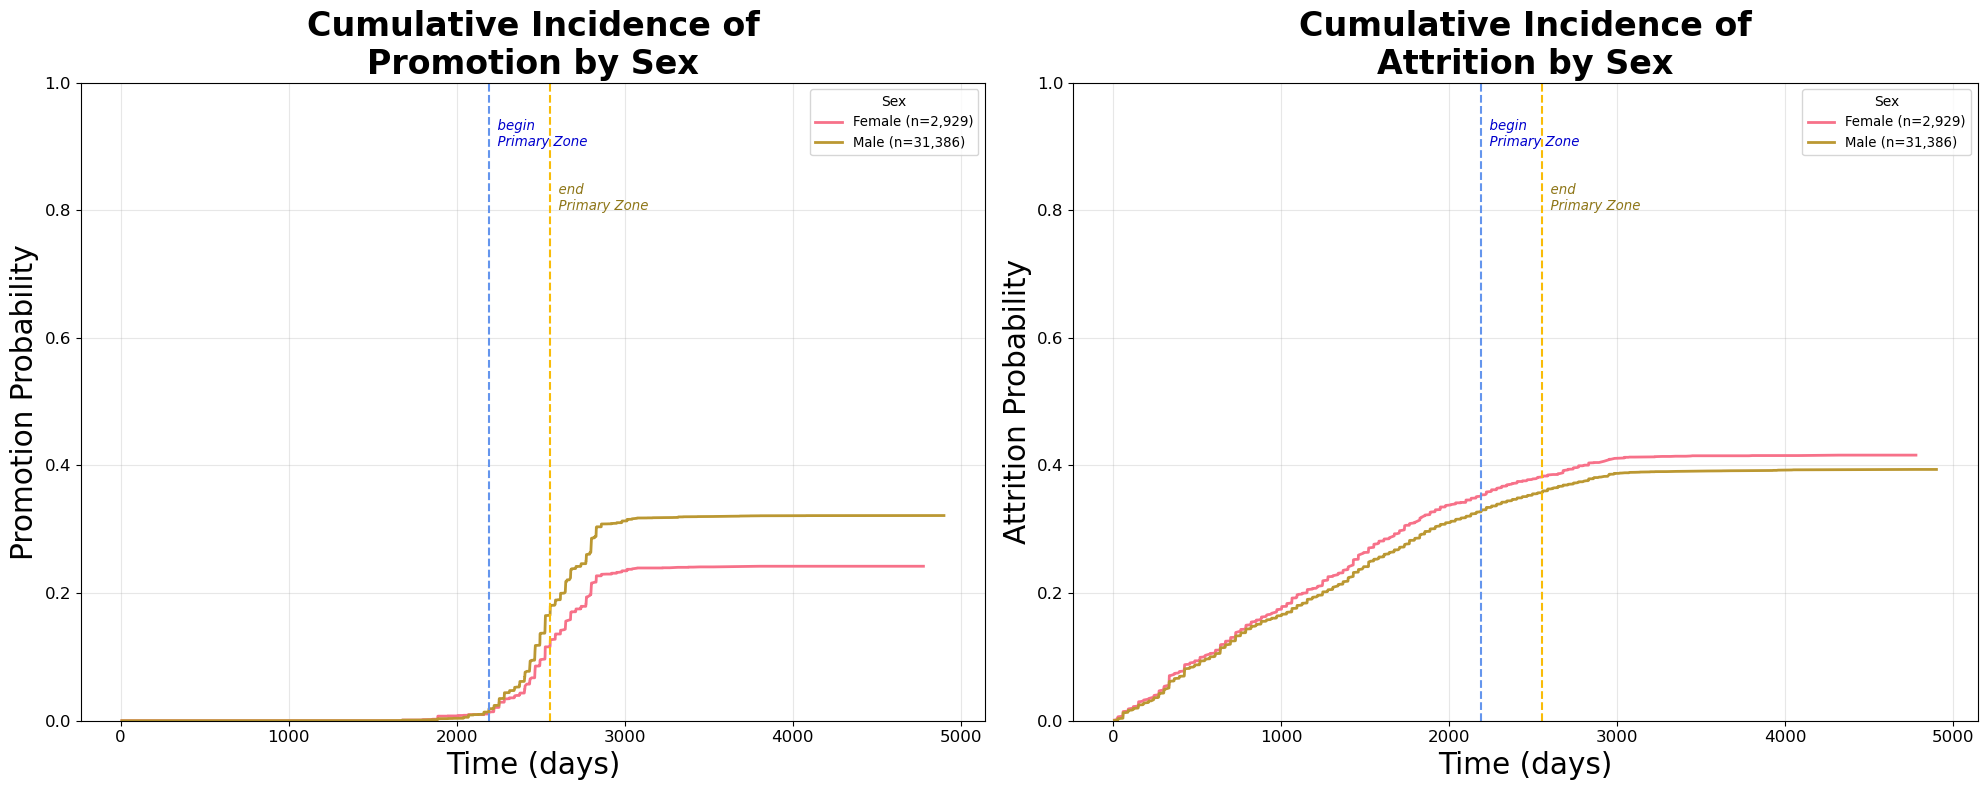


🔍 Competing Risks Analysis by Year Group:
📊 Year Groups chosen: [2006, 2007, 2008, 2009, 2010, 2011, 2012]
✅ Competing risks plot saved: plots/competing_risks_yg.png


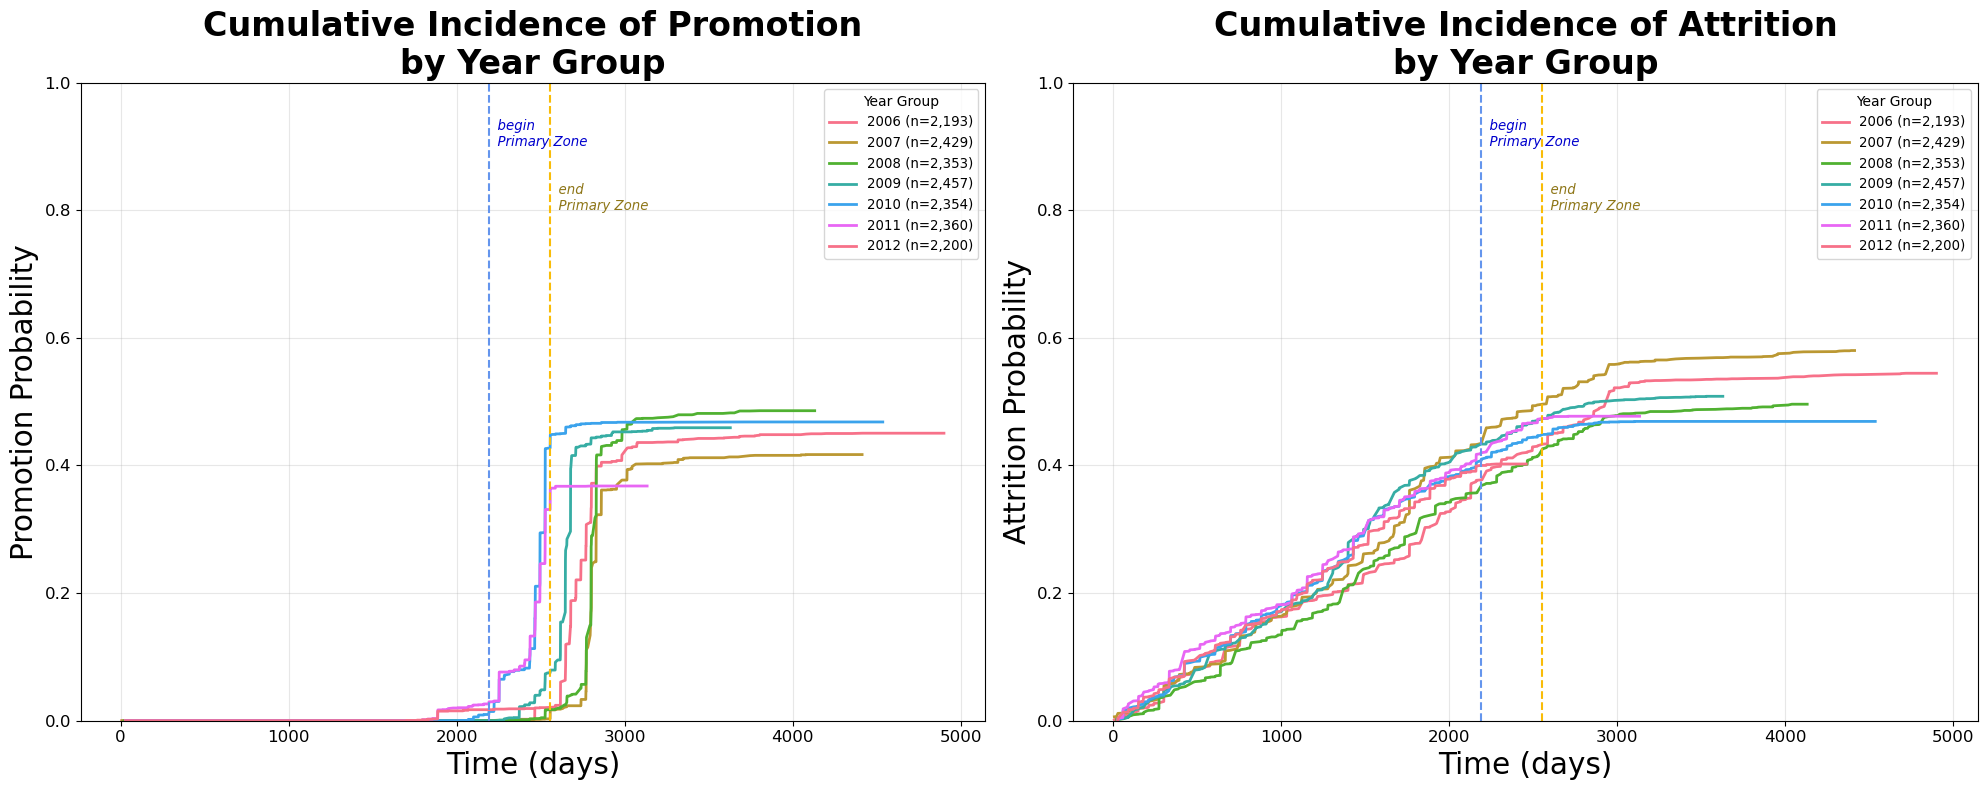


🔍 Competing Risks Analysis by Final Job Code:
📊 Final Job Codes chosen: ['IN', 'AR', 'FA', 'SC', 'AV', 'AD']
✅ Competing risks plot saved: plots/competing_risks_final_jc.png


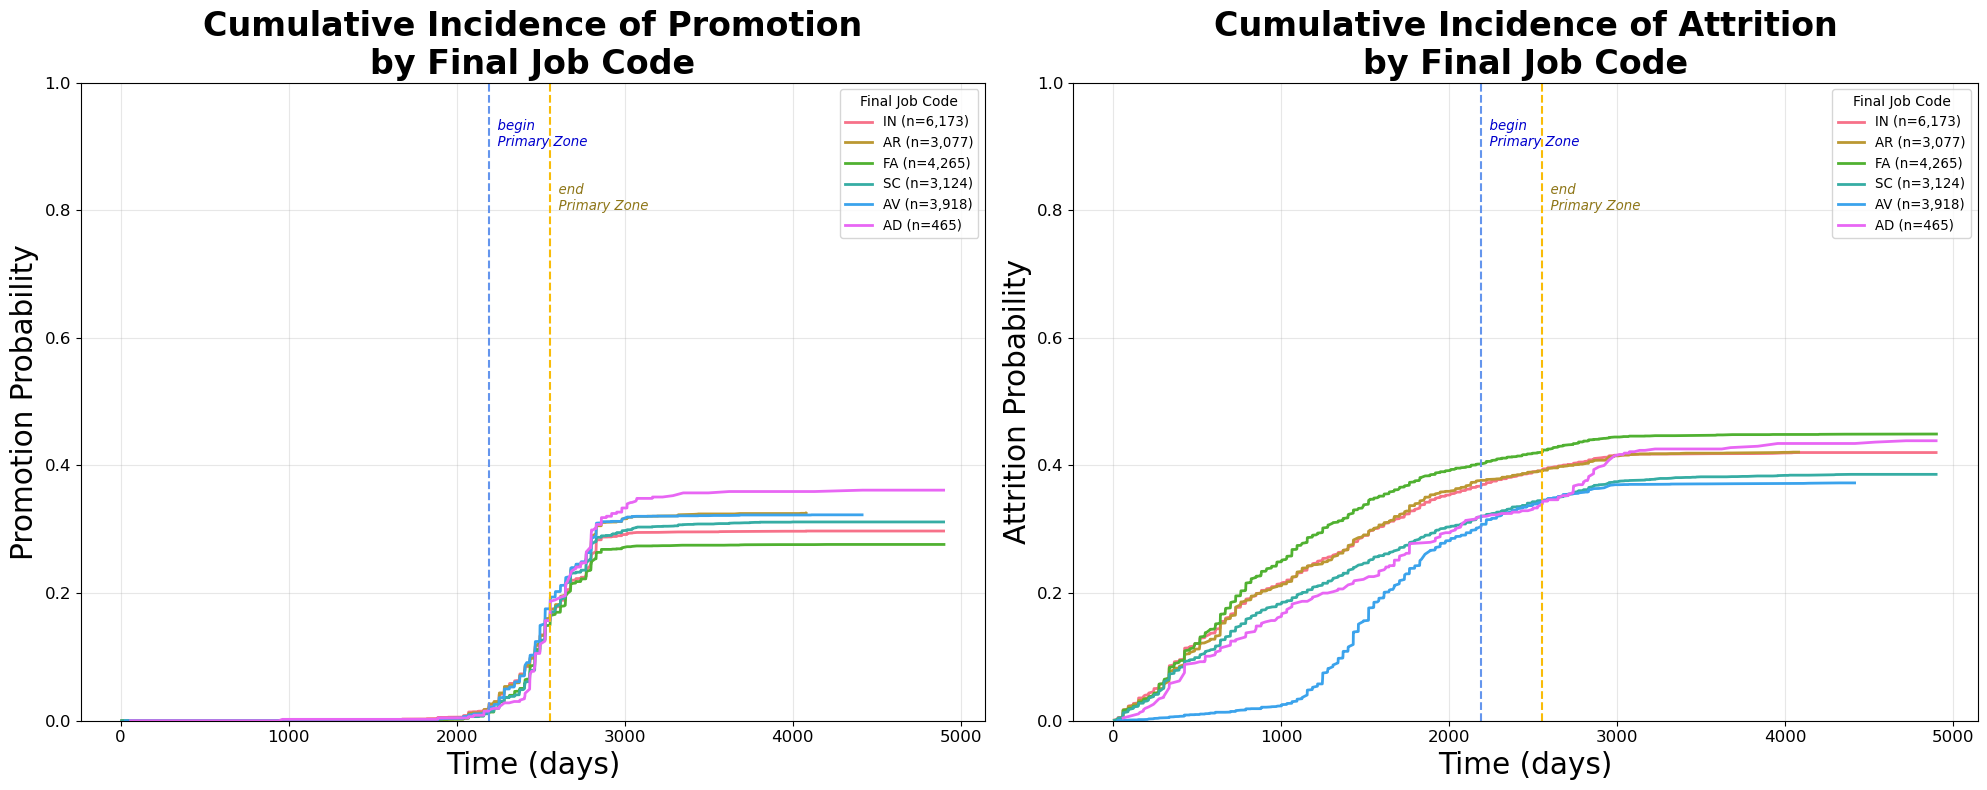


📊 Final Rate Verification:
  • Promotion rates should plateau at actual rates:
    - Males: 32.2%
    - Females: 24.3%
  • Attrition rates should plateau at remaining rates:
    - Males: 67.8%
    - Females: 75.7%

✅ Competing risks analysis completed!
🎯 Next: Cox regression analysis with scikit-survival


'11/19/2025 17:24:00'

In [88]:
# === CELL 10: COMPETING RISKS ANALYSIS (CIF) ===
# Use custom Cumulative Incidence Function for realistic promotion curves

print("\n=== COMPETING RISKS ANALYSIS (CIF) ===\n")

# === 10.1. CUSTOM CUMULATIVE INCIDENCE FUNCTION ===
print("🔧 Creating custom Cumulative Incidence Function for competing risks...")

def calculate_cumulative_incidence(group_data, event_type, time_col='follow_up_days'):
    """
    Calculate cumulative incidence function for competing risks
    This properly accounts for competing events and gives realistic rates
    """
    # Get event indicators - handle both old and new data structures
    if 'competing_event' in group_data.columns:
        # Old structure (officer-level data)
        if event_type == 'promotion':
            event_indicator = (group_data['competing_event'] == 1).astype(int)
        elif event_type == 'attrition':
            event_indicator = (group_data['competing_event'] == 2).astype(int)
    else:
        # New structure (time-varying survival data)
        if event_type == 'promotion':
            event_indicator = (group_data['event'] == 1).astype(int)
        elif event_type == 'attrition':
            event_indicator = (group_data['event'] == 2).astype(int)
    
    # Get unique time points
    times = sorted(group_data[time_col].unique())
    
    # Calculate cumulative incidence
    cumulative_incidence = []
    
    # Use correct denominator based on data structure
    if 'competing_event' in group_data.columns:
        # Officer-level data: use total number of officers
        total_population = len(group_data)
    else:
        # Time-varying data: use total number of UNIQUE officers
        total_population = group_data['pid_pde'].nunique()
    
    for t in times:
        # Number of events at time t
        events_at_t = ((group_data[time_col] == t) & (event_indicator == 1)).sum()
        
        # Calculate cumulative incidence as proportion of TOTAL population
        if len(cumulative_incidence) == 0:
            ci = events_at_t / total_population
        else:
            ci = cumulative_incidence[-1] + (events_at_t / total_population)
        
        cumulative_incidence.append(ci)
    
    return times, cumulative_incidence

# === 10.2. COMPETING RISKS ANALYSIS BY SEX ===
print("\n🔍 Competing Risks Analysis by Sex:")

# Create figure for sex analysis
fig_sz = (20,8)
fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz = get_plot_scales(fig_sz)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)

# Plot 1: Cumulative Incidence of\nPromotion
for sex_val in [0, 1]:  # 0=female, 1=male
    sex_data = officer_data[officer_data['sex'] == sex_val]
    
    if len(sex_data) > 0:
        # Calculate cumulative incidence for promotion
        times_promo, ci_promo = calculate_cumulative_incidence(sex_data, 'promotion')
        ax1.plot(times_promo, ci_promo, 
                linewidth=2, label=f"{legend_dict['sex'][sex_val]} (n={len(sex_data):,})")
        
        # Plot 2: Cumulative Incidence of\nAttrition
        times_attr, ci_attr = calculate_cumulative_incidence(sex_data, 'attrition')
        ax2.plot(times_attr, ci_attr, 
                linewidth=2, label=f"{legend_dict['sex'][sex_val]} (n={len(sex_data):,})")


# Customize promotion plot
ax1.set_title('Cumulative Incidence of\nPromotion by Sex', fontsize=title_sz, fontweight='bold')
ax1.set_xlabel('Time (days)', fontsize=axis_sz)
ax1.set_ylabel('Promotion Probability', fontsize=axis_sz)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Sex', loc='best', fontsize=lgnd_sz)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)

# Customize attrition plot
ax2.set_title('Cumulative Incidence of\nAttrition by Sex', fontsize=title_sz, fontweight='bold')
ax2.set_xlabel('Time (days)', fontsize=axis_sz)
ax2.set_ylabel('Attrition Probability', fontsize=axis_sz)
ax2.grid(True, alpha=0.3)
ax2.legend(title='Sex', loc='best', fontsize=lgnd_sz)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)

plt.tight_layout()
plt.savefig(plot_dir + '/competing_risks_sex.png', dpi=300, bbox_inches='tight')
print("✅ Competing risks plot saved: plots/competing_risks_sex.png")
plt.show()

# # === 10.3. COMPETING RISKS ANALYSIS BY CPT Prestige Experience ===
# print("\n🔍 Competing Risks Analysis by CPT Prestige Experience:")

# # Create figure for prestige analysis
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)

# # Plot 1: Cumulative Incidence of\nPromotion
# for prestige_val in [0, 1]:  # 0=no prestige, 1=prestige
#     prestige_data = officer_data[officer_data['prestige_cpt'] == prestige_val]
    
#     if len(prestige_data) > 0:
#         # Calculate cumulative incidence for promotion
#         times_promo, ci_promo = calculate_cumulative_incidence(prestige_data, 'promotion')
#         ax1.plot(times_promo, ci_promo, 
#                 linewidth=2, label=f"Prestige {prestige_val} (n={len(prestige_data):,})")
        
#         # Plot 2: Cumulative Incidence of\nAttrition
#         times_attr, ci_attr = calculate_cumulative_incidence(prestige_data, 'attrition')
#         ax2.plot(times_attr, ci_attr, 
#                 linewidth=2, label=f"Prestige {prestige_val} (n={len(prestige_data):,})")

# # Customize promotion plot
# ax1.set_title('Cumulative Incidence of Promotion\nby CPT Prestige Experience', fontsize=title_sz, fontweight='bold')
# ax1.set_xlabel('Time (days)', fontsize=axis_sz)
# ax1.set_ylabel('Promotion Probability', fontsize=axis_sz)
# ax1.grid(True, alpha=0.3)
# ax1.legend(title='CPT Prestige Experience', loc='best', fontsize=lgnd_sz)
# ax1.set_ylim(0, 1)
# ax1.tick_params(axis='both', which='major', labelsize=tick_sz)
# insert_pz_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
# insert_az_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)

# # Customize attrition plot
# ax2.set_title('Cumulative Incidence of Attrition\nby CPT Prestige Experience', fontsize=title_sz, fontweight='bold')
# ax2.set_xlabel('Time (days)', fontsize=axis_sz)
# ax2.set_ylabel('Attrition Probability', fontsize=axis_sz)
# ax2.grid(True, alpha=0.3)
# ax2.legend(title='CPT Prestige Experience', loc='best', fontsize=lgnd_sz)
# ax2.set_ylim(0, 1)
# ax2.tick_params(axis='both', which='major', labelsize=tick_sz)
# insert_pz_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
# insert_az_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)
    
# plt.tight_layout()
# plt.savefig(plot_dir + '/competing_risks_prestige.png', dpi=300, bbox_inches='tight')
# print("✅ Competing risks plot saved: plots/competing_risks_prestige.png")
# plt.show()

# === 10.4. COMPETING RISKS ANALYSIS BY YEAR GROUP ===
print("\n🔍 Competing Risks Analysis by Year Group:")

# Create figure for Year Group analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)

# Get unique Year Groups
ygs = officer_data['yg'].unique()

# Choose Year Groups
ygs = [2006,2007,2008,2009,2010,2011,2012]
print(f"📊 Year Groups chosen: {ygs}")

# Plot 1: Cumulative Incidence of Promotion
for yg in ygs:
    yg_data = officer_data[officer_data['yg'] == yg]
    
    if len(yg_data) > 0:
        # Calculate cumulative incidence for promotion
        times_promo, ci_promo = calculate_cumulative_incidence(yg_data, 'promotion')
        ax1.plot(times_promo, ci_promo, 
                linewidth=2, label=f"{yg} (n={len(yg_data):,})")
        
        # Plot 2: Cumulative Incidence of Attrition
        times_attr, ci_attr = calculate_cumulative_incidence(yg_data, 'attrition')
        ax2.plot(times_attr, ci_attr, 
                linewidth=2, label=f"{yg} (n={len(yg_data):,})")

# handles, labels = ax1.get_legend_handles_labels()
# print(f"Handles: {handles}")
# print(f"Labels: {labels}")

# Customize promotion plot
ax1.set_title('Cumulative Incidence of Promotion\nby Year Group', fontsize=title_sz, fontweight='bold')
ax1.set_xlabel('Time (days)', fontsize=axis_sz)
ax1.set_ylabel('Promotion Probability', fontsize=axis_sz)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Year Group', loc='best', fontsize=lgnd_sz)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)

# Customize attrition plot
ax2.set_title('Cumulative Incidence of Attrition\nby Year Group', fontsize=title_sz, fontweight='bold')
ax2.set_xlabel('Time (days)', fontsize=axis_sz)
ax2.set_ylabel('Attrition Probability', fontsize=axis_sz)
ax2.grid(True, alpha=0.3)
ax2.legend(title='Year Group', loc='best', fontsize=lgnd_sz)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)
    
plt.tight_layout()
plt.savefig(plot_dir + '/competing_risks_yg.png', dpi=300, bbox_inches='tight')
print("✅ Competing risks plot saved: plots/competing_risks_yg.png")
plt.show()

# === 10.5. COMPETING RISKS ANALYSIS BY FINAL JOB CODE ===
print("\n🔍 Competing Risks Analysis by Final Job Code:")

# Create figure for Final Job Code analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)

# Get unique Final Job Codes
final_job_codes = officer_data['final_job_code'].unique()

# Choose Final Job Codes
final_job_codes = ['IN','AR','FA','SC','AV','AD']
print(f"📊 Final Job Codes chosen: {final_job_codes}")

# Plot 1: Cumulative Incidence of Promotion
for final_job_code in final_job_codes:
    final_job_code_data = officer_data[officer_data['final_job_code'] == final_job_code]
    
    if len(final_job_code_data) > 0:
        # Calculate cumulative incidence for promotion
        times_promo, ci_promo = calculate_cumulative_incidence(final_job_code_data, 'promotion')
        ax1.plot(times_promo, ci_promo, 
                linewidth=2, label=f"{final_job_code} (n={len(final_job_code_data):,})")
        
        # Plot 2: Cumulative Incidence of Attrition
        times_attr, ci_attr = calculate_cumulative_incidence(final_job_code_data, 'attrition')
        ax2.plot(times_attr, ci_attr, 
                linewidth=2, label=f"{final_job_code} (n={len(final_job_code_data):,})")

# Customize promotion plot
ax1.set_title('Cumulative Incidence of Promotion\nby Final Job Code', fontsize=title_sz, fontweight='bold')
ax1.set_xlabel('Time (days)', fontsize=axis_sz)
ax1.set_ylabel('Promotion Probability', fontsize=axis_sz)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Final Job Code', loc='best', fontsize=lgnd_sz)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax1, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)

# Customize attrition plot
ax2.set_title('Cumulative Incidence of Attrition\nby Final Job Code', fontsize=title_sz, fontweight='bold')
ax2.set_xlabel('Time (days)', fontsize=axis_sz)
ax2.set_ylabel('Attrition Probability', fontsize=axis_sz)
ax2.grid(True, alpha=0.3)
ax2.legend(title='Final Job Code', loc='best', fontsize=lgnd_sz)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', which='major', labelsize=tick_sz)
insert_pz_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c1, c2)
insert_az_line(ax2, pz_ref_line, 0, fnt_sz, ref_ln_label_sz, c3, c4)
    
plt.tight_layout()
plt.savefig(plot_dir + '/competing_risks_final_jc.png', dpi=300, bbox_inches='tight')
print("✅ Competing risks plot saved: plots/competing_risks_final_jc.png")
plt.show()


# === 10.6. VERIFY FINAL RATES ===
print("\n📊 Final Rate Verification:")
print("  • Promotion rates should plateau at actual rates:")
print(f"    - Males: {male_promo_rate:.1%}")
print(f"    - Females: {female_promo_rate:.1%}")
print("  • Attrition rates should plateau at remaining rates:")
print(f"    - Males: {1-male_promo_rate:.1%}")
print(f"    - Females: {1-female_promo_rate:.1%}")

print("\n✅ Competing risks analysis completed!")
print("🎯 Next: Cox regression analysis with scikit-survival")
tyme()

# **📈 CELL 11: CREATE TIME-VARYING SURVIVAL DATA**

##### **Expand Officer Data into Interval-Based Survival Data**
- **Time-Varying Covariates**: `div_name`, `asg_uic_pde`, `rank_pde`
- **Interval-Based Structure**: Each officer's time split into intervals
- **Event Indicators**: Promotion (1), Attrition (2), No Event (0) per interval
- **scikit-survival Format**: Ready for Cox regression with time-varying covariates

##### **Focus**: Create interval-based survival data for time-varying Cox regression analysis


In [89]:
# === CELL 11: CREATE TIME-VARYING SURVIVAL DATA ===
# Expand officer data into interval-based survival data for time-varying covariates

print("\n=== CREATE TIME-VARYING SURVIVAL DATA ===\n")

# === 11.1. LOAD FILTERED SNAPSHOT DATA ===
print("🔧 Loading filtered snapshot data for time-varying analysis...")
# df_snapshots = load_feather('df_final_base_merged_node_cols')
df_snapshots = load_feather('df_filtered_post_filtering')

print(f"✅ Snapshot data loaded: {df_snapshots.shape}")
print(f"📊 Officers: {df_snapshots['pid_pde'].nunique():,}")
print(f"📊 Snapshots: {len(df_snapshots):,}")

# === 11.2. CREATE INTERVAL-BASED SURVIVAL DATA ===
print("\n🔧 Creating interval-based survival data...")

# Get unique officers with their key dates
officer_dates = df_snapshots.groupby('pid_pde').agg({
    'sex': 'first',
    'yg': 'first',
    'age_cpt': 'first', 
    'final_job_code': 'first',
    'dor_cpt': 'first',
    'dor_maj': 'first',
    'snpsht_dt': ['min', 'max']  # First and last snapshot dates
}).reset_index()

# Flatten column names
officer_dates.columns = ['pid_pde', 'sex', 'yg', 'age_cpt', 'final_job_code',
                         'dor_cpt', 'dor_maj', 'first_snapshot', 'last_snapshot']

print(f"✅ Officer dates created: {officer_dates.shape}")
tyme()

# === 11.3. CREATE SURVIVAL INTERVALS (VECTORIZED) ===
print("🔧 Creating survival intervals for each officer (vectorized)...")

# Study end date
study_end_date = df_snapshots['snpsht_dt'].max()

# Sort snapshots by officer and date for efficient processing
df_snapshots_sorted = df_snapshots.sort_values(by=['pid_pde','snpsht_dt']).reset_index(drop=True)

# Create time-varying survival data using vectorized operations
survival_data_list = []

# Identify scope of officer_snapshots loop
total_pids = df_snapshots_sorted.pid_pde.nunique()
report_portion = 20
mile_stone = int(total_pids/report_portion)
print(f"About to process {total_pids:,} officers, reporting progress every {mile_stone:,} individuals")

# Group by officer and process each group
pid_count = 0
for pid, officer_snapshots in df_snapshots_sorted.groupby('pid_pde'):
    officer_snapshots = officer_snapshots.reset_index(drop=True)

    # Get officer-level data
    officer_info = officer_dates[officer_dates['pid_pde'] == pid].iloc[0]
    
    # Create intervals between snapshots
    n_snapshots = len(officer_snapshots)

    if n_snapshots == 0:
        continue
    
    # Create start times (vectorized)
    start_times = np.zeros(n_snapshots)
    start_times[1:] = (officer_snapshots['snpsht_dt'].iloc[1:] - officer_info['dor_cpt']).dt.days

    # Create end times (vectorized)
    end_times = np.zeros(n_snapshots)

    # For all but last snapshot: end at next snapshot
    if n_snapshots > 1:
        end_times[:-1] = (officer_snapshots['snpsht_dt'].iloc[1:] - officer_info['dor_cpt']).dt.days

    # For last snapshot: determine based on competing event
    if pd.notna(officer_info['dor_maj']):
        # Promoted - end at promotion date
        end_times[-1] = (officer_info['dor_maj'] - officer_info['dor_cpt']).days
        events = np.zeros(n_snapshots)
        events[-1] = 1 # Promoted
    elif officer_info['last_snapshot'] < study_end_date:
        # Attritted - end at last snapshot
        end_times[-1] = (officer_info['last_snapshot'] - officer_info['dor_cpt']).days
        events = np.zeros(n_snapshots)
        events[-1] = 2 # Attrited
    else:
        # Censored - end at study end
        end_times[-1] = (study_end_date - officer_info['dor_cpt']).days
        events = np.zeros(n_snapshots)
        events[-1] = 0 # Censored

    # Create survival records (vecotized)
    survival_records = pd.DataFrame({
        'pid_pde': pid,
        'start_time': start_times,
        'end_time': end_times,
        'event': events,
        'sex': officer_info['sex'],
        'age_cpt': officer_info['age_cpt'],
        'yg': officer_info['yg'],
        'final_job_code': officer_info['final_job_code'],
        # Time-varying covariates from snapshots
        'div_name': officer_snapshots['div_name'].fillna('Unknown'),
        # 'div_name_x': officer_snapshots['div_name_x'].fillna('Unknown'),
        # 'div_name_y': officer_snapshots['div_name_y'].fillna('Unknown'),
        # 'eigen_div': officer_snapshots['eigen_div'].fillna('Unknown'),
        # 'eigen_div': officer_snapshots['eigen_div'],
        # 'eigen_mean': officer_snapshots['eigen_mean'],
        # 'eigen_sum': officer_snapshots['eigen_sum'],
        'prestige_unit': officer_snapshots['prestige_unit'],
        'prestige_sum': officer_snapshots['prestige_sum'],
        'prestige_mean': officer_snapshots['prestige_mean'],
        # 'rater_pool_ps_mean': officer_snapshots['rater_pool_ps_mean'],
        # 'rater_pool_pm_mean': officer_snapshots['rater_pool_pm_mean'],
        # 'sr_pool_ps_mean': officer_snapshots['sr_pool_ps_mean'],
        # 'sr_pool_pm_mean': officer_snapshots['sr_pool_pm_mean'],
        # Command echelon identifiers (for pool eligibility and clustering)
        # 'co_cmd': officer_snapshots['sr_pool_ps_mean'],
        # 'bn_cmd': officer_snapshots['sr_pool_ps_mean'],
        # 'bde_cmd': officer_snapshots['sr_pool_ps_mean'],
        # 'div_cmd': officer_snapshots['sr_pool_ps_mean'],
        'asg_uic_pde': officer_snapshots['asg_uic_pde'].fillna('Unknown'),
        'rank_pde': officer_snapshots['rank_pde'].fillna('CPT'),
        'married': officer_snapshots['married'].fillna(0),  # Add married as time-varying
        'snpsht_dt': officer_snapshots['snpsht_dt'],
        'cum_tb_recvd_rtr': officer_snapshots['cum_tb_recvd_rtr'],
        'cum_rated_evals_rtr': officer_snapshots['cum_rated_evals_rtr'],
        'cum_tb_recvd_snr': officer_snapshots['cum_tb_recvd_snr'],
        'cum_rated_evals_snr': officer_snapshots['cum_rated_evals_snr'],        
        'co_grade_tb': officer_snapshots['co_grade_tb'],        
        'co_grade_evals': officer_snapshots['co_grade_evals'],        
        'field_grade_tb': officer_snapshots['field_grade_tb'],        
        'field_grade_evals': officer_snapshots['field_grade_evals'],        
        'last4_tb': officer_snapshots['last4_tb'],        
        'last4_evals': officer_snapshots['last4_evals'],        
        'cum_tb_recvd_ratio_rtr': officer_snapshots['cum_tb_recvd_ratio_rtr'],        
        'cum_tb_recvd_ratio_snr': officer_snapshots['cum_tb_recvd_ratio_snr'],        
        'co_grd_tb_ratio': officer_snapshots['co_grd_tb_ratio'],        
        'field_grade_tb_ratio': officer_snapshots['field_grade_tb_ratio'],        
        'last4_tb_ratio': officer_snapshots['last4_tb_ratio']   
    })

    survival_data_list.append(survival_records)
    pid_count += 1
    if pid_count%mile_stone == 0:
        print(f"    ----  {pid_count:,} officers of {total_pids:,} officers complete ({(pid_count/total_pids):.0%}) at {tyme()}")
# Concatenate all survival records
df_survival = pd.concat(survival_data_list, ignore_index=True)

print(f"✅ Survival data created: {df_survival.shape}")
print(f"📊 Intervals per officer: {df_survival.groupby('pid_pde').size().describe()}")

# === 11.4. VERIFY SURVIVAL DATA ===
print("\n📊 Survival Data Verification:")

# Check event distribution
event_counts = df_survival[['pid_pde','event']].drop_duplicates()['event'].value_counts().sort_index()
event_pcts = df_survival[['pid_pde','event']].drop_duplicates()['event'].value_counts(normalize=True).sort_index()

event_names = {0: 'No Event', 1: 'Promoted', 2: 'Attrited'}
for event, count in event_counts.items():
    pct = event_pcts[event]
    print(f"  • {event_names[event]}: {count:,} officers ({pct:.0%})")

# Check time-varying covariates
print(f"\n📊 Time-Varying Covariates:")
# print(f"  • div_name_x values: {df_survival['div_name_x'].nunique()} unique")
# print(f"  • div_name_y values: {df_survival['div_name_y'].nunique()} unique")
print(f"  • div_name values: {df_survival['div_name'].nunique()} unique")
print(f"  • asg_uic_pde values: {df_survival['asg_uic_pde'].nunique()} unique")

# Check interval lengths
df_survival['interval_length'] = df_survival['end_time'] - df_survival['start_time']
print(f"\n📊 Interval Statistics:")
print(f"  • Mean interval length: {df_survival['interval_length'].mean():.1f} days")
print(f"  • Median interval length: {df_survival['interval_length'].median():.1f} days")
print(f"  • Max interval length: {df_survival['interval_length'].max():.1f} days")

print("\n✅ Time-varying survival data created!")

# === 11.5. SAVE RESULTS ===
print_v("\n📊 Saving time-varying survival data...")
store_feather(df_survival, 'df_survival')
print_v(f"✅ Time-varying survival data saved: {df_survival.shape}")

print("🎯 Next: Competing risks analysis with time-varying covariates")
tyme()


=== CREATE TIME-VARYING SURVIVAL DATA ===

🔧 Loading filtered snapshot data for time-varying analysis...
 df_filtered_post_filtering Loaded!!  - (00.50 seconds and 527.296 MB of memory)
✅ Snapshot data loaded: (894676, 76)
📊 Officers: 34,504
📊 Snapshots: 894,676

🔧 Creating interval-based survival data...
✅ Officer dates created: (34504, 9)
🔧 Creating survival intervals for each officer (vectorized)...
About to process 34,504 officers, reporting progress every 1,725 individuals
    ----  1,725 officers of 34,504 officers complete (5%) at 11/19/2025 17:24:27
    ----  3,450 officers of 34,504 officers complete (10%) at 11/19/2025 17:24:37
    ----  5,175 officers of 34,504 officers complete (15%) at 11/19/2025 17:24:46
    ----  6,900 officers of 34,504 officers complete (20%) at 11/19/2025 17:24:58
    ----  8,625 officers of 34,504 officers complete (25%) at 11/19/2025 17:25:07
    ----  10,350 officers of 34,504 officers complete (30%) at 11/19/2025 17:25:16
    ----  12,075 officer

'11/19/2025 17:27:36'

# **🔍 CELL 12: COX REGRESSION WITH TIME-VARYING COVARIATES**

##### **Fit Cox Models with Static and Time-Varying Predictors**
- **Static Model**: `sex`, `age_cpt`, `yg_2002` only
- **Full Model**: Static variables + time-varying `div_name` dummy variables
- **Signal Ratios**: Compare static vs. full model performance
- **Partial Effects**: Visualize individual variable effects on promotion signal

##### **Focus**: Cox regression analysis with both static and time-varying covariates


In [90]:
# === CELL 12: COX REGRESSION WITH TIME-VARYING COVARIATES ===
# Fit Cox model with time-varying covariates using scikit-survival

print("\n=== COX REGRESSION WITH TIME-VARYING COVARIATES ===\n")

# === 12.1. PREPARE DATA FOR COX REGRESSION ===
print("🔧 Preparing data for Cox regression with time-varying covariates...")

# Create dummy variables for categorical time-varying covariates
df_survival = load_feather('df_survival')
df_cox = df_survival.copy()

# Create dummy variables for div_name
# div_dummies = pd.get_dummies(df_cox['div_name_x'], prefix='div')
div_dummies = pd.get_dummies(df_cox['div_name'], prefix='div')
df_cox = pd.concat([df_cox, div_dummies], axis=1)

# married is already binary (0/1), no need for dummy variables

print(f"✅ Cox data prepared: {df_cox.shape}")
print(f"📊 Variables: {list(df_cox.columns)}")

# === 12.2. FIT COX MODEL WITH STATIC VARIABLES ONLY ===
print("\n🔍 Fitting Cox model with static variables only...")

# Select only static variables (excluding 'yg' because of LAPAK errors)
static_vars = ['sex','age_cpt']

cox_static = df_cox[['start_time', 'end_time', 'event'] + static_vars].copy()

# Remove any missing values
cox_static = cox_static.dropna()

print(f"📊 Static model variables: {static_vars}")
print(f"📊 Sample size: {len(cox_static):,}")

# Create Surv object for static Cox regression
cox_surv_static = Surv.from_arrays(
    event=cox_static['event'] == 1,  # Promotion events only
    time=cox_static['end_time'] - cox_static['start_time']  # Duration of interval
)

# === 12.2.1. DATA QUALITY CHECKS FOR STATIC MODEL ===
print("\n🔍 Data Quality Checks for static model")

# Check for missing values
missing_counts = cox_static[static_vars].isnull().sum()
if missing_counts.sum() > 0:
    print("⚠️ Missing values found:")
    print(missing_counts[missing_counts > 0])
else:
    print("✅ No missing values")

# Check for infinite values
inf_counts = np.isinf(cox_static[static_vars]).sum()
if inf_counts.sum() > 0:
    print("⚠️ Infinite values found:")
    print(inf_counts[inf_counts > 0])
else:
    print("✅ No infinite values")

# Check for constant variables (zero variance)
constant_vars = []
for var in static_vars:
    if cox_static[var].nunique() <= 1:
        constant_vars.append(var)

if constant_vars:
    print(f"⚠️ Constant variables found: {constant_vars}")
    # Remove constant variables
    static_vars = [var for var in static_vars if var not in constant_vars]
    print(f"📊 Updated static variables: {static_vars}")
else:
    print("✅ No constant variables")

# Check for perfect separation
print("\n🔍 Perfect Separation Check:")
perfect_separation_vars = []

# Special check for 'yg' variable
if 'yg' in static_vars:
    print("\n🔍 Checking 'yg' variable specifically...")
    yg_event_counts = cox_static.groupby(['yg','event']).size().unstack(fill_value=0)
    print(f"📊 Year group event distribution:")
    print(yg_event_counts)

    #Check for year groups with no event or all events
    for yg_val in cox_static.yg.unique():
        yg_data = cox_static[cox_static.yg == yg_val]
        events = yg_data.event.sum()
        total = len(yg_data)
        if events == 0:
            print(f"⚠️ Year group {yg_val}: {total} officers, 0 promotions (perfect separation)")
            perfect_separation_vars.append('yg')
        elif events == total:
            print(f"⚠️ Year group {yg_val}: {total} officers, {events:,} promotions (perfect separation)")
            perfect_separation_vars.append('yg')
            
for var in static_vars:
    # Check all variables, including integers lik 'yg'
    if cox_static[var].dtype in ['object','category']:
        continue

    # Check if variable perfectly separates events
    event_0 = cox_static[cox_static['event'] == 0][var]
    event_1 = cox_static[cox_static['event'] == 1][var]

    if len(event_0) > 0 and len(event_1) > 0:
        if event_0.min() >= event_1.max() or event_1.min() >= event_1.max():
            print(f"⚠️ Perfect separation detected in: {var}")
            perfect_separation_vars.append(var)

# Remove variables with perfect separation
if perfect_separation_vars:
    print(f"🔧 Removing variables with perfect separation: {perfect_separation_vars}")
    static_vars = [var for var in static_vars if var not in perfect_separation_vars]
    print(f"📊 Updated static variables after removing perfect separation: {static_vars}")
    cox_static = df_cox[['start_time', 'end_time', 'event'] + static_vars].copy()
else:
    print("✅ No perfect separation variables")
        
# Check correlation matrix for high correlations
print("\n🔍 Correlation Check:")
corr_matrix = cox_static[static_vars].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.columns[i,j]))

if high_corr_pairs:
    print(f"⚠️ High correlations found:")
    for var1, var2, corr in high_corr_pairs:
        print(f"  • {var1} vs {var2}: {corr:.3f}")
else:
    print("✅ No high correlations")

# === 12.2.2 ATTEMPT COX MODEL FITTING ===
print("\n🔍 Attempting TO FIT static Cox model...")
print("DEBUG!! with static_vars = ", static_vars)
try:
    cph_static = CoxPHSurvivalAnalysis()  # No regularization first
    cph_static.fit(cox_static[static_vars], cox_surv_static)
    print("✅ Static Cox model fitted successfully!")
except Exception as e:
    print(f"❌ Basic fit failed: {e}")
    
    # Try with regularization to handel numerical issues
    print("\n🔍 Attempting static Cox model fit with regulariztion...")
    try:
        cph_static = CoxPHSurvivalAnalysis(alpha=0.1)  # Add regularization
        cph_static.fit(cox_static[static_vars], cox_surv_static)
        print("✅ Static Cox model fitted successfully with regularization!")
    except Exception as e2:
        print(f"❌ Regularized fit failed: {e2}")
    
        # Try with stronger regularization
        print("\n🔍 Trying with stronger regularization...")
        try:
            cph_static = CoxPHSurvivalAnalysis(alpha=1.0)  # Stronger regularization
            cph_static.fit(cox_static[static_vars], cox_surv_static)
            print("✅ Static Cox model fitted successfully with stronger regularization!")
        except Exception as e3:
            print(f"❌ Stronger regularization also failed: {e3}")
        
            # Try with fewer variables
            print("\n🔍 Trying with fewer variables...")
            reduced_static_vars = static_vars[:5]  # Use only first 5 variables
            print(f"📊 Reduced static variables: {reduced_static_vars}")
    
            try:
                cph_static = CoxPHSurvivalAnalysis(alpha=0.1)
                cph_static.fit(cox_static[reduced_static_vars], cox_surv_static)
                print("✅ Static Cox model fitted successfully with reduced variables!")
                static_vars = reduced_static_vars # Update static_vars for later use
            except Exception as e4:
                print(f"❌ Reduced model also failed: {e4}")
                print("🔍 This suggests a fundamental data issue.  Check for:")
                print("  • Perfect separation between groups")
                print("  • Too many dummy variables")
                print("  • Numerical instability in the data")
                raise e4
tyme()


=== COX REGRESSION WITH TIME-VARYING COVARIATES ===

🔧 Preparing data for Cox regression with time-varying covariates...
 df_survival Loaded!!  - (00.12 seconds and 218.427 MB of memory)
✅ Cox data prepared: (894676, 53)
📊 Variables: ['pid_pde', 'start_time', 'end_time', 'event', 'sex', 'age_cpt', 'yg', 'final_job_code', 'div_name', 'prestige_unit', 'prestige_sum', 'prestige_mean', 'asg_uic_pde', 'rank_pde', 'married', 'snpsht_dt', 'cum_tb_recvd_rtr', 'cum_rated_evals_rtr', 'cum_tb_recvd_snr', 'cum_rated_evals_snr', 'co_grade_tb', 'co_grade_evals', 'field_grade_tb', 'field_grade_evals', 'last4_tb', 'last4_evals', 'cum_tb_recvd_ratio_rtr', 'cum_tb_recvd_ratio_snr', 'co_grd_tb_ratio', 'field_grade_tb_ratio', 'last4_tb_ratio', 'interval_length', 'div_101ABN', 'div_10MTN', 'div_10SFG', 'div_160SOAR', 'div_1AD', 'div_1CAV', 'div_1ID', 'div_1SFG', 'div_25ID', 'div_2ID', 'div_3ID', 'div_3SFG', 'div_4ID', 'div_528SB', 'div_5SFG', 'div_75RR', 'div_7ID', 'div_7SFG', 'div_82ABN', 'div_REMF', 'di

'11/19/2025 17:27:57'

In [91]:
# === 12.3. FIT COX MODEL WITH STATIC + TIME-VARYING COVARIATES ===
print("\n🔍 Fitting Cox model with static + time-varying covariates...")

time_varying_vars = ['prestige_mean','cum_tb_recvd_ratio_rtr','cum_tb_recvd_ratio_snr','co_grd_tb_ratio','field_grade_tb_ratio','last4_tb_ratio']
time_varying_vars = ['cum_tb_recvd_ratio_snr']
model_vars = static_vars + time_varying_vars

# Remove any non-numeric columns that might have been included
# model_vars = [var for var in model_vars if var not in ['div_name_x', 'co_cmd', 'bn_cmd', 'bn_name', 'bde_cmd',
#                                                        'bde_name', 'div_name_y', 'asg_uic_pde', 'rank_pde', 'snpsht_dt']]
model_vars = [var for var in model_vars if var not in ['div_name', 'co_cmd', 'bn_cmd', 'bn_name', 'bde_cmd',
                                                       'bde_name', 'asg_uic_pde', 'rank_pde', 'snpsht_dt']]

print(f" model_vars after removing non-numeric columns: {model_vars}")

# === 12.3.0. REMOVE REDUNDANT VARIABLES ===
print("\n🔍 Removing redundant variables to prevent perfect separation...")

# Define cox_subset
cox_subset = df_cox[['start_time', 'end_time', 'event', 'yg'] + model_vars].copy()

# Update cox subset with the cleaned model_vars
cox_subset = df_cox[['start_time', 'end_time', 'event'] + model_vars].copy()

# Remove any missing values
cox_subset = cox_subset.dropna()

print(f"📊 Full model variables: {model_vars}")
print(f"📊 Sample size: {len(cox_subset):,}")

# === 12.3.1. DATA QUALITY CHECKS ===
print("\n🔍 Data Quality Checks")

# Check for missing values
missing_counts = cox_subset[model_vars].isnull().sum()
if missing_counts.sum() > 0:
    print("⚠️ Missing values found:")
    print(missing_counts[missing_counts > 0])
else:
    print("✅ No missing values")

# Check for infinite values
inf_counts = np.isinf(cox_subset[model_vars]).sum()
if inf_counts.sum() > 0:
    print("⚠️ Infinite values found:")
    print(inf_counts[inf_counts > 0])
else:
    print("✅ No infinite values")

# Check for constant variables (zero variance)
constant_vars = []
for var in model_vars:
    if cox_subset[var].nunique() <= 1:
        constant_vars.append(var)

if constant_vars:
    print(f"⚠️ Constant variables found: {constant_vars}")
    # Remove constant variables
    model_vars = [var for var in model_vars if var not in constant_vars]
    print(f"📊 Updated model variables: {model_vars}")
    print(inf_counts[inf_counts > 0])
else:
    print("✅ No constant variables")

# Check for perfect separation
print("\n🔍 Perfect Separation Check:")
perfect_separation_vars = []
for var in model_vars:
    if cox_subset[var].dtype in ['object','category']:
        continue

    # Check if variable perfectly separates events
    event_0 = cox_subset[cox_subset['event'] == 0][var]
    event_1 = cox_subset[cox_subset['event'] == 1][var]

    if len(event_0) > 0 and len(event_1) >0:
        if event_0.min() >= event_1.max() or event_1.min() >= event_1.max():
            print(f"⚠️ Perfect separation detected in: {var}")
            perfect_separation_vars.append(var)

# Remove variables with perfect separation
if perfect_separation_vars:
    print(f"🔧 Removing variables with perfect separation {perfect_separation_vars}")
    model_vars = [var for var in model_vars if var not in perfect_separation_vars]
    print(f"📊 Updated model variables after removing perfect separation: {model_vars}")
    cox_subset = df_cox[['start_time', 'end_time', 'event'] + model_vars].copy()
else:
    print("✅ No perfect separation variables")
        
# Check correlation matrix for high correlations
print("\n🔍 Correlation Check:")
corr_matrix = cox_subset[model_vars].corr()
######################   DEBUG   #####################
display("corr_matrix",corr_matrix)
display("corr_matrix.columns",corr_matrix.columns)
display("corr_matrix.size",corr_matrix.size)
display("corr_matrix.shape",corr_matrix.shape)
######################   DEBUG   #####################
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

if high_corr_pairs:
    print(f"⚠️ High correlations found:")
    for var1, var2, corr in high_corr_pairs:
        print(f"  • {var1} vs {var2}: {corr:.3f}")
else:
    print("✅ No high correlations")
    
# Create Surv object for full Cox regression
cox_surv = Surv.from_arrays(
    event=cox_subset['event'] == 1,  # Promotion events only
    time=cox_subset['end_time'] - cox_subset['start_time']  # Duration of interval
)
store_feather(cox_subset,'debug')

###### DEBUG   ###########
# model_vars = [var for var in model_vars if var not in['prestige_sum', 'sr_pool_ps_mean','rater_pool_ps_mean']]
#######   DEBUG   #############################

# === 12.3.2. ATTEMPT COX MODEL FITTING ===
print("\n🔍 Attempting to fit full Cox model...")
print("DEBUG!! with model_vars = ",model_vars)
try:
    cph = CoxPHSurvivalAnalysis()  # No regularization first
    cph.fit(cox_subset[model_vars], cox_surv)
    print("✅ Full Cox model fitted successfully!")
except Exception as e:
    print(f"❌ Basic fit failed: {e}")
    
    # Try with regularization to handel numerical issues
    print("\n🔍 Attempting full Cox model fit with regulariztion...")
    try:
        cph = CoxPHSurvivalAnalysis(alpha=0.1)  # Add regularization
        cph.fit(cox_subset[model_vars], cox_surv)
        print("✅ Full Cox model fitted successfully with regularization!")
    except Exception as e2:
        print(f"❌ Regularized fit failed: {e2}")
    
        # Try with stronger regularization
        print("\n🔍 Trying with stronger regularization...")
        try:
            cph = CoxPHSurvivalAnalysis(alpha=1.0)  # Stronger regularization
            cph.fit(cox_subset[model_vars], cox_surv)
            print("✅ Full Cox model fitted successfully with stronger regularization!")
        except Exception as e3:
            print(f"❌ Stronger regularization also failed: {e3}")
        
            # Try with fewer variables
            print("\n🔍 Trying with fewer variables...")
            reduced_vars = model_vars[:4] + ['cum_tb_recvd_ratio_snr'] # Use only first 4 variables + eigen_mean and eigen_sum
            # reduced_vars = model_vars[:4] + ['eigen_mean'] # Use only first 4 variables + eigen_mean and eigen_sum
            print(f"📊 Reduced  variables: {reduced_vars}")
    
            try:
                cph = CoxPHSurvivalAnalysis(alpha=0.1)
                cph.fit(cox_subset[reduced_vars], cox_surv)
                print("✅ Full Cox model fitted successfully with reduced variables!")
                model_vars = reduced_vars # Update model_vars for later use
            except Exception as e4:
                print(f"❌ Reduced model also failed: {e4}")
                print("🔍 This suggests a fundamental data issue.  Check for:")
                print("  • Perfect separation between groups")
                print("  • Too many dummy variables")
                print("  • Numerical instability in the data")
                raise e4

# === 12.4. MODEL RESULTS COMPARISON ===
print("\n📊 Cox Model Results Comparison:")

# Static model results
print("\n🔍 Static Variables Only Model:")
print("DEBUG!!!!!!!!!!!  Static Vars:",static_vars)
print("Signal Ratios:")
for i, var in enumerate(static_vars):
    sr = np.exp(cph_static.coef_[i])
    print(f"  • {var}: SR = {sr:.4f}")

# Calculate concordance index for static model
c_index_static = concordance_index_censored(
    cox_surv_static['event'], cox_surv_static['time'], cph_static.predict(cox_static[static_vars])
)[0]
print(f"  • Concordance Index: {c_index_static:.3f}")

# Full model results
print("\n🔍 Static + Time-Varying Variables Model:")
print("Signal Ratios:")
for i, var in enumerate(model_vars):
    sr = np.exp(cph.coef_[i])
    print(f"  • {var}: SR = {sr:.9f}")

# Calculate concordance index for full model
# c_index_full = concordance_index_censored(
#     cox_surv['event'], cox_surv['time'], cph.predict(cox_subset[model_vars])
# )[0]
# print(f"  • Concordance Index: {c_index_full:.3f}")
tyme()


🔍 Fitting Cox model with static + time-varying covariates...
 model_vars after removing non-numeric columns: ['sex', 'age_cpt', 'cum_tb_recvd_ratio_snr']

🔍 Removing redundant variables to prevent perfect separation...
📊 Full model variables: ['sex', 'age_cpt', 'cum_tb_recvd_ratio_snr']
📊 Sample size: 751,171

🔍 Data Quality Checks
✅ No missing values
✅ No infinite values
✅ No constant variables

🔍 Perfect Separation Check:
✅ No perfect separation variables

🔍 Correlation Check:


'corr_matrix'

,sex,age_cpt,cum_tb_recvd_ratio_snr
sex,1.000000,0.010793,0.049857
age_cpt,0.010793,1.000000,-0.119433
cum_tb_recvd_ratio_snr,0.049857,-0.119433,1.000000


'corr_matrix.columns'

Index(['sex', 'age_cpt', 'cum_tb_recvd_ratio_snr'], dtype='object')

...

9

'corr_matrix.shape'

(3, 3)

✅ No high correlations
 debug Stored!!  - (00.06 seconds and 40.117 MB of memory)

🔍 Attempting to fit full Cox model...
DEBUG!! with model_vars =  ['sex', 'age_cpt', 'cum_tb_recvd_ratio_snr']
✅ Full Cox model fitted successfully!

📊 Cox Model Results Comparison:

🔍 Static Variables Only Model:
DEBUG!!!!!!!!!!!  Static Vars: ['sex', 'age_cpt']
Signal Ratios:
  • sex: SR = 1.2180
  • age_cpt: SR = 0.9936
  • Concordance Index: 0.518

🔍 Static + Time-Varying Variables Model:
Signal Ratios:
  • sex: SR = 1.187136593
  • age_cpt: SR = 0.994821208
  • cum_tb_recvd_ratio_snr: SR = 1.012577799


'11/19/2025 17:29:16'

In [103]:
df_od = load_feather('df_with_cum_opm')
df_od = df_od[df_od.compo == 'R']
df_od = df_od.sort_values(by=['pid_pde','snpsht_dt'])
df_odf = df_od.drop_duplicates(subset=['pid_pde'],keep='last')

 df_with_cum_opm Loaded!!  - (06.79 seconds and 3,547.081 MB of memory)


In [ ]:
display(df_odf[df_odf.cum_rated_evals_rtr == 0])
zero_eval_snr_list = df_odf[df_odf.cum_rated_evals_snr == 0].eval_id.unique().to_list()
print(f"There are {len(zero_eval_rtr_list):,} unique evaluations with no rater, and {len(zero_eval_snr_list):,} with no senior rater")

For column cum_rated_evals_rtr, here is the distribution:


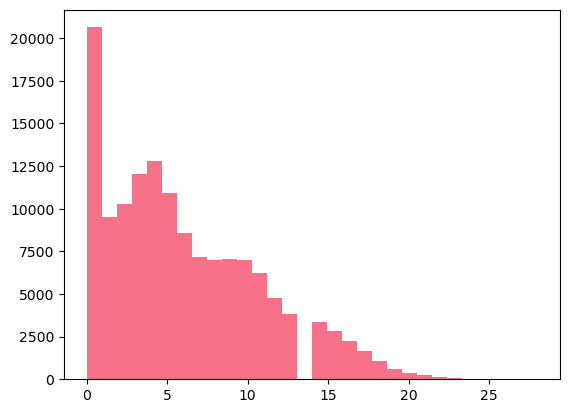

For column cum_tb_recvd_rtr, here is the distribution:


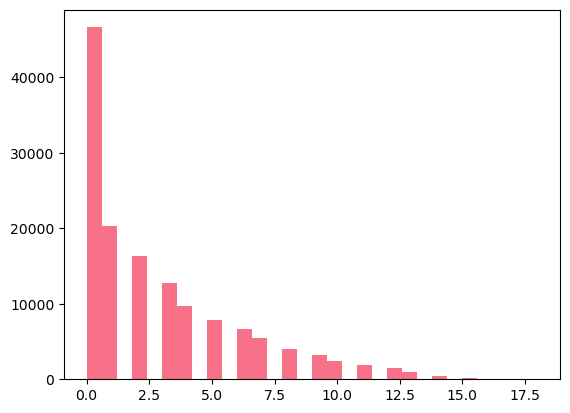

For column cum_rated_evals_snr, here is the distribution:


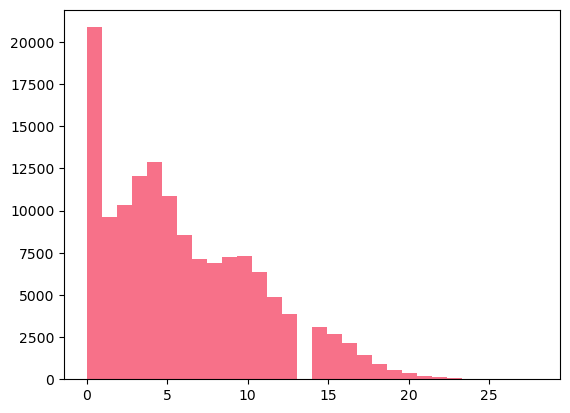

For column cum_tb_recvd_snr, here is the distribution:


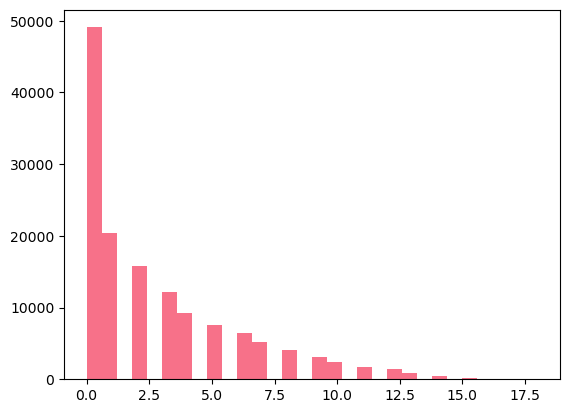

In [105]:
col_list = ['cum_rated_evals_rtr','cum_tb_recvd_rtr','cum_tb_recvd_ratio_rtr','cum_rated_evals_snr','cum_tb_recvd_snr','cum_tb_recvd_ratio_snr']
col_list = ['cum_rated_evals_rtr','cum_tb_recvd_rtr','cum_rated_evals_snr','cum_tb_recvd_snr']
for col in col_list:
    nums = df_odf[col].tolist()
    print(f"For column {col}, here is the distribution:")
    plt.hist(nums, bins = 30)
    plt.show()

In [77]:
dfbb = load_feather('df_512_base')

 df_512_base Loaded!!  - (02.20 seconds and 2,977.590 MB of memory)


In [84]:
def remove_no_oer_pids(df_in):
    dfbb = df_in.copy()
    gross_pids = dfbb.pid_pde.nunique()
    nan_pids = dfbb[(dfbb.cum_rated_evals_rtr.isna()) & (dfbb.cum_rated_evals_rtr.isna())].pid_pde.unique()
    print(f"There are {gross_pids:,} pids in df_base, and {len(nan_pids):,} of them have no rater and no senior rater data")
    dfbb = dfbb[~dfbb.pid_pde.isin(nan_pids)]
    net_pids = dfbb.pid_pde.unique()
    print(f" After dropping the OER null pids, there are {len(net_pids):,} officers remaining")
    return dfbb

(array([1.66199e+05, 0.00000e+00, 8.20000e+01, 9.51000e+02, 4.21800e+03,
        6.40000e+01, 6.27500e+03, 1.20070e+04, 1.99000e+03, 2.43830e+04,
        5.20000e+01, 8.59000e+02, 1.09340e+04, 3.14000e+02, 0.00000e+00,
        1.89600e+05, 1.47000e+02, 2.04400e+03, 9.60700e+03, 2.63900e+04,
        0.00000e+00, 1.49200e+03, 1.47180e+04, 5.20000e+01, 7.56700e+03,
        3.80900e+03, 1.41000e+02, 2.00000e+00, 0.00000e+00, 1.99564e+05]),
 array([  0.        ,   3.33333333,   6.66666667,  10.        ,
         13.33333333,  16.66666667,  20.        ,  23.33333333,
         26.66666667,  30.        ,  33.33333333,  36.66666667,
         40.        ,  43.33333333,  46.66666667,  50.        ,
         53.33333333,  56.66666667,  60.        ,  63.33333333,
         66.66666667,  70.        ,  73.33333333,  76.66666667,
         80.        ,  83.33333333,  86.66666667,  90.        ,
         93.33333333,  96.66666667, 100.        ]),
 <BarContainer object of 30 artists>)

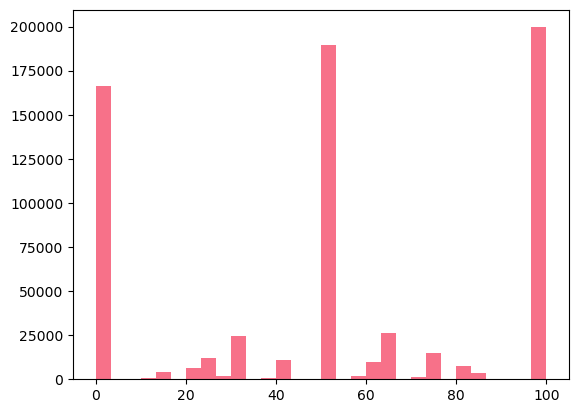

In [83]:
col = 'co_grd_tb_ratio'

nums = df_base[col].tolist()
plt.hist(nums, bins = 30)
# dfbb[col].unique().tolist()


📊 Plotting signal ratios comparison...
fnt_sz: 24, suptitl_sz: 36, title_sz: 24, axis_sz: 21, ref_ln_label_sz: 10, tick_sz: 12, lgnd_sz: 10
✅ Signal ratio comparison plot saved: plots/cox_signal_ratios_comparison.png


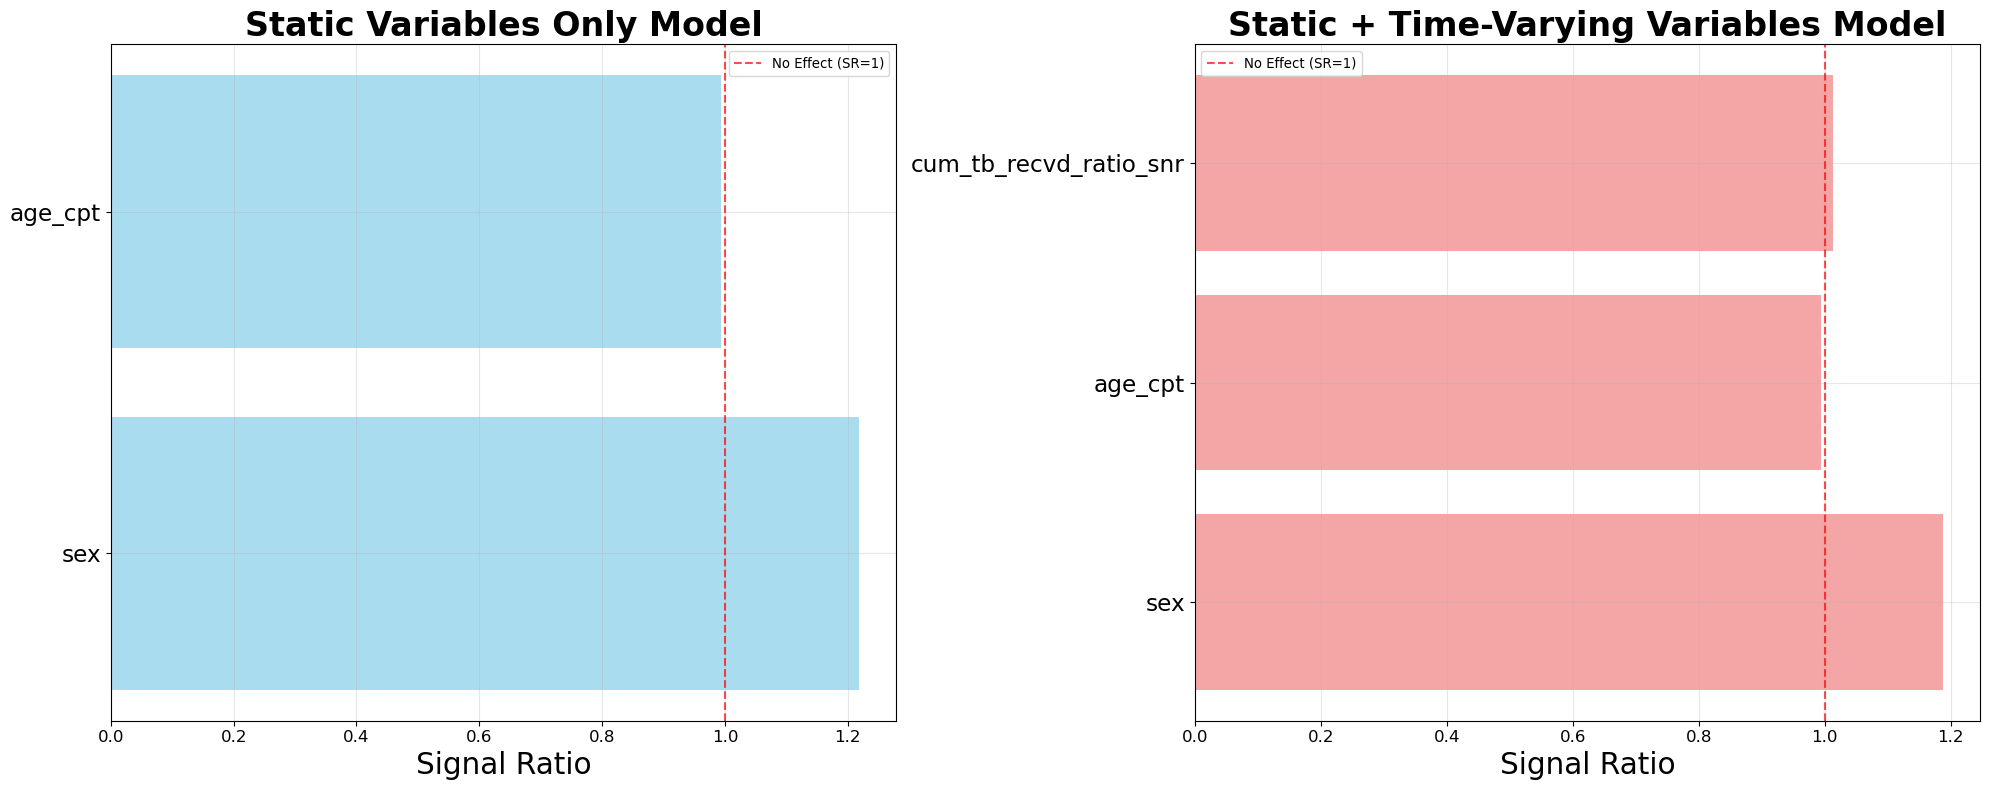


📊 Time-Varying Covariate Effects:
Division Effects (Signal Ratios):

📊 Model Comparison:
  • Static model C-index: 0.518
  • Full model C-index: 0.637
  • Improvement: 0.118

📊 Creating partial effects plots...
fnt_sz: 24, suptitl_sz: 36, title_sz: 24, axis_sz: 21, ref_ln_label_sz: 10, tick_sz: 12, lgnd_sz: 10
✅ Partial effects plot saved: plots/partial_effects.png


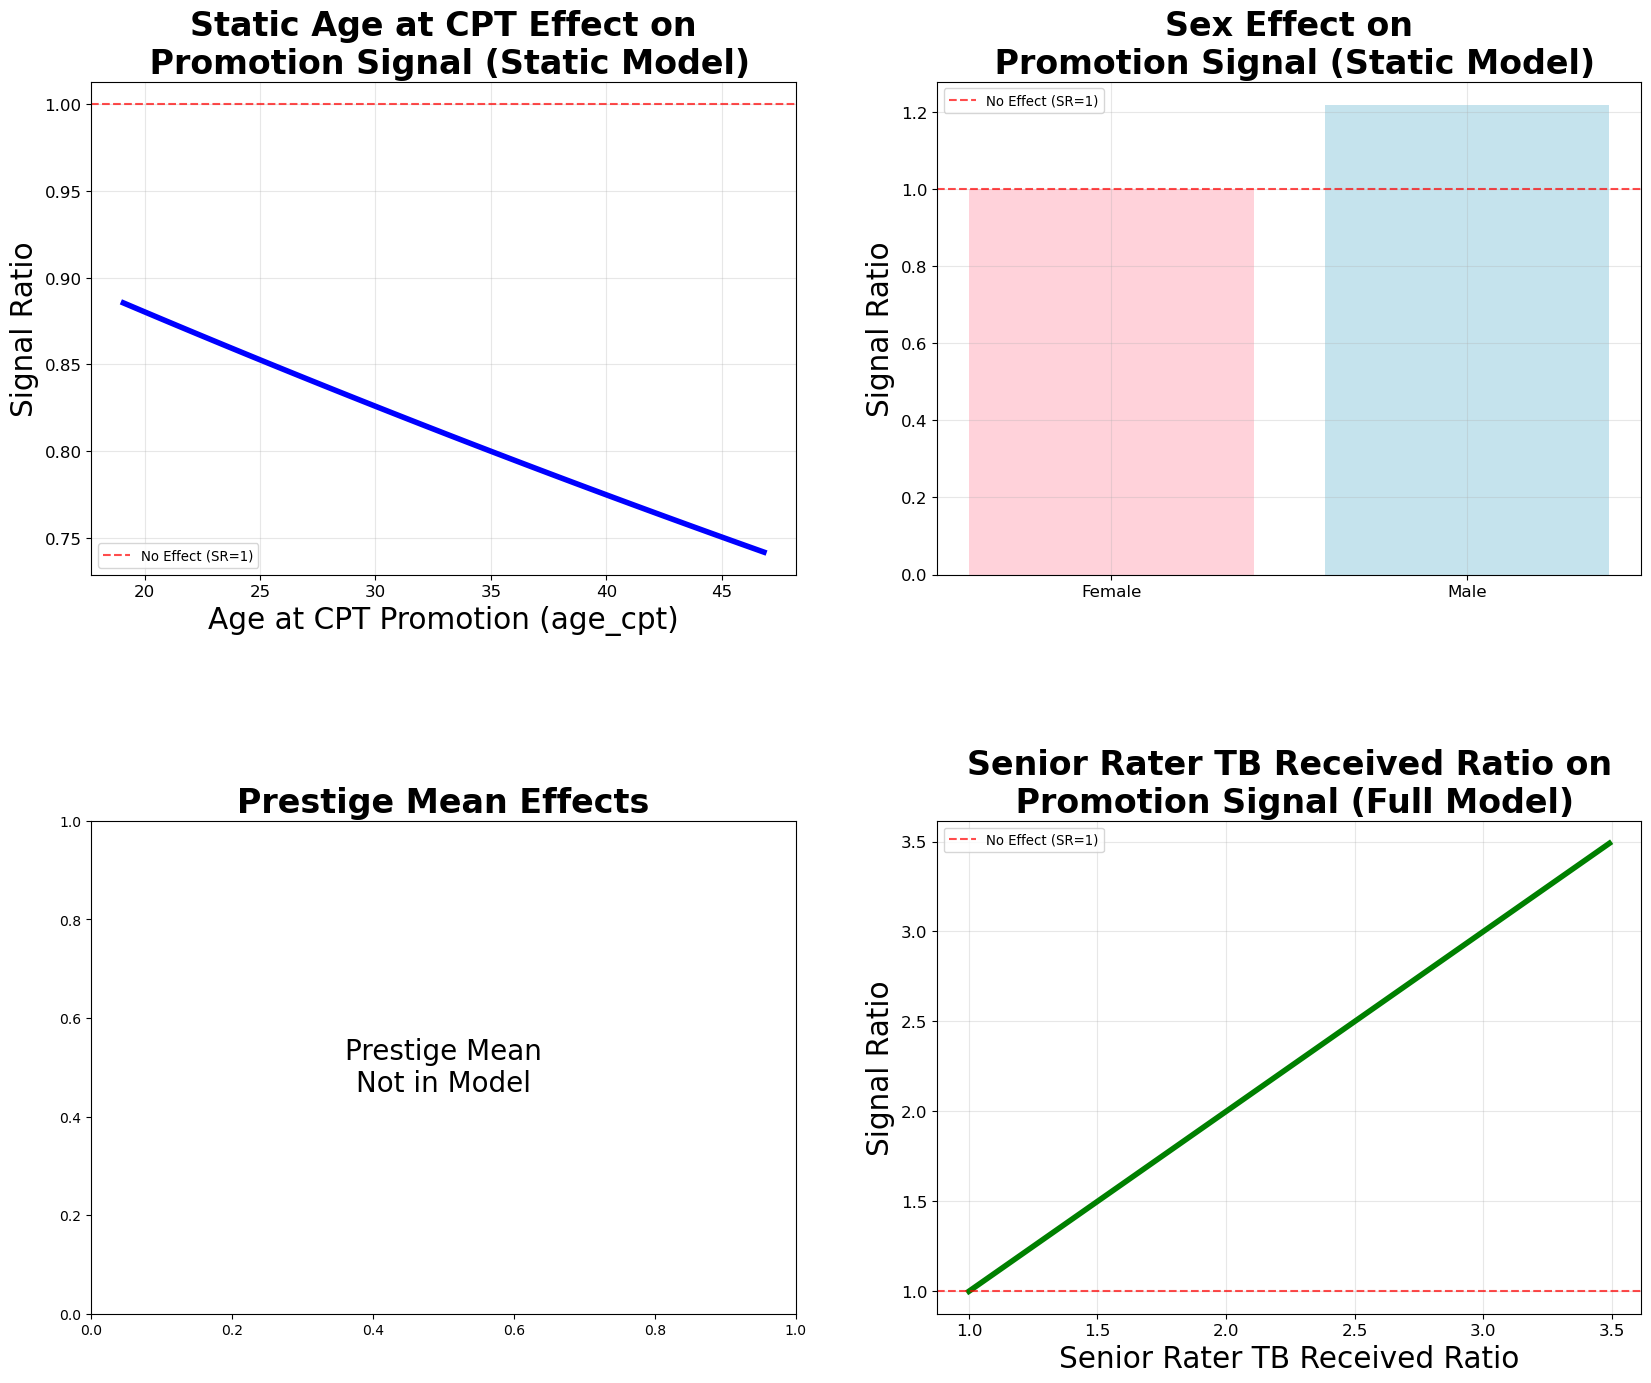


📊 Gender-Specific Signal Ratio Analysis:
🔍 Gender Effects (Static Model):
  • Male SR: 1.218
  • Female SR: 1.000 (reference)
  • Male vs Female: 1.218x

🔍 Gender Effects (Full Model):
  • Male SR: 1.187
  • Female SR: 1.000 (reference)
  • Male vs Female: 1.187x
No Font Size given... new fnt_sz = 29.0
fnt_sz: 29, suptitl_sz: 44, title_sz: 29, axis_sz: 26, ref_ln_label_sz: 12, tick_sz: 14, lgnd_sz: 12
✅ Gender effects comparison plot saved: plots/gender_effects_comparison.png


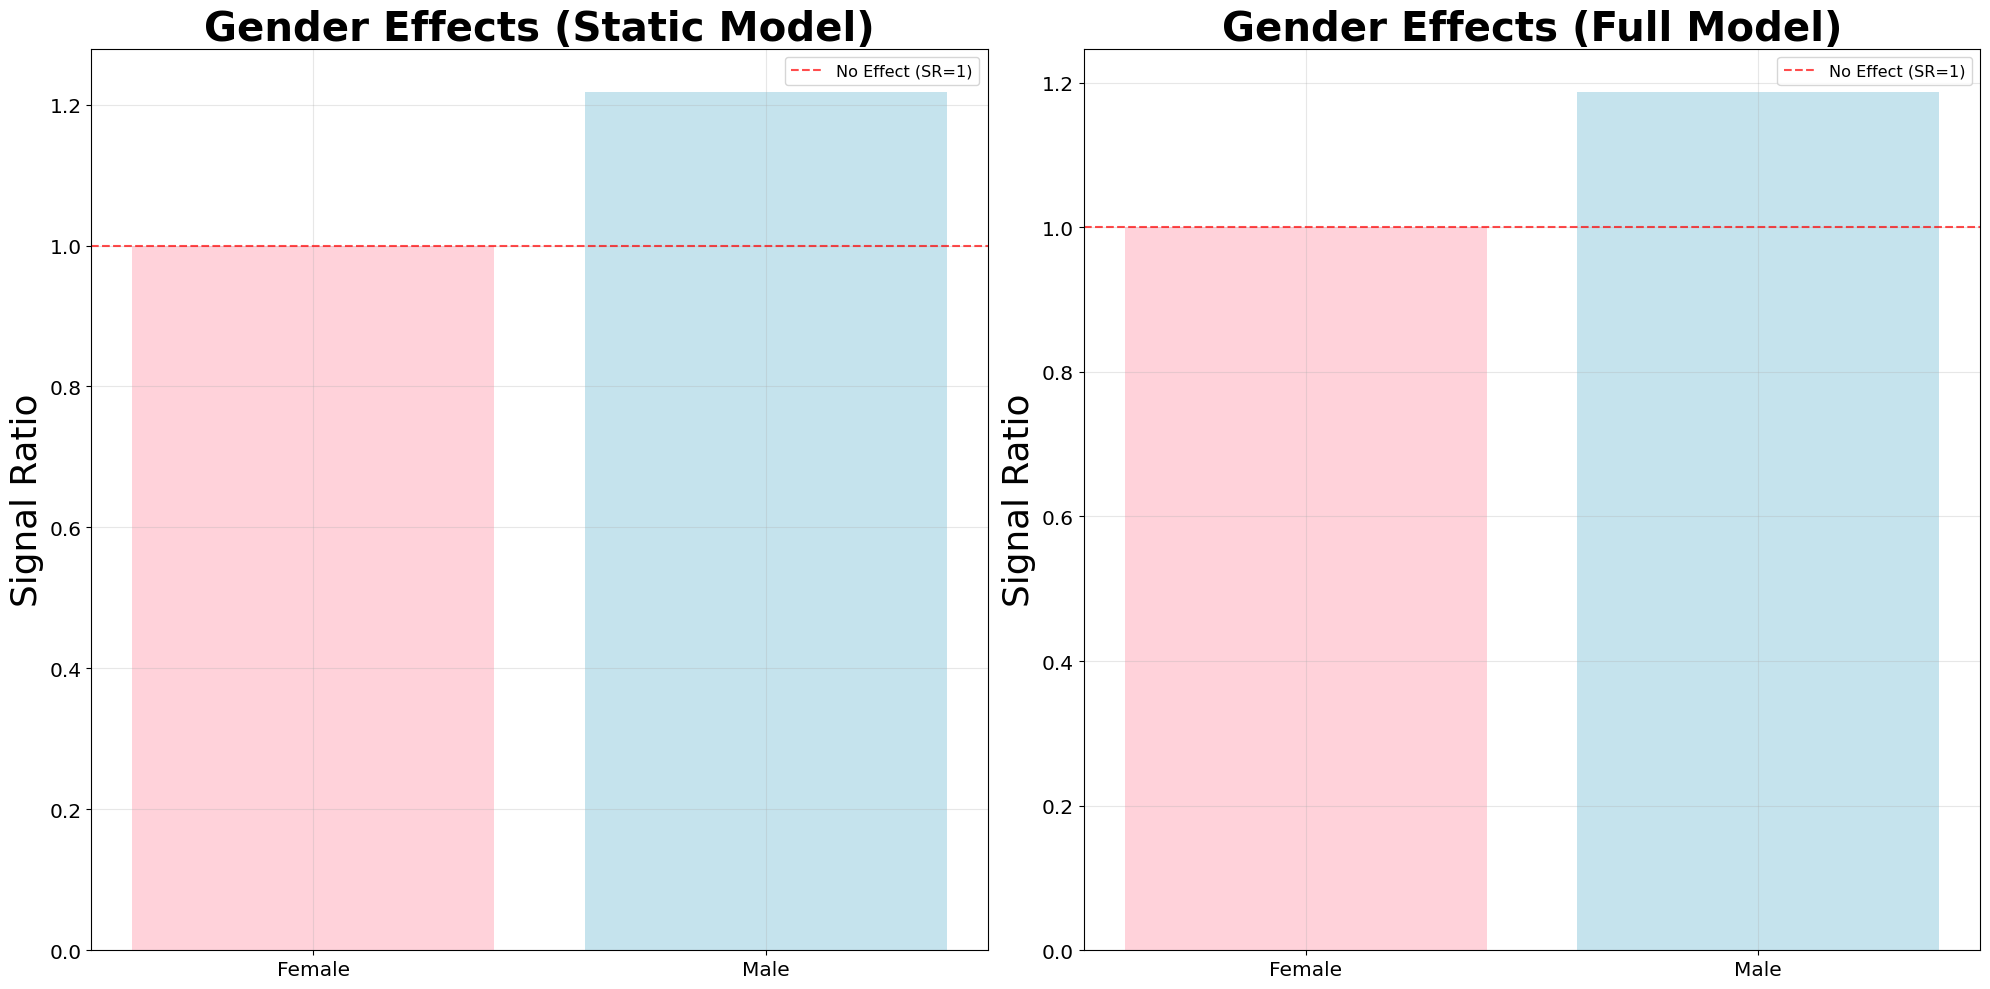


📊 Additional Variables to Consider:
🔍 Time-Varying Variables Available:
  • asg_uic_pde: 11247 unique values
  • rank_pde: 1 unique values
  • prestige_unit: 2 unique values

🔍 Derived Variables to Create:
  • time_in_current_division: Could be calculated from existing data
  • division_changes: Could be calculated from existing data
  • prestige_trajectory: Could be calculated from existing data
  • job_code_changes: Could be calculated from existing data

✅ Cox regression with both static and time-varying covariates completed!
🎯 Next: Results and interpretation


'11/19/2025 16:50:32'

In [50]:
# === 12.5. PLOT SIGNAL RATIOS COMPARISON ===
print("\n📊 Plotting signal ratios comparison...")

logx = False

fig_sz = (20,16) if len(static_vars) + len(model_vars) > 12 else (20, 8)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)

# Get plot scale relationships
fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz = get_plot_scales(fig_sz,24)  

# Plot 1: Static variables only
y_pos_static = range(len(static_vars))
sr_values_static = [np.exp(cph_static.coef_[i]) for i in range(len(static_vars))]

ax1.barh(y_pos_static, sr_values_static, alpha=0.7, color='skyblue')
ax1.set_yticks(y_pos_static)
ax1.set_yticklabels(static_vars, fontsize=tick_sz+(axis_sz-tick_sz)/2)
ax1.set_xlabel('Signal Ratio', fontsize=axis_sz)
ax1.set_title('Static Variables Only Model', fontsize=title_sz, fontweight='bold')
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=lgnd_sz)
ax1.tick_params(axis='x', labelsize=tick_sz)

# Plot 2: Static + Time-varying variables
y_pos_full = range(len(model_vars))
sr_values_full = [np.exp(cph.coef_[i]) for i in range(len(model_vars))]

ax2.barh(y_pos_full, sr_values_full, alpha=0.7, color='lightcoral')
ax2.set_yticks(y_pos_full)
ax2.set_yticklabels([var.replace('div_','') if var.startswith('div_') else var for var in model_vars ],
                    fontsize=tick_sz+(axis_sz-tick_sz)/2)
ax2.set_xlabel('Signal Ratio', fontsize=axis_sz)
if logx:
    ax2.set_xscale("log")
ax2.set_title('Static + Time-Varying Variables Model', fontsize=title_sz, fontweight='bold')
ax2.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=lgnd_sz)
ax2.tick_params(axis='x', labelsize=tick_sz)

plt.tight_layout()
plt.savefig(plot_dir + '/cox_signal_ratios_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Signal ratio comparison plot saved: plots/cox_signal_ratios_comparison.png")
plt.show()

# === 12.6. TIME-VARYING COVARIATE EFFECTS ===
print("\n📊 Time-Varying Covariate Effects:")

# Show division effects
div_effects = {}
for i, var in enumerate(model_vars):
    if var.startswith('div_'):
        div_name = var.replace('div_', '')
        sr = np.exp(cph.coef_[i])
        div_effects[div_name] = sr

print("Division Effects (Signal Ratios):")
for div, sr in sorted(div_effects.items(), key=lambda x: x[1], reverse=True):
    print(f"  • {div}: SR = {sr:.3f}")

# Model comparison
print(f"\n📊 Model Comparison:")
print(f"  • Static model C-index: {c_index_static:.3f}")
print(f"  • Full model C-index: {c_index_full:.3f}")
print(f"  • Improvement: {c_index_full - c_index_static:.3f}")

# === 12.7. PARTIAL EFFECTS PLOTS ===
print("\n📊 Creating partial effects plots...")

# Create partial effects plots for key variables
fig_sz = (20,16)  
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, gridspec_kw={'hspace':.5},figsize=fig_sz)  

# Get plot scale relationships
fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz = get_plot_scales(fig_sz,24)  

# Get yg dummy variables for plotting
yg_vars = [col for col in model_vars if col.startswith('yg_')]

# Plot 1: Age effects (static model)
age_range = np.linspace(cox_static['age_cpt'].min(), cox_static['age_cpt'].max(), 100)
age_effects = []

for age in age_range:
    # Get log signal ratio for age
    age_coef = cph_static.coef_[1]  # age_cpt coefficient
    age_effect = age_coef * age
    age_effects.append(age_effect)

# Convert to signal ratios for easier interpretation
age_sr = [np.exp(effect) for effect in age_effects]

ax1.plot(age_range, age_sr, linewidth=4, color='blue')
ax1.set_xlabel('Age at CPT Promotion (age_cpt)', fontsize=axis_sz)
ax1.set_ylabel('Signal Ratio', fontsize=axis_sz)
ax1.set_title('Static Age at CPT Effect on\n Promotion Signal (Static Model)', fontsize=title_sz, fontweight='bold')
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=lgnd_sz)  
ax1.tick_params(axis='both', which='major', labelsize=tick_sz)  

# Plot 2: Sex effects (static model)
sex_effects = [cph_static.coef_[0] * sex for sex in [0, 1]]
sex_sr = [np.exp(effect) for effect in sex_effects]
sex_labels = ['Female', 'Male']

ax2.bar(sex_labels, sex_sr, alpha=0.7, color=['pink', 'lightblue'])
ax2.set_ylabel('Signal Ratio', fontsize=axis_sz)  
ax2.set_title('Sex Effect on\n Promotion Signal (Static Model)', fontsize=title_sz, fontweight='bold')  
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=lgnd_sz)  
ax2.tick_params(axis='both', which='major', labelsize=tick_sz)  


# Plot 3: Prestige Mean effects (full model)
if 'prestige_mean' in model_vars:
    prestige_mean_idx = model_vars.index('prestige_mean')
    prestige_mean_coef = cph.coef_[prestige_mean_idx]

    # Create range of prestige_mean values
    prestige_range = np.linspace(cox_subset['prestige_mean'].min(), cox_subset['prestige_mean'].max(), 100)
    prestige_effects = [prestige_mean_coef * val for val in prestige_range]
    prestige_sr = [np.exp(effect) for effect in prestige_effects]

    ax3.plot(prestige_range, prestige_sr, linewidth=4, color='green')
    ax3.set_xlabel('Prestige Mean (Cumulative Average Prestige Quarters)', fontsize=axis_sz)  
    ax3.set_ylabel('Signal Ratio', fontsize=axis_sz)  
    ax3.set_title('Prestige Mean Effect on\n Promotion Signal (Full Model)', fontsize=title_sz, fontweight='bold')  
    ax3.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=lgnd_sz)  
    ax3.tick_params(axis='both', which='major', labelsize=tick_sz)  
else:
    ax3.text(0.5, 0.5,'Prestige Mean\nNot in Model', ha='center', va='center',
             transform=ax3.transAxes, fontsize=20)  
    ax3.set_title('Prestige Mean Effects', fontsize=title_sz, fontweight='bold')  

# Plot 4: Senior Rater Pool Prestige Mean Mean effects (full model)
if 'cum_tb_recvd_ratio_snr' in model_vars:
    cum_tb_recvd_ratio_snr_idx = model_vars.index('cum_tb_recvd_ratio_snr')
    cum_tb_recvd_ratio_snr_coef = cph.coef_[cum_tb_recvd_ratio_snr_idx]

    # Create range of cum_tb_recvd_ratio_snr values
    cum_tb_recvd_ratio_snr_range = np.linspace(cox_subset['cum_tb_recvd_ratio_snr'].min(), cox_subset['cum_tb_recvd_ratio_snr'].max(), 100)
    cum_tb_recvd_ratio_snr_effects = [cum_tb_recvd_ratio_snr_coef * val for val in cum_tb_recvd_ratio_snr_range]
    cum_tb_recvd_ratio_snr_range = [np.exp(effect) for effect in cum_tb_recvd_ratio_snr_effects]

    ax4.plot(cum_tb_recvd_ratio_snr_range, cum_tb_recvd_ratio_snr_range, linewidth=4, color='green')
    if logx:
        ax4.set_xscale("log")
    ax4.set_xlabel('Senior Rater TB Received Ratio', fontsize=axis_sz)  
    ax4.set_ylabel('Signal Ratio', fontsize=axis_sz)  
    ax4.set_title('Senior Rater TB Received Ratio on\n Promotion Signal (Full Model)', fontsize=title_sz, fontweight='bold')  
    ax4.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=lgnd_sz)  
    ax4.tick_params(axis='both', which='major', labelsize=tick_sz)  
else:
    ax4.text(0.5, 0.5,'Senior Rater TB Received Ratio\nNot in Model', ha='center', va='center',
             transform=ax3.transAxes, fontsize=20)  
    ax4.set_title('Senior Rater TB Received Ratio Effects', fontsize=title_sz, fontweight='bold')  

plt.tight_layout()
plt.savefig(plot_dir + '/partial_effects.png', dpi=300, bbox_inches='tight')
print("✅ Partial effects plot saved: plots/partial_effects.png")
plt.show()
    
# === 12.8. GENDER-SPECIFIC ANALYSIS ===
print("\n📊 Gender-Specific Signal Ratio Analysis:")

# Extract sex coefficient and create gender comparison
sex_coef_static = cph_static.coef_[0]  # sex coefficient in static model
sex_coef_full = cph.coef_[0]  # sex coefficient in full model

# Calculate signal ratios for males vs females
# Note: sex=1 is male, sex=0 is female in our data
male_sr_static = np.exp(sex_coef_static * 1)  # Male SR
female_sr_static = np.exp(sex_coef_static * 0)  # Female SR (reference = 1.0)

male_sr_full = np.exp(sex_coef_full * 1)  # Male SR
female_sr_full = np.exp(sex_coef_full * 0)  # Female SR (reference = 1.0)

print(f"🔍 Gender Effects (Static Model):")
print(f"  • Male SR: {male_sr_static:.3f}")
print(f"  • Female SR: {female_sr_static:.3f} (reference)")
print(f"  • Male vs Female: {male_sr_static:.3f}x")

print(f"\n🔍 Gender Effects (Full Model):")
print(f"  • Male SR: {male_sr_full:.3f}")
print(f"  • Female SR: {female_sr_full:.3f} (reference)")
print(f"  • Male vs Female: {male_sr_full:.3f}x")

# Create gender comparison plot
fig_sz = (20, 10)  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_sz)  

# Get plot scale relationships
fnt_sz, suptitl_sz, title_sz, axis_sz, ref_ln_label_sz, tick_sz, lgnd_sz = get_plot_scales(fig_sz)  

# Static model gender comparison
genders = ['Female', 'Male']
sr_values_gender_static = [female_sr_static, male_sr_static]
colors_gender = ['pink', 'lightblue']

ax1.bar(genders, sr_values_gender_static, alpha=0.7, color=colors_gender)
ax1.set_ylabel('Signal Ratio', fontsize=axis_sz)  
ax1.set_title('Gender Effects (Static Model)', fontsize=title_sz, fontweight='bold')  
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=lgnd_sz)  
ax1.tick_params(axis='both', which='major', labelsize=tick_sz)  

# Full model gender comparison
sr_values_gender_full = [female_sr_full, male_sr_full]

ax2.bar(genders, sr_values_gender_full, alpha=0.7, color=colors_gender)
ax2.set_ylabel('Signal Ratio', fontsize=axis_sz)  
ax2.set_title('Gender Effects (Full Model)', fontsize=title_sz, fontweight='bold')  
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Effect (SR=1)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=lgnd_sz)  
ax2.tick_params(axis='both', which='major', labelsize=tick_sz)

plt.tight_layout()
plt.savefig(plot_dir + '/gender_effects_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Gender effects comparison plot saved: plots/gender_effects_comparison.png")
plt.show()

# === 12.9. ADDITIONAL VARIABLES TO CONSIDER ===
print("\n📊 Additional Variables to Consider:")

print("🔍 Time-Varying Variables Available:")
available_vars = ['asg_uic_pde', 'rank_pde', 'job_code', 'unit_type', 'prestige_unit', 'gtw_unit']
for var in available_vars:
    if var in df_cox.columns:
        unique_vals = df_cox[var].nunique()
        print(f"  • {var}: {unique_vals} unique values")

print("\n🔍 Derived Variables to Create:")
derived_vars = ['time_in_current_division', 'division_changes', 'prestige_trajectory', 'job_code_changes']
for var in derived_vars:
    print(f"  • {var}: Could be calculated from existing data")

print("\n✅ Cox regression with both static and time-varying covariates completed!")
print("🎯 Next: Results and interpretation")
tyme()

# **📦 CELL 12.10 3D INTERACTION EFFECTS PLOT


📊 Creating 3D interaction effects plot...
🔍 Adding interaction term to model...
✅ Created z-scored variables and interaction term (z-product)
🔍 Using base vars present in df_cox: ['sex', 'age_cpt', 'married']

 Interaction diagnostics (z-terms):
     std:
prestige_mean_z_sub             1.000000
sr_pool_pm_mean_z_sub           1.000000
sr_pool_prestige_product_sub    5.744736
dtype: float64
     corr:
                              prestige_mean_z_sub  sr_pool_pm_mean_z_sub  \
prestige_mean_z_sub                      1.000000               0.971759   
sr_pool_pm_mean_z_sub                    0.971759               1.000000   
sr_pool_prestige_product_sub             0.919408               0.931595   

                              sr_pool_prestige_product_sub  
prestige_mean_z_sub                               0.919408  
sr_pool_pm_mean_z_sub                             0.931595  
sr_pool_prestige_product_sub                      1.000000  
📊 Model variables with interction: ['sex', 'a

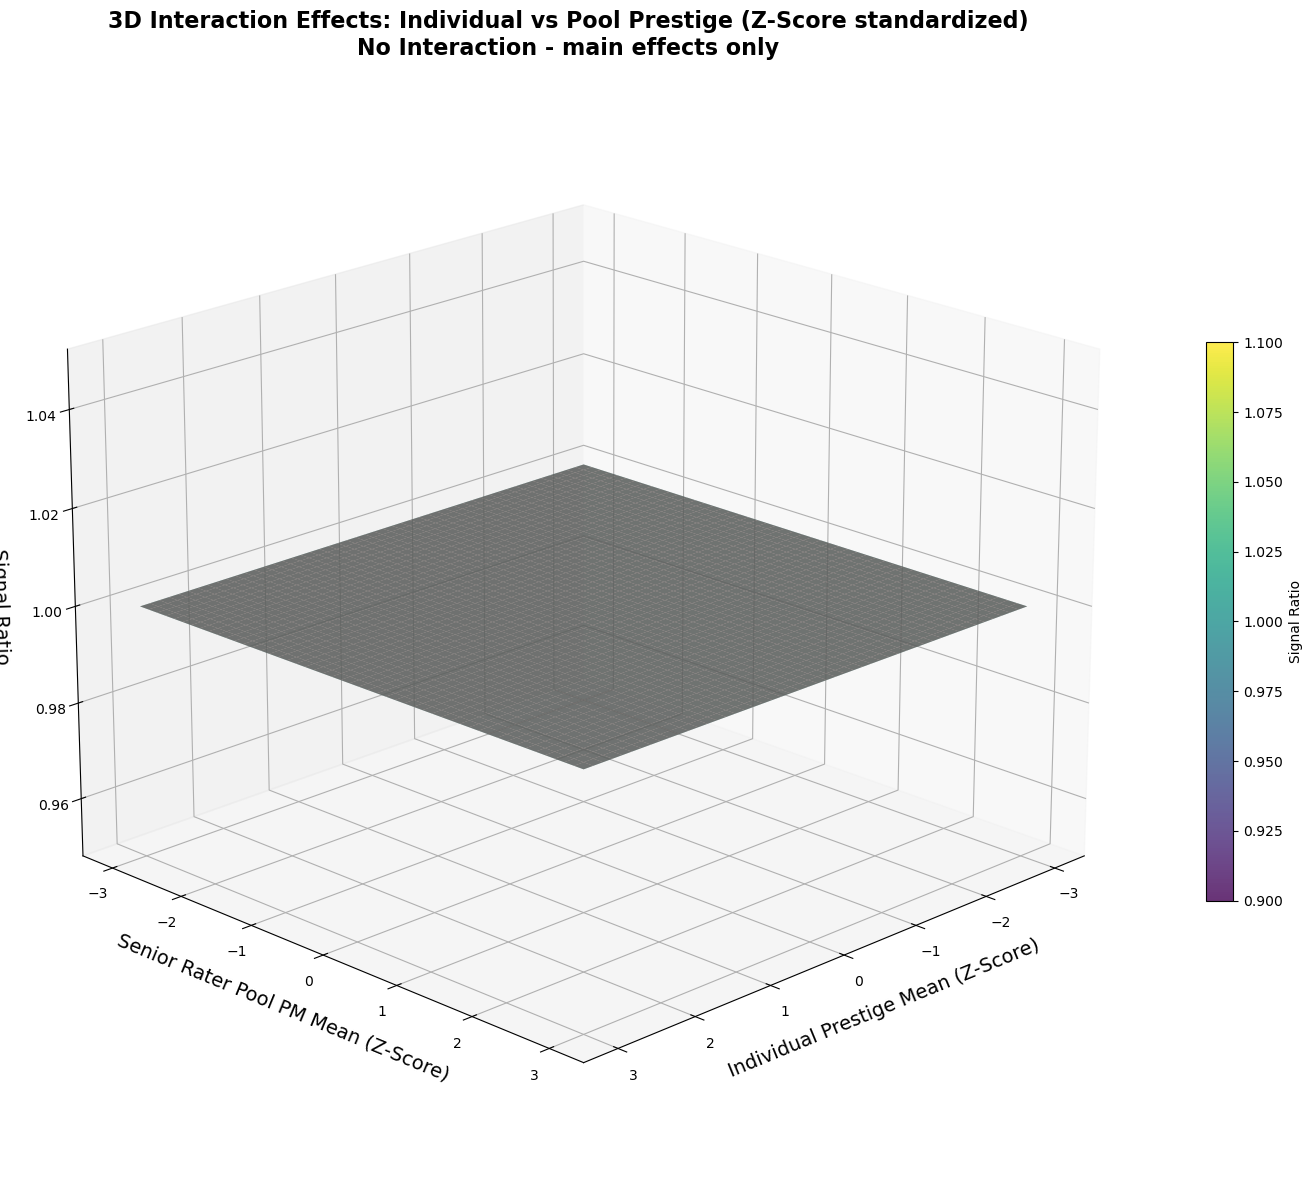


📊 Interaction Effects Interpretation:
  • Individual Prestige Coef: 0.00000
  • Pool Prestige Coef: 0.00000
  • Interaction Coef: 0.00000
  • 🔍 No interaction: Prestige effects are purely additive

📊 Example Scenarios (Z-Score Standardized):
  •  Low Individual (-1σ), Low Pool (-1σ): SR = 1.00000
  •  High Individual (1σ), Low Pool (-1σ): SR = 1.00000
  •  Low Individual (-1σ), High Pool (1σ): SR = 1.00000
  •  High Individual (1σ), High Pool (1σ): SR = 1.00000
  •  Average Individual (0σ), Average Pool (0σ): SR = 1.00000

📊 Raw Value Context:
  • Individual Prestige Mean: 0.11955 ± 0.21300
  • Pool Prestige Mean: 0.00059 ± 0.00299

✅ 3D interaction analysis completed


'11/03/2025 09:55:23'

In [24]:
# === 12.10. 3D INTERACTION EFFECTS PLOT ===

logz = False
print("\n📊 Creating 3D interaction effects plot...")

# Check if we have the interaction term in our model
if 'sr_pool_prestige_product' not in model_vars:
    print("🔍 Adding interaction term to model...")

    # Create z-scored main effects and their interaction (product of z-scores)
    if 'prestige_mean' in df_cox.columns and 'sr_pool_pm_mean' in df_cox.columns:
        df_cox['prestige_mean_z'] = ( (df_cox['prestige_mean'] - df_cox['prestige_mean'].mean()) / df_cox['prestige_mean'].std())
        df_cox['sr_pool_pm_mean_z'] = ( (df_cox['sr_pool_pm_mean'] - df_cox['sr_pool_pm_mean'].mean()) / df_cox['sr_pool_pm_mean'].std())
        # Interaction as product of z-scores
        df_cox['sr_pool_prestige_product'] = df_cox['prestige_mean_z'] * df_cox['sr_pool_pm_mean_z']
        print("✅ Created z-scored variables and interaction term (z-product)")
        interaction_available = True
    else:
        print("❌ Cannot create interaction term - missing prestige_mean or sr_pool_pm_mean")
        interaction_available = False

    if interaction_available:  
        # Replace the raw main effects with z-scored versions for this interaction model
        base_vars = [v for v in model_vars if v not in ['prestige_mean','sr_pool_pm_mean']]
 
        # Restrict to pool-eligible intervals (where pool is defined)
        has_pool = df_cox['co_cmd'].notna() & df_cox['sr_pool_pm_mean'].notna()

        # Keep only base variables that actually exist in df_cox (guards against prior z-vars lingering in model_vars)
        base_in_df = [v for v in base_vars if v in df_cox.columns]
        cols_for_subset = ['start_time','end_time','event'] + base_in_df + ['prestige_mean','sr_pool_pm_mean']
        cox_subset_interaction = df_cox.loc[has_pool, cols_for_subset].copy()
        print(f"🔍 Using base vars present in df_cox: {base_in_df}")
        
        # Compute z-scores WITHIN this subset and build interaction (sub-variables)
        cox_subset_interaction['prestige_mean_z_sub'] = (
            cox_subset_interaction['prestige_mean'] - cox_subset_interaction['prestige_mean'].mean()
        ) / cox_subset_interaction['prestige_mean'].std()
        cox_subset_interaction['sr_pool_pm_mean_z_sub'] = (
            cox_subset_interaction['sr_pool_pm_mean'] - cox_subset_interaction['sr_pool_pm_mean'].mean()
        ) / cox_subset_interaction['sr_pool_pm_mean'].std()
        cox_subset_interaction['sr_pool_prestige_product_sub'] = (
            cox_subset_interaction['prestige_mean_z_sub'] * cox_subset_interaction['sr_pool_pm_mean_z_sub'])
        
        model_vars_with_interaction = base_vars+ [
            'prestige_mean_z_sub','sr_pool_pm_mean_z_sub','sr_pool_prestige_product_sub']
        
        # Remove any missing values
        cox_subset_interaction = cox_subset_interaction.dropna()

        # Diagnostics: variance and correlation among z-terms
        Xz = cox_subset_interaction[['prestige_mean_z_sub','sr_pool_pm_mean_z_sub','sr_pool_prestige_product_sub']]
        print("\n Interaction diagnostics (z-terms):")
        print("     std:")
        print(Xz.std(numeric_only=True))
        print("     corr:")
        print(Xz.corr(numeric_only=True))

    print(f"📊 Model variables with interction: {model_vars_with_interaction}")
    print(f"📊 Sample size with interaction: {len(cox_subset_interaction):,}")

    # Fit model with interaction term (no fallbacks)
    print("\n🔍 Attempting full Cox model fit with interaction term and regulariztion...")
    try:
        cph_interaction = CoxPHSurvivalAnalysis(alpha=0.01)  # Use regularization
        cox_surv_interaction = Surv.from_arrays(
            event=cox_subset_interaction['event'] == 1,
            time=cox_subset_interaction['end_time'] - cox_subset_interaction['start_time']
        )
        cph_interaction.fit(cox_subset_interaction[model_vars_with_interaction], cox_surv_interaction)
        print("✅ Interaction model fitted successfully with regularization!")

        # Update model_vars for plotting
        model_vars = model_vars_with_interaction
        cox_subset = cox_subset_interaction
        cox_surv = cox_surv_interaction

    except Exception as e:
        print(f"❌ Interaction model fit failed: {e}")
        print("🔍 Proceeding with main effects only...")
        interaction_available = False
else:
    print("✅ Interaction term already in model!")
    interaction_available = True

# Create 3D surface plot
if (
    ('prestige_mean_z_sub' in model_vars and 'sr_pool_pm_mean_z_sub' in model_vars) or
    ('prestige_mean_z' in model_vars and 'sr_pool_pm_mean_z' in model_vars) ):
    
    print("XXX Creating 3D interaction surface model...")

    # Debug: Check what variables actually made it into the model
    print(f"🔍 Model variables: {model_vars}")
    print(f"🔍 Number of coefficients: {len(cph.coef_)}")
    print(f"🔍 Coefficient values: {cph.coef_}")

    actual_vars = []
    var_to_coef = {}

    # Map each variable to its coefficient if it exists
    for i, var in enumerate(model_vars):
        if i < len(cph.coef_):
            actual_vars.append(var)
            var_to_coef[var] = cph.coef_[i]
            print(f"🔍 {var}: coefficient = {cph.coef_[i]:.4f}")
        else:
            print(f"❌ {var}: DROPPED during model fitting")

    # Get coefficients safely
    prestige_coef = var_to_coef.get('prestige_mean_z', 0.0)
    sr_pool_coef = var_to_coef.get('sr_pool_pm_mean_z', 0.0)
    interaction_coef = var_to_coef.get('sr_pool_prestige_product', 0.0)

    print(f"\n📊 Final coefficients (z-scored main effects):")
    print(f"  • Prestige Mean (z): {prestige_coef:.4f}")
    print(f"  • SR Pool PM Mean (z): {sr_pool_coef:.4f}")
    print(f"  • Interaction Coef (zxz): {interaction_coef:.4f}")

    if interaction_coef == 0.0:
        print("⚠️ No interaction effect - plotting main effects only")
    
    # Gather raw-value context stats from the full data dataset (raw columns live in df_cox)
    prestige_mean_mean = df_cox.prestige_mean.mean()
    prestige_mean_std = df_cox.prestige_mean.std()
    sr_pool_mean_mean = df_cox.sr_pool_pm_mean.mean()
    sr_pool_mean_std = df_cox.sr_pool_pm_mean.std()

    # Create meshgrid for 3D surface using z-scores using a reasonable z-score range instead on min\max
    prestige_range_z = np.linspace(-3, 3, 50) # Standard z-score range
    sr_pool_range_z = np.linspace(-3, 3, 50) # Standard z-score range
        
    P_z, S_z = np.meshgrid(prestige_range_z, sr_pool_range_z)

    # Calculate the signal ratios for each point on the surface using z-scores
    # Signal Ratio = exp(beta1xprestige_z + beta2xsr_pool_z + beta3xprestigezxsr_pool_z)
    Z = np.exp(prestige_coef * P_z + sr_pool_coef * S_z + interaction_coef*P_z * S_z)

    # Clip extreme values to prevent visualization issues
    Z = np.clip(Z, 0.01, 100)  # Clip to reasonable rabge for visualization
    
    # Create 3D plot
    fig = plt.figure(figsize=(16,12))
    ax = fig.add_subplot(111, projection='3d')

    # Create surface plot
    surf = ax.plot_surface(P_z, S_z, Z, cmap='viridis', alpha=0.8,
                          linewidth=0, antialiased=True)

    # Add contour lines on the surface
    ax.contour(P_z, S_z, Z, zdir='z', offset=Z.min(), cmap='viridis', alpha=0.5)

    # Set labels and title
    ax.set_xlabel('Individual Prestige Mean (Z-Score)', fontsize=14, labelpad=10)
    ax.set_ylabel('Senior Rater Pool PM Mean (Z-Score)', fontsize=14, labelpad=10)
    ax.set_zlabel('Signal Ratio (Log Scale)' if logz else 'Signal Ratio', fontsize=14, labelpad=10)
    if interaction_coef == 0.0:
        ax.set_title('3D Interaction Effects: Individual vs Pool Prestige (Z-Score standardized)\n' + 
                     f'No Interaction - main effects only', fontsize=16, fontweight='bold')
    else:
        ax.set_title('3D Main Effects: Individual vs Pool Prestige (Z-Score standardized)\n' +
                     f'Interaction Coef: {interaction_coef:.9f}', fontsize=16, fontweight='bold')
    if logz:
        # Set Z-axis to log scale
        ax.set_zscale('log')
        # set reasonable z-axis limits for log scale
        ax.set_zlim(0.01,100)
    
    # Add colorbar
    fig.colorbar(surf, shrink=0.5, aspect=20, label='Signal Ratio')

    # Set viewing angle for better perspective
    ax.view_init(elev=20, azim=45)

    if logz:
        # Add reference line at SR=1 (log scale)
        # For log scale, SR=1 corresponds to log(1) = 0
        # We'll add a horizontal line at the bottom of the plot
        ax.plot([P_z.min(), P_z.max()], [S_z.min(), S_z.max()], [1,1],
               color='red', linestyle='--', alpha=0.7, linewidth=2, label='SR=1 Reference')
    else:
        # # Add reference plane at SR=1
        ax.plot_surface(P_z, S_z, np.ones_like(Z), alpha=0.3, color='red')
        
    plt.tight_layout()
    plt.savefig(plot_dir + '/3D_prestige_interaction_effects.png', dpi=300, bbox_inches='tight')
    print("✅ 3D interaction effects plot saved: plots/3D_prestige_interaction_effects.png")
    plt.show()

    # Print interpretation
    print(f"\n📊 Interaction Effects Interpretation:")
    print(f"  • Individual Prestige Coef: {prestige_coef:.5f}")
    print(f"  • Pool Prestige Coef: {sr_pool_coef:.5f}")
    print(f"  • Interaction Coef: {interaction_coef:.5f}")

    if interaction_coef > 0:
        print("  • 🔍 Positive interaction: Prestige effects are AMPLIFIED in high-prestige pools")
    if interaction_coef < 0:
        print("  • 🔍 Negative interaction: Prestige effects are DIMINISHED in high-prestige pools")
    else:
        print("  • 🔍 No interaction: Prestige effects are purely additive")

    # Calculate some example scenarios using z-scores
    print(f"\n📊 Example Scenarios (Z-Score Standardized):")
    scenarios = [
        (-1.0, -1.0, "Low Individual (-1\u03C3), Low Pool (-1\u03C3)"),
        (1.0, -1.0, "High Individual (1\u03C3), Low Pool (-1\u03C3)"),
        (-1.0, 1.0, "Low Individual (-1\u03C3), High Pool (1\u03C3)"),
        (1.0, 1.0, "High Individual (1\u03C3), High Pool (1\u03C3)"),
        (0.0, 0.0, "Average Individual (0\u03C3), Average Pool (0\u03C3)")]
    
    for p_z, s_z, desc, in scenarios:
        sr = np.exp(prestige_coef*p_z + sr_pool_coef*s_z + interaction_coef*p_z*s_z)
        print(f"  •  {desc}: SR = {sr:.5f}")

    # Also show raw value equivalents for context
    print(f"\n📊 Raw Value Context:")
    print(f"  • Individual Prestige Mean: {prestige_mean_mean:.5f} \u00B1 {prestige_mean_std:.5f}")
    print(f"  • Pool Prestige Mean: {sr_pool_mean_mean:.5f} \u00B1 {sr_pool_mean_std:.5f}")

else:
    print("❌ Cannot create 3D plot - missing prestige_mean or sr_pool_pm_mean in model")

print("\n✅ 3D interaction analysis completed")
tyme()   

# **✅ CELL 13: RESULTS & INTERPRETATION**

##### **Summarize Key Findings and Provide Interpretation**
- **Promotion Rates**: Overall and by demographic groups
- **Competing Risks Patterns**: Time to events and rates
- **Cox Model Results**: Signal ratios and model performance
- **Key Conclusions**: Main findings and implications

##### **Focus**: Comprehensive summary of competing risks analysis results



=== RESULTS & INTERPRETATION ===

📊 Promotion Rates Summary:
  • Overall promotion rate: 31.5%
  • Overall attrition rate: 39.5%
  • Overall censoring rate: 28.9%
  • Female: 24.3% promoted, 41.7% attrited, 34.0% censored
  • Male: 32.2% promoted, 39.3% attrited, 28.5% censored

📊 Time-Varying Covariate Effects:

🔍 Competing Risks Patterns:
  • Time to promotion: 2560 ± 243 days
  • Time to attrition: 1286 ± 837 days
  • Time to censoring: 1407 ± 733 days

📊 Creating time-to-event histograms...
✅ Time-to-event histograms saved: plots/time_to_event_histograms.png


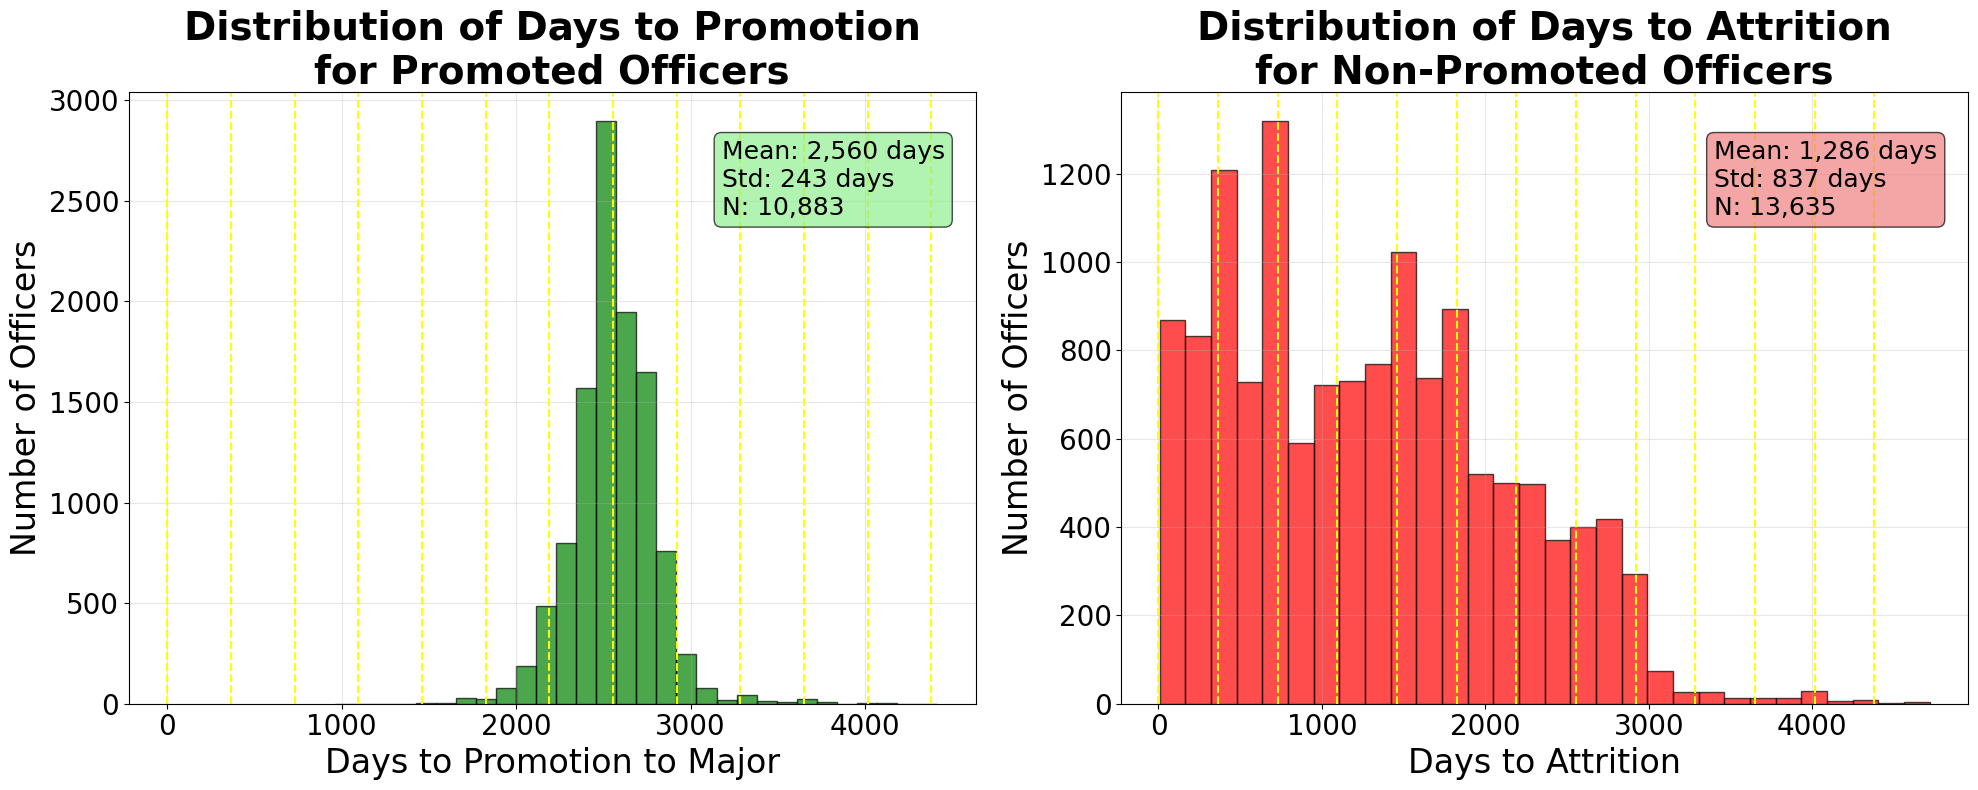


🎯 Key Conclusions:
  • Promotion Patterns:
    - Overall promotion rate: 31.5%
    - Female promotion rate: 24.3%
    - Male promotion rate: 32.2%
  • Competing Risks:
    - Attrition rate: 39.5%
    - Censoring rate: 28.9%
  • Time-Varying Analysis:
    - Total intervals: 894,676
    - Unique officers: 34,504

✅ Analysis completed successfully!
🎯 Competing risks analysis with time-varying covariates shows realistic promotion curves
📊 Cox regression provides signal ratios for static and time-varying predictors
🚀 The curves should now plateau at actual rates with proper denominators!


'11/03/2025 09:55:25'

In [25]:
# === CELL 13: RESULTS & INTERPRETATION ===
# Summarize key findings and provide interpretation

print("\n=== RESULTS & INTERPRETATION ===\n")

# === 13.1. PROMOTION RATES SUMMARY ===
print("📊 Promotion Rates Summary:")

# Overall promotion rates from officer-level data (not interval-level)
overall_promo = (officer_data['competing_event'] == 1).mean()
overall_attr = (officer_data['competing_event'] == 2).mean()
overall_cens = (officer_data['competing_event'] == 0).mean()

print(f"  • Overall promotion rate: {overall_promo:.1%}")
print(f"  • Overall attrition rate: {overall_attr:.1%}")
print(f"  • Overall censoring rate: {overall_cens:.1%}")

# By sex
for sex_val in [0, 1]:
    sex_data = officer_data[officer_data['sex'] == sex_val]
    sex_promo = (sex_data['competing_event'] == 1).mean()
    sex_attr = (sex_data['competing_event'] == 2).mean()
    sex_cens = (sex_data['competing_event'] == 0).mean()
    
    sex_label = "Female" if sex_val == 0 else "Male"
    print(f"  • {sex_label}: {sex_promo:.1%} promoted, {sex_attr:.1%} attrited, {sex_cens:.1%} censored")

# === 13.2. TIME-VARYING COVARIATE EFFECTS ===
print("\n📊 Time-Varying Covariate Effects:")

# Division effects
# div_counts = df_survival['div_name'].value_counts()
# print(f"\n📊 Division Distribution:")
# for div, count in div_counts.items():
#     pct = count / len(df_survival) * 100
#     print(f"  • {div}: {count:,} intervals ({pct:.1f}%)")

# === 13.3. COMPETING RISKS PATTERNS ===
print("\n🔍 Competing Risks Patterns:")

# Time to events
promo_times = df_survival[df_survival['event'] == 1]['end_time']
attr_times = df_survival[df_survival['event'] == 2]['end_time']
cens_times = df_survival[df_survival['event'] == 0]['end_time']

print(f"  • Time to promotion: {promo_times.mean():.0f} ± {promo_times.std():.0f} days")
print(f"  • Time to attrition: {attr_times.mean():.0f} ± {attr_times.std():.0f} days")
print(f"  • Time to censoring: {cens_times.mean():.0f} ± {cens_times.std():.0f} days")

# === 13.4. TIME-TO-EVENT HISTOGRAMS ===
print("\n📊 Creating time-to-event histograms...")

# Create histograms for time to events
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Days to promotion for those promoted
ax1.hist(promo_times, bins=30, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Days to Promotion to Major', fontsize=24)
ax1.set_ylabel('Number of Officers', fontsize=24)
ax1.set_title('Distribution of Days to Promotion\nfor Promoted Officers', fontsize=28, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=20)

# Add statistics text
ax1.text(0.7, 0.8, f'Mean: {promo_times.mean():,.0f} days\nStd: {promo_times.std():.0f} days\nN: {len(promo_times):,}', 
         transform=ax1.transAxes, fontsize=18, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

# Plot 2: Days to attrition for those not promoted
not_promoted_times = df_survival[df_survival['event'] == 2]['end_time']
ax2.hist(not_promoted_times, bins=30, alpha=0.7, color='red', edgecolor='black')
ax2.set_xlabel('Days to Attrition', fontsize=24)
ax2.set_ylabel('Number of Officers', fontsize=24)
ax2.set_title('Distribution of Days to Attrition\nfor Non-Promoted Officers', fontsize=28, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=20)

# Print vertical lines representing years from promotion to CPT
for d in range(START_TIME,int(max(not_promoted_times))):
    if d % 365 ==0:
        ax1.axvline(x=d, color='yellow', linestyle='--')
        ax2.axvline(x=d, color='yellow', linestyle='--')

# Add statistics text
ax2.text(0.7, 0.8, f'Mean: {not_promoted_times.mean():,.0f} days\nStd: {not_promoted_times.std():.0f} days\nN: {len(not_promoted_times):,}', 
         transform=ax2.transAxes, fontsize=18, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.savefig(plot_dir + '/time_to_event_histograms.png', dpi=300, bbox_inches='tight')
print("✅ Time-to-event histograms saved: plots/time_to_event_histograms.png")
plt.show()

# === 13.5. KEY CONCLUSIONS ===
print("\n🎯 Key Conclusions:")

print("  • Promotion Patterns:")
print(f"    - Overall promotion rate: {overall_promo:.1%}")
print(f"    - Female promotion rate: {(officer_data[officer_data['sex'] == 0]['competing_event'] == 1).mean():.1%}")
print(f"    - Male promotion rate: {(officer_data[officer_data['sex'] == 1]['competing_event'] == 1).mean():.1%}")

print("  • Competing Risks:")
print(f"    - Attrition rate: {overall_attr:.1%}")
print(f"    - Censoring rate: {overall_cens:.1%}")

print("  • Time-Varying Analysis:")
print(f"    - Total intervals: {len(df_survival):,}")
print(f"    - Unique officers: {df_survival['pid_pde'].nunique():,}")
# print(f"    - Divisions analyzed: {df_survival['div_name'].nunique()}")

print("\n✅ Analysis completed successfully!")
print("🎯 Competing risks analysis with time-varying covariates shows realistic promotion curves")
print("📊 Cox regression provides signal ratios for static and time-varying predictors")
print("🚀 The curves should now plateau at actual rates with proper denominators!")
tyme()

# **🔍 CELL 14: CPT TIME EXPLORATION BY BRANCH**

##### **Explore CPT timeline boundaries**
- **Promoted Officers**: Time window ranges
- **Non-Promoted Officers**: Time window ranges
- **Competing Events**: Promotion, Attrition, Right Cencoring

##### **Focus**: Identify appropriate filtering boundaries for realistic career windows

In [26]:
# === CELL 14: CPT TIME EXPLORATION BY BRANCH ===
# Summarize captain timeline boundaries for each branch
# To help determine when to say officers are attrited instead of right censored
total_officers=[];final_job = [];promoted = [];attrited = [];right_censored = [];percent_promoted = [];min_time_promoted = [];max_time_promoted = [];min_time_not_promoted = [];max_time_not_promoted = []
job_list = officer_data.final_job_code.value_counts()
for job in job_list.items():
    job_code = job[0]
    df = officer_data[officer_data.final_job_code == job_code]
    odict = df.competing_event.value_counts().to_dict()
    aodict = dict()
    for job in odict:
        for I in [0,1,2]:
            aodict.update({I:odict[I]} if I in odict.keys() else {I:0})
    max_cpt_time_p = (df[(df.competing_event == 1)].follow_up_days.max()/365.25); min_cpt_time_p = (df[(df.competing_event == 1)].follow_up_days.min()/365.25)
    max_cpt_time_np = (df[~(df.competing_event == 1)].follow_up_days.max()/365.25); min_cpt_time_np = (df[~(df.competing_event == 1)].follow_up_days.min()/365.25)
    total_officers.append(f'{df.pid_pde.nunique():,}'); final_job.append(job_code); promoted.append(f'{aodict[1]:,}'); attrited.append(f'{aodict[2]:,}'); right_censored.append(aodict[0])
    percent_promoted.append(f'{(aodict[1]/sum(odict.values())):.2%}')
    min_time_promoted.append(min_cpt_time_p); max_time_promoted.append(max_cpt_time_p); min_time_not_promoted.append(min_cpt_time_np); max_time_not_promoted.append(max_cpt_time_np)
timeline_dict = {'final_job':final_job ,'total_officers':total_officers,'promoted':promoted ,'attrited':attrited ,'right_censored':right_censored ,'percent_promoted':percent_promoted,
                 'min_time_promoted':min_time_promoted,'max_time_promoted':max_time_promoted ,'min_time_not_promoted':min_time_not_promoted ,'max_time_not_promoted':max_time_not_promoted}
df_timeline = pd.DataFrame(timeline_dict)

print("\\n\n📊 CPT TIME PROMOTION BOUNDARIES BY BRANCH")
# display(df_timeline)


# total_officers=[];final_unit = [];promoted = [];attrited = [];right_censored = [];percent_promoted = [];min_time_promoted = [];max_time_promoted = [];min_time_not_promoted = [];max_time_not_promoted = []
# unit_list = officer_data.final_div.value_counts()
# for unit in unit_list.items():
#     final_div = unit[0]
#     df = officer_data[officer_data.final_div == final_div]
#     odict = df.competing_event.value_counts().to_dict()
#     aodict = dict()
#     for unit in odict:
#         for I in [0,1,2]:
#             aodict.update({I:odict[I]} if I in odict.keys() else {I:0})
#     max_cpt_time_p = (df[(df.competing_event == 1)].follow_up_days.max()/365.25); min_cpt_time_p = (df[(df.competing_event == 1)].follow_up_days.min()/365.25)
#     max_cpt_time_np = (df[~(df.competing_event == 1)].follow_up_days.max()/365.25); min_cpt_time_np = (df[~(df.competing_event == 1)].follow_up_days.min()/365.25)
#     total_officers.append(df.pid_pde.nunique():,}'); final_unit.append(final_div); promoted.append(aodict[1]:,}'); attrited.append(aodict[2]:,}'); right_censored.append(aodict[0])
#     percent_promoted.append(f'{(aodict[1]/sum(odict.values())):.2%}')
#     min_time_promoted.append(min_cpt_time_p); max_time_promoted.append(max_cpt_time_p); min_time_not_promoted.append(min_cpt_time_np); max_time_not_promoted.append(max_cpt_time_np)
# timeline_dict = {'final_unit':final_unit ,'total_officers':total_officers,'promoted':promoted ,'attrited':attrited ,'right_censored':right_censored ,'percent_promoted':percent_promoted,
#                  'min_time_promoted':min_time_promoted,'max_time_promoted':max_time_promoted ,'min_time_not_promoted':min_time_not_promoted ,'max_time_not_promoted':max_time_not_promoted}
# df_timeline = pd.DataFrame(timeline_dict)

# print("\\n\n📊 CPT TIME PROMOTION BOUNDARIES BY FINAL UNIT")
# display(df_timeline)

df_timeline['max_t_p_mean'] = df_timeline['max_time_promoted'].expanding().mean().round(2)
df_timeline['max_t_p_sum'] =( df_timeline['max_time_promoted'].cumsum()).round(2)
df_timeline

\n
📊 CPT TIME PROMOTION BOUNDARIES BY BRANCH


,final_job,total_officers,promoted,attrited,right_censored,percent_promoted,min_time_promoted,max_time_promoted,min_time_not_promoted,max_time_not_promoted,max_t_p_mean,max_t_p_sum
0,IN,"6,208","1,851","2,602",1755,29.82%,4.169747,11.167693,0.021903,13.407255,11.17,11.17
1,MI,"4,753","1,365","1,924",1464,28.72%,4.167009,11.252567,0.021903,13.078713,11.21,22.42
2,FA,"4,275","1,182","1,918",1175,27.65%,4.588638,11.496235,0.021903,13.412731,11.31,33.92
3,AV,"3,934","1,270","1,463",1201,32.28%,4.588638,11.252567,0.079398,12.079398,11.29,45.17
4,SC,"3,157",985,"1,220",952,31.20%,4.588638,10.948665,0.021903,13.407255,11.22,56.12
5,AR,"3,091","1,008","1,300",783,32.61%,4.588638,11.167693,0.021903,11.164956,11.21,67.29
6,EN,"3,012",854,"1,354",804,28.35%,4.169747,10.414784,0.021903,12.835044,11.10,77.70
7,SF,"2,135",993,534,608,46.51%,4.837782,11.082820,0.164271,11.082820,11.10,88.78
8,CA,"1,051",361,283,407,34.35%,5.166324,10.395619,0.747433,11.307324,11.02,99.18
9,CM,826,220,356,250,26.63%,4.829569,10.080767,0.021903,13.412731,10.93,109.26


# **📦 CELL 15 JOIN OEMA OER MASTER

In [141]:
# === CELL show=True
show = False

dfbm = load_feather('df_final_base_merged_node_cols')
df_oer = load_feather('df_oer')

# Convert eval_strt_dt and eval_thru_dt to datetime objects
df_oer['eval_strt_dt'] = pd.to_datetime(df_oer['eval_strt_dt'], errors='coerce', format='%Y-%m-%d',\
                                        origin='unix', yearfirst=False, exact=True,\
                                        dayfirst=False, cache=False)
df_oer['eval_thru_dt'] = pd.to_datetime(df_oer['eval_thru_dt'], errors='coerce', format='%Y-%m-%d',\
                                        origin='unix', yearfirst=False, exact=True,\
                                        dayfirst=False, cache=False)
if show:
    print("  DTYPES:",df_oer.dtypes)
  
#  Here we will make a function to cut evals from the dataframe based on 
#  a date minimum and date maximum
# Define the acceptable date band for OER dates
def time_restrict_df(df, min_dt_cut = '1990-01-01' , max_dt_cut = '2026-01-01'):
    min_dt_cut = pd.to_datetime(min_dt_cut)
    max_dt_cut = pd.to_datetime(max_dt_cut)

    # Create the boolean masks for filtering
    mask_min_dt_cut = df_oer['eval_strt_dt'].between(min_dt_cut, max_dt_cut, inclusive = 'both')
    mask_max_dt_cut = df_oer['eval_thru_dt'].between(min_dt_cut, max_dt_cut, inclusive = 'both')

    #Apply the masks to filter rows
    df_out = df[mask_min_dt_cut & mask_max_dt_cut]
    return df_out
df_oer = time_restrict_df(df_oer)

# Eliminate evaluations with no senior rater
df_oer = df_oer[~df_oer.snr_rater.isna()]

df_oerx = df_oer.copy()
# Filter in only Captains as rated officers
df_oerx = df_oerx[df_oerx.rated_rank.isin(['O03','CPT'])]
# Create a rated_days column and put it after thru date
df_oerx['rated_days'] = (df_oerx.eval_thru_dt - df_oerx.eval_strt_dt).apply(lambda x: x.days)
df_oerx = move_column_after(df_oerx,'rated_days','eval_rated_months')
# Add a fiscal year column and put it after thru date
df_oerx = add_fy_col(df_oerx,'eval_thru_dt')
df_oerx = move_column_after(df_oerx,'fy','eval_thru_dt')
df_oerx_pids = df_oerx.rated_ofcr.unique().tolist(); dfbm_pids = dfbm.pid_pde.unique().tolist()
common_pids =  set(dfbm_pids) & set(df_oerx_pids)
print(f"There are {len(dfbm_pids):,} unique pid_pde's in dfmb, and there are {len(df_oerx_pids):,} unique rated officers in df_oer, with {len(common_pids):,} officers listed in both")
tyme()

Added 'fy' column based on eval_thru_dt
There are 34,504 unique pid_pde's in dfmb, and there are 245,812 unique rated officers in df_oer, with 33,771 officers listed in both


'11/03/2025 13:48:16'

In [151]:
dfbm = load_feather('df_final_base_merged_node_cols')


In [ ]:
df_lu_uic_1to1 = load_feather('df_lu_uic_1to1')
dfbz.sort_values(by=['asg_uic','snpsht_dt']).head(50)
df_oery

In [153]:
null_counts = df_oer[['rated_ofcr', 'rater', 'snr_rater', 'eval_strt_dt', 'eval_thru_dt','uic']].isnull().sum()
print("\nNULL COUNTS!!:\n",null_counts.apply(lambda x:'{:,}'.format(x)))
missing_dates_and_not_rated_months = df_oer[((df_oer['eval_strt_dt'].isnull()) | (df_oer['eval_thru_dt'].isnull())) & \
                                            (df_oer['eval_rated_months'].notnull())]
print("missing_dates_and_not_rated_months:  ",len(missing_dates_and_not_rated_months))


NULL COUNTS!!:
 rated_ofcr              2
rater             292,417
snr_rater               0
eval_strt_dt            0
eval_thru_dt            0
uic             2,880,893
dtype: object
missing_dates_and_not_rated_months:   0


In [ ]:
df_base = load_feather('df_pax_base')
display(df_base)
df_base.columns

In [155]:
"""
Function to join Officer Evaluation Report (OER) data to snapshot data
based on officer ID and overlapping date intervals.

This performs an interval overlap join where:
- dfbm.pid_pde == df_oer.rated_ofcr
- dfbm.snpsht_dt falls within [df_oer.start_date, df_oer.thru_date]
"""

import pandas as pd
import numpy as np


def join_oer_to_snapshots(dfbm, df_oer, 
                          pid_col='pid_pde', 
                          snapshot_date_col='snpsht_dt',
                          rated_officer_col='rated_ofcr',
                          start_date_col='start_date',
                          thru_date_col='thru_date',
                          how='left',
                          keep_all_matches=True,
                          strategy='primary_recent',
                          snr_rater_col='snr_rater',
                          rater_col='rater',
                          rater_box_col='rater_box',
                          snr_rater_box_col='snr_rater_box',
                          create_pool_metrics=True):
    """
    Join OER evaluation data to snapshot data based on overlapping date intervals.
    
    Parameters:
    -----------
    dfbm : pandas.DataFrame
        Snapshot dataframe with pid_pde and snpsht_dt columns
    df_oer : pandas.DataFrame
        OER dataframe with rated_ofcr, start_date, thru_date, and evaluation columns
    pid_col : str, default 'pid_pde'
        Column name for officer ID in dfbm
    snapshot_date_col : str, default 'snpsht_dt'
        Column name for snapshot date in dfbm
    rated_officer_col : str, default 'rated_ofcr'
        Column name for officer ID in df_oer
    start_date_col : str, default 'start_date'
        Column name for evaluation start date in df_oer
    thru_date_col : str, default 'thru_date'
        Column name for evaluation end date in df_oer
    how : str, default 'left'
        Type of join: 'left', 'inner', 'right', or 'outer'
        - 'left': Keep all snapshots (default, matches your requirement)
        - 'inner': Keep only snapshots with matching evaluations
        - 'right': Keep all evaluations
        - 'outer': Keep all snapshots and evaluations
    keep_all_matches : bool, default True
        If strategy='overlap_all': keeps all matching evaluations (may create duplicates)
        If strategy='primary_recent': ignored (always one row per snapshot)
    strategy : str, default 'primary_recent'
        Strategy for handling multiple overlapping OERs:
        - 'primary_recent': Select the OER whose period contains snapshot date,
        prioritizing the one with the most recent thru date (captures recency bias).
        If no containing OER, leaves as NaN (unrated time).
        - 'overlap_all': Original behavior - keep all overlapping OERs
    snr_rater_col : default 'snr_rater
        Column name for senior rater pid_pde in df_oer'
    rater_col : default 'rater
        Column name for rater pid_pde in df_oer'
    rater_box_col : default 'rater_box'
        Column name for rater's evaluation box score in df_oer'
    snr_rater_box_col : default 'snr_rater_box'
        Column name for senior rater's evaluation box score in df_oer'
    create_pool_metrics : bool, default True
        If True creates senior rater pool metrics:
        - 'snr_rater_pool_snr_rater_box_mean': Mean of snr_rater_box for all officers
            rated by the same senior rater at the same snapshot date
            
    Returns:
    --------
    pandas.DataFrame
        Joined dataframe with all dfbm columns plus selected df_oer columns.
        Snapshots without matching evaluations will have NaN for OER columns
        (unless how='inner').
        Added columns when strategy='primary_recent':
        - 'oer_source': 'active' (OER period contains snapshot), 'unrated_time', or NaN
        - 'n_oers_overlapping': Count of OERs that ovelapped (for diagnostics)
        - If create_pool_metrics=True: 'snr_rater_pool_snr_rater_box_mean'
    
    Notes:
    ------
    - Ensures date columns are datetime type
    - 'primary_recent' strategy preserves one-row-per-snapshot structure
    - 'primary_recent' prioritizes recency bias (most recent evaluation context)
    - Handles unrated time as NaN (no backward\forward fill)
    """
    
    # Make copies to avoid modifying originals
    dfbm = dfbm.copy()
    df_oer = df_oer.copy()
    
    # Add a unique identifier for each row in dfbm to track them through the merge
    # This ensures we can preserve ALL dfbm rows in a left join
    dfbm['_dfbm_row_id'] = range(len(dfbm))
    
    # Ensure date columns are datetime
    date_cols_bm = [snapshot_date_col]
    date_cols_oer = [start_date_col, thru_date_col]
    
    for col in date_cols_bm:
        if col in dfbm.columns:
            dfbm[col] = pd.to_datetime(dfbm[col], errors='coerce')
    
    for col in date_cols_oer:
        if col in df_oer.columns:
            df_oer[col] = pd.to_datetime(df_oer[col], errors='coerce')
    
    # Remove any rows with missing dates (can't join these)
    df_oer_clean = df_oer[
        df_oer[start_date_col].notna() & 
        df_oer[thru_date_col].notna()
    ].copy()
    
    print(f"📊 OER data: {len(df_oer):,} total evaluations, {len(df_oer_clean):,} with valid dates")
    
    # First, merge on officer ID only
    # This creates a cartesian product for each officer, which we'll filter
    merged = dfbm.merge(
        df_oer_clean,
        left_on=pid_col,
        right_on=rated_officer_col,
        how=how,
        suffixes=('', '_oer')
    )
    
    print(f"📊 After merge on officer ID: {len(merged):,} rows")
    
    # Filter to only rows where snapshot date falls within evaluation period
    # Condition: start_date <= snpsht_dt <= thru_date
    overlap_mask = (
        merged[snapshot_date_col].notna() &
        merged[start_date_col].notna() &
        merged[thru_date_col].notna() &
        (merged[start_date_col] <= merged[snapshot_date_col]) &
        (merged[snapshot_date_col] <= merged[thru_date_col])
    )
    
    # Apply strategy-specific filtering
    if strategy == 'primary_recent':
        # Primary recent strategy: Select one OER per snapshot with most recent thru date
        if how == 'left':
            # Step 1: Get all rows where OER period contains snapshot date
            rows_with_overlap = merged[overlap_mask].copy()

            if len(rows_with_overlap) > 0:
                # For each snapshot, select the OER with most recent thru_date (captures recency bias)
                # Sort by snapshot_date, then by thru_date descending (most recent first)
                rows_with_overlap = rows_with_overlap.sort_values(
                    by=[snapshot_date_col, thru_date_col],
                    ascending=[True,False]
                )

                # Keep only the first (most recent thru date per snapshot)
                primary_oers = rows_with_overlap.drop_duplicates(
                    subset=['_dfbm_row_id'],
                    keep='first'
                ).copy()
                
                # Add metadata columns
                primary_oers['oer_source'] = 'active'
    
                # Count how many OERs overlapped (for diagnostics)
                overlap_counts = rows_with_overlap.groupby('_dfbm_row_id').size().reset_index(name='n_oers_overlapping')
                primary_oers = primary_oers.merge(overlap_counts, on='_dfbm_row_id', how='left')
            else:
                # No overlaps - create empty DataFrame with sma columns as merged
                primary_oers = pd.DataFrame(columns=list(merged.columns) + ['oer_source','n_oers_overlapping'])

            # Step 2: Get dfbm rows with no officer match (already have NaN OER columns)
            rows_no_officer_match = merged[merged[start_date_col].isna()].copy()
            rows_no_officer_match['oer_source'] = np.nan
            rows_no_officer_match['n_oers_overlapping'] = 0
    
            # Step 3: Find the dfbm rows that matched an officer but no OER period contained snapshot
            dfbm_rows_with_oer = set(primary_oers['_dfbm_row_id'].unique()) if len(primary_oers) > 0 else set()
            dfbm_rows_no_officer = set(rows_no_officer_match['_dfbm_row_id'].unique())
            all_dfbm_rows = set(dfbm['_dfbm_row_id'])
            missing_dfbm_rows = all_dfbm_rows - dfbm_rows_with_oer - dfbm_rows_no_officer
    
            # Step 4: For missing rows (officer matched but snapshot not in any OER period = unrated time)
            result_parts = [primary_oers, rows_no_officer_match]

            if len(missing_dfbm_rows) > 0:
                # Get one representative row per missing dfbm row
                missing_rows_data = merged[merged['_dfbm_row_id'].isin(missing_dfbm_rows)].copy()
                missing_rows_representative = missing_rows_data.drop_duplicates(
                    subset=['_dfbm_row_id'],
                    keep='first'
                ).copy()
    
                # Set OER columns to NaN and mark as 'unrated_time'
                oer_cols = [col for col in df_oer_clean.columns if col != rated_officer_col]
                for col in oer_cols:
                    missing_rows_representative[col] = np.nan
    
                missing_rows_representative['oer_source'] = 'unrated_time'
                missing_rows_representative['n_oers_overlapping'] = 0
    
                result_parts.append(missing_rows_representative)

            # Combine all parts
            result = pd.concat(result_parts, ignore_index=True)

        else:
            # For non-left joins with primary_recent, use the same logic but filter differently
            if how == 'inner':
                rows_with_overlap = merged[overlap_mask].copy()
                if len(rows_with_overlap) > 0:
                    rows_with_overlap = rows_with_overlap.sort_values(
                        by=[snapshot_date_col, thru_date_col],
                        ascending=[True,False])
                    result = rows_with_overlap.drop_duplicates(
                        subset=['_dfbm_row_id'],
                        keep='first').copy()
                    result['oer_source'] = 'active'
                    overlap_counts = rows_with_overlap.groupby('_dfbm_row_id').size().reset_index(name='n_oers_overlapping')
                    result = result.merge(overlap_counts, on='_dfbm_row_id', how='left')
                else:
                    result = pd.DataFrame(columns=merged.columns)
            else:
                # for right/outer, fall back to overlap_all logic
                strategy = 'overlap_all'

    # Original overlap_all strategy
    if strategy == 'overlap_all':
        if how == 'left':
            # For left join, keep ALL dfbm rows
            # Strategy:
            # 1. Keep rows with date overlap (overlap_mask = True)
            # 2. Keep rows with no officer match (start_date_col is NaN from merge)
            # 3. For rows with officer match but no date overlap: keep ONE row per dfbm row, set OER cols to NaN

            # Step 1: Get rows with valid date overlapc
            result_with_overlap = merged[overlap_mask].copy()
    
            # Step 2: Get dfbm rows with no officer match (these already have NaN OER columns)
            rows_no_officer_match = merged[merged[start_date_col].isna()].copy()
    
            # Step 3: Find the dfbm rows that are NOT yet represented (officer matched but dates didn't overlap)
            dfbm_rows_with_overlap = set(result_with_overlap['_dfbm_row_id'].unique())
            dfbm_rows_no_match = set(rows_no_officer_match['_dfbm_row_id'].unique())
            all_dfbm_rows = set(dfbm['_dfbm_row_id'])
            missing_dfbm_rows = all_dfbm_rows - dfbm_rows_with_oer - dfbm_rows_no_officer
    
            # Step 4: For missing rows (officer match but no date overlap), get ONE representative row
            # and set OER columns to NaN
            result_parts = [result_with_overlap, rows_no_officer_match]
    
            if len(missing_dfbm_rows) > 0:
                # Get merge results for these rows (they have officer match but dates don't overlap)
                missing_rows_data = merged[merged['_dfbm_row_id'].isin(missing_dfbm_rows)].copy()
                # Take first row per missing dfbm missing row
                missing_rows_representative = missing_rows_data.drop_duplicates(
                    subset=['_dfbm_row_id'],
                    keep='first'
                ).copy()
    
                # Set OER columns to NaN for these non-overlapping rows
                oer_cols = [col for col in df_oer_clean.columns if col != rated_officer_col]
                for col in oer_cols:
                    missing_rows_representative[col] = np.nan

                result_parts.append(missing_rows_representative)
    
            # Combine all parts
            result = pd.concat(result_parts, ignore_index=True)

        elif how == 'inner':
            # For inner join, only keep matches
            result = merged[overlap_mask].copy()
        elif how == 'right':
            # For right join, keep all df_oer_rows
            result = merged[overlap_mask | merged[snapshot_date_col].isna()].copy()
        else:  # outer
            result = merged[overlap_mask | 
                (merged[snapshot_date_col].isna() & merged[start_date_col].notna()) | 
                (merged[start_date_col].isna() & merged[snapshot_date_col].notna())].copy()

    print(f"📊 After filtering for date overlap: {len(result):,} rows")
    
    # Remove the temporary tracking column
    if '_dfbm_row_id' in result.columns:
        result = result.drop(columns=['_dfbm_row_id'])
                             
    # Handle multiple matches per snapshot (only for overlap_all strategy)
    if strategy == 'overlap_all' and not keep_all_matches:
        # Keep only the first match per snapshot
        # Prioritize by evaluation date (most recent evaluation for that snapshot)
        result = result.sort_values(
            by=[snapshot_date_col, start_date_col], 
            ascending=[True, False]
        ).drop_duplicates(
            subset=[pid_col, snapshot_date_col],
            keep='first'
        )
        print(f"📊 After keeping only first match per snapshot: {len(result):,} rows")
        
    # Create senior rater pool metrics (for primary recent strategy)
    if strategy == 'primary_recent' and create_pool_metrics and snr_rater_col in result.columns and snr_rater_box_col in result.columns:
        print(f"\n🔧 Creating senior rater pool metrics...")

        # Group by senior rater and snapshot date, calculate mean of snr_rater_box
        # This captures the "talent pool" context - officers being rated together
        pool_metrics = result[
            result[snr_rater_col].notna() &
            result[snr_rater_box_col].notna()
        ].groupby([snr_rater_col, snapshot_date_col])[snr_rater_box_col].mean().reset_index()
        pool_metrics.columns = [snr_rater_col, snapshot_date_col, 'snr_rater_pool_snr_box_mean']

        # Merge back to result
        result = result.merge(
            pool_metrics,
            on=[snr_rater_col, snapshot_date_col],
            how='left'
        )

        n_pools = pool_metrics[[snr_rater_col, snapshot_date_col]].drop_duplicates().shape[0]
        print(f"✅ Created pool metrics for {n_pools:,} unique senior rater snapshot combinations")
    
    # Report statistics
    n_snapshots_with_eval = result[result[start_date_col].notna()].shape[0]
    n_unique_snapshots_with_eval = result[result[start_date_col].notna()][
        [pid_col, snapshot_date_col]
    ].drop_duplicates().shape[0]
    n_unique_snapshots_total = result[[pid_col, snapshot_date_col]].drop_duplicates().shape[0]
    n_unique_snapshots_no_eval = n_unique_snapshots_total - n_unique_snapshots_with_eval
    
    print(f"\n📊 Join Summary:")
    print(f"  • Total original snapshots: {len(dfbm):,}")
    print(f"  • Snapshots in result: {n_unique_snapshots_total:,}")
    if n_unique_snapshots_total == len(dfbm):
        print(f"✅ All original snapshots preserved (true to left join)")
    else:
        print(f"⚠️ Row count mismatch: {len(dfbm):,} original vs {n_unique_snapshots_total:,} result")
    print(f"  • Snapshots with at least one evaluation: {n_unique_snapshots_with_eval:,} ({n_unique_snapshots_with_eval/n_unique_snapshots_total*100:.1f}%")
    print(f"  • Snapshots without evaluation: {n_unique_snapshots_no_eval:,} ({n_unique_snapshots_no_eval/n_unique_snapshots_total*100:.1f}%")
    print(f"  • Total snapshot-evaluation pairs: {n_snapshots_with_eval:,}")
    
    # Additional stats for primary_recent strategy
    if strategy == 'primary_recent' and 'oer_source' in result.columns:
        oer_source_counts = result['oer_source'].value_counts()
        print(f"\n📊 OER Source Breakdown:")
        for source, count in oer_source_counts.items():
            pct = count / n_unique_snapshots_total * 100
            print(f"  • {source}: {count:,} snapshots ({pct:.1f}%)")

        if 'n_oers_overlapping' in result.columns:
            overlapping_stats = result[result['oer_source'] == 'active']['n_oers_overlapping'].describe()
            print(overlapping_stats)
            
            print(f"\n📊 Multiple OER Overlaps (where active):")
            print(f"  • Mean overlapping OERs: {overlapping_stats['mean']:.2f}")
            print(f"  • Max overlapping OERs: {overlapping_stats['max']:.0f}")
 
    if strategy == 'overlap_all' and keep_all_matches and n_unique_snapshots_with_eval > 0:
        avg_matches = n_snapshots_with_eval / n_unique_snapshots_with_eval
        print(f"  • Average evaluations per snapshot (where matched): {avg_matches:.2f}")
    
    return result

    

# Example usage:
# if __name__ == "__main__":
#     # Example snapshot data
#     dfbm_example = pd.DataFrame({
#         'pid_pde': ['O1', 'O1', 'O1', 'O1',
#                     'O1', 'O2', 'O2', 'O2',
#                     'O2', 'O2', 'O3', 'O3'],
#         'snpsht_dt': pd.to_datetime(['2017-01-01', '2017-04-01', '2017-07-01', '2017-10-01',
#                                      '2018-01-01', '2017-01-01', '2017-04-01', '2017-07-01',
#                                      '2017-10-01','2018-01-01','2018-04-01','2017-04-01']),
#         'other_col': ['A', 'B', 'C', 'D',
#                       'E', 'F', 'G', 'H',
#                       'I', 'J', 'K', 'L']
#     })
#     display(dfbm_example)
#     df_oer_example = pd.DataFrame({
#         'rated_ofcr': ['O1', 'O1', 'O2'],
#         'start_date': pd.to_datetime(['2017-01-01', '2017-05-13', '2017-04-01']),
#         'thru_date': pd.to_datetime(['2017-05-12', '2017-11-30', '2017-04-30']),
#         'rating': [5, 4, 5]
#     })
#     display(df_oer_example)
#     # Join with all matches
#     result = join_oer_to_snapshots(dfbm_example, df_oer_example, keep_all_matches=True)
#     print("\nResult with all matches:")
#     # print(result[['pid_pde', 'snpsht_dt', 'start_date', 'thru_date', 'rating']])
#     display(result)
#     # Join keeping only first match
#     result_first = join_oer_to_snapshots(dfbm_example, df_oer_example, keep_all_matches=False)
#     print("\nResult with first match only:")
#     # print(result_first[['pid_pde', 'snpsht_dt', 'start_date', 'thru_date', 'rating']])
#     display(result_first)

In [156]:
# Restrict the dfbm DataFrame to the pids available in the oer DataFrame and fy 2017
df_oery = df_oerx[df_oerx.rated_ofcr.isin(dfbm_pids) & (df_oerx.fy.isin([2018,2019,2020,2021]))]
df_oery['sr_rater_global_box_cd'] = df_oery['sr_rater_global_box_cd'].astype('Int64')
dfbx = dfbm.copy()
dfby = dfbx[(dfbx.fy.isin([2018,2019,2020,2021])) & dfbx.bn_name.str.contains('502')]
dfby = move_column_after(dfby,'asg_uic','snpsht_dt') 
dfbz = dfby.drop(columns=['edu_tier_cd', 'edu_lvl_cd','compo', 'race_cd','eth_aff_cd','div_cmd','faith_grp_cd','rater_pool_ps_mean','sr_pool_ps_mean','division_pool_ps_mean',
                         'dor_cpt','dor_maj','age_exact','date_birth_pde','mrtl_stat_cd','age_cpt','married','sex','job_code','div_unit','reg_unit','sfab_unit','rgr_unit','soar_unit',
                         'sfg_unit','sof_unit','gtw_unit','job_code_changed','eigen_sum','eigen_div','eigen_mean','division_pool_pm_mean'])


In [157]:
df_oery
df_oery[['sr_rater_global_box_cd','sr_rater_global_box_chk_txt']].drop_duplicates()

,sr_rater_global_box_cd,sr_rater_global_box_chk_txt
3196729,1170,HIGHLY QUALIFIED
3196760,1160,MOST QUALIFIED
3196841,1180,QUALIFIED
3198080,<NA>,None
3199798,1190,NOT QUALIFIED


In [ ]:
dfbz = join_oer_to_snapshots(dfbz, df_oery, 
                          pid_col='pid_pde', 
                          snapshot_date_col='snpsht_dt',
                          rated_officer_col='rated_ofcr',
                          start_date_col='eval_strt_dt',
                          thru_date_col='eval_thru_dt',
                          how='left',
                          keep_all_matches=True,
                          strategy='primary_recent',
                          snr_rater_col='snr_rater',
                          rater_col='rater',
                          rater_box_col='rater_box',
                          snr_rater_box_col='sr_rater_global_box_cd',
                          create_pool_metrics=True)
dfbb = join_oer_to_snapshots(dfbm, df_oery, 
                          pid_col='pid_pde', 
                          snapshot_date_col='snpsht_dt',
                          rated_officer_col='rated_ofcr',
                          start_date_col='eval_strt_dt',
                          thru_date_col='eval_thru_dt',
                          how='left',
                          keep_all_matches=True,
                          strategy='primary_recent',
                          snr_rater_col='snr_rater',
                          rater_col='rater',
                          rater_box_col='rater_box',
                          snr_rater_box_col='sr_rater_global_box_cd',
                          create_pool_metrics=True)
dfbb

In [106]:
dfbz.columns

Index(['snpsht_dt', 'asg_uic', 'pid_pde', 'yg', 'ofcr_apnt_dt', 'rank_pde',
       'fy', 'prestige_unit', 'prestige_sum', 'prestige_mean', 'div_name_x',
       'asg_uic_pde', 'final_job_code', 'co_cmd', 'bn_cmd', 'bn_name',
       'bde_cmd', 'bde_name', 'div_name_y', 'UTSIZE', 'rater_pool_pm_mean',
       'sr_pool_pm_mean', 'eval_id', 'eval_strt_dt', 'eval_thru_dt', 'fy_oer',
       'eval_rated_months', 'rated_days', 'rated_ofcr', 'rated_rank',
       'rated_dor', 'basic_brnch_cd', 'basic_branch_cd_enu', 'uic', 'rater',
       'rater_rank', 'rater_basic_brnch_cd', 'rater_basic_brnch_cd_enu',
       'rater_promo_potential_cd', 'rater_promo_potential', 'rater_box_cd',
       'rater_box_chk', 'snr_rater', 'snr_rater_rank',
       'snr_rater_basic_brnch_cd', 'snr_rater_basic_brnch_cd_enu',
       'sr_rater_promo_potent_box_cd', 'sr_rater_promo_potent_box_txt',
       'snr_rater_rates_this_grd', 'sr_rater_global_box_cd',
       'sr_rater_global_box_chk_txt', 'oer_cd', 'oer_cd_enu', 'sr_gbox

In [ ]:
dfbz = move_column_after(dfbz,'asg_uic_pde','asg_uic')
dfbz = move_column_after(dfbz,'uic','asg_uic_pde')
dfbz[dfbz.snr_rater == sr_pid].drop(columns=['oer_cd','oer_cd_enu','sr_gboxcd_src','oer_source','snr_rater_basic_brnch_cd_enu',
                                             'sr_rater_promo_potent_box_cd','sr_gboxtxt_src','sr_rater_promo_potent_box_txt',
                                             'rater','rater_box_chk','rater_box_cd','rater_promo_potential','rater_promo_potential_cd',
                                             'rater_basic_brnch_cd_enu','rater_basic_brnch_cd','rater_rank','basic_branch_cd_enu',
                                             'rank_pde','ofcr_apnt_dt','snr_rater_rank','snr_rater_basic_brnch_cd',
                                             'snr_rater_rates_this_grd','rated_rank','prestige_unit','prestige_sum','prestige_mean',
                                            'div_name_x','div_name_y', 'yg','ofcr_apnt_dt', 'rank_pde', 'fy', 'prestige_unit', 'prestige_sum',
                                             'prestige_mean', 'div_name_x', 'final_job_code', 'co_cmd', 'bn_cmd','bn_name', 'bde_cmd',
                                             'bde_name', 'div_name_y', 'UTSIZE','rater_pool_pm_mean', 'sr_pool_pm_mean', 'rated_rank',
                                             'rated_dor', 'basic_brnch_cd','rater', 'rater_rank', 'rater_basic_brnch_cd','rater_basic_brnch_cd_enu',
                                             'rater_promo_potential_cd','rater_promo_potential', 'rater_box_cd', 'rater_box_chk','snr_rater_rank',
                                             'snr_rater_basic_brnch_cd','snr_rater_basic_brnch_cd_enu', 'sr_rater_promo_potent_box_cd',
                                             'sr_rater_promo_potent_box_txt','oer_cd','oer_cd_enu', 'sr_gboxcd_src', 'sr_gboxtxt_src',
                                             'oer_source','rated_ofcr','eval_id']).sort_values(by=['pid_pde','snpsht_dt'])


In [ ]:
df_base[(df_base.pid_pde == sr_pid) & (df_base.snpsht_dt.isin(dfbz.snpsht_dt.unique()))].merge(df_lu_uic_1to1, how='left',on='asg_uic_pde')

In [ ]:
dfbm[dfbm.bde_cmd == 'WAB5FF']

In [ ]:
df_base = load_feather('df_501_1st_base')
df_base


In [123]:
df_base.compo.unique()

array(['V', 'R', 'G', None], dtype=object)

In [126]:
df_crl = load_feather('df_crl_master')

In [ ]:
df_crl.tail(50)

In [169]:
df_oer = load_feather('df_oer')

In [170]:
# eval_thru_dt to datetime objects
df_oer['eval_strt_dt'] = pd.to_datetime(df_oer['eval_strt_dt'], errors='coerce', format='%Y-%m-%d',\
                                        origin='unix', yearfirst=False, exact=True,\
                                        dayfirst=False, cache=False)
df_oer['eval_thru_dt'] = pd.to_datetime(df_oer['eval_thru_dt'], errors='coerce', format='%Y-%m-%d',\
                                        origin='unix', yearfirst=False, exact=True,\
                                        dayfirst=False, cache=False)
if show:
    print("  DTYPES:",df_oer.dtypes)
  
#  Here we will make a function to cut evals from the dataframe based on 
#  a date minimum and date maximum
# Define the acceptable date band for OER dates
def time_restrict_df(df, min_dt_cut = '1990-01-01' , max_dt_cut = '2026-01-01'):
    min_dt_cut = pd.to_datetime(min_dt_cut)
    max_dt_cut = pd.to_datetime(max_dt_cut)

    # Create the boolean masks for filtering
    mask_min_dt_cut = df_oer['eval_strt_dt'].between(min_dt_cut, max_dt_cut, inclusive = 'both')
    mask_max_dt_cut = df_oer['eval_thru_dt'].between(min_dt_cut, max_dt_cut, inclusive = 'both')

    #Apply the masks to filter rows
    df_out = df[mask_min_dt_cut & mask_max_dt_cut]
    return df_out
df_oer = time_restrict_df(df_oer)

# Eliminate evaluations with no senior rater or thru date
df_oer =  df_oer.dropna(subset=['eval_thru_dt','snr_rater'])

In [171]:
thru_dates = df_oer.eval_thru_dt.tolist()

(array([1.00000e+00, 7.50000e+01, 4.70109e+05, 5.55936e+05, 6.18147e+05,
        5.79335e+05, 6.15981e+05, 2.94828e+05, 2.85913e+05, 2.34764e+05]),
 array([ 7821. ,  9001.7, 10182.4, 11363.1, 12543.8, 13724.5, 14905.2,
        16085.9, 17266.6, 18447.3, 19628. ]),
 <BarContainer object of 10 artists>)

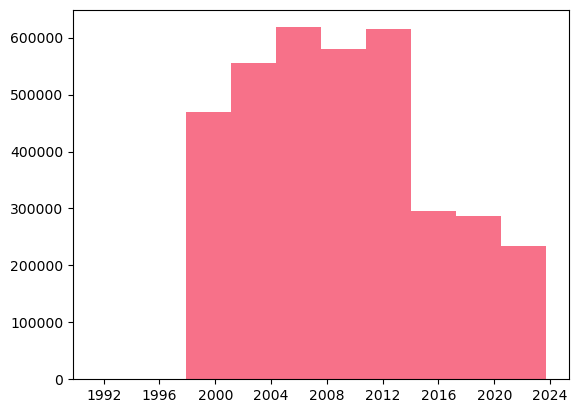

In [172]:
plt.hist(thru_dates)

# RUN 501 DATA PREP on df_with_cum_opm

In [37]:
df_work = load_feather('df_with_cum_opm')

 df_with_cum_opm Loaded!!  - (07.05 seconds and 3,547.081 MB of memory)


In [54]:
print(f"\n Generating and removing a list of officers who ONLY have null values for their officer appointment dates...")
# Count the pid_pde's in df_work
df_oad = df_work[['pid_pde','ofcr_apnt_dt']]
before_nn_set = set(df_oad.pid_pde.unique().tolist())
print(f" There are {len(before_nn_set):,} unique pid_pde's in df_work")

# Now eliminate rows with a null value for ofcr_apnt_dtabs
df_oad = df_oad[df_oad.ofcr_apnt_dt.notna()]

# Count the unique pid_pde's after dropping those NaN rows
after_nn_set = set(df_oad.pid_pde.unique().tolist())
print(f" There are {len(after_nn_set):,} unique pid_pde's in df_work after dropping pid_pde's with only null ofcr_apnt_dt values.")
print(f"We lost {len(before_nn_set) - len(after_nn_set):,} officers who only had null ofcr_apnt_dt values.  Oh well.")

# Generate a list of the officers with only null appointment dates 
null_apnt_dt_pids_list = before_nn_set - after_nn_set
print(f"\nThere are {len(null_apnt_dt_pids_list):,} pids with null 'ofcr_apnt_dt' values.")

# Now make a list of pids who still have duplicate ofcr_apnt_dt values after dropping nulls
print(f"\n Now making a list of pids who still have duplicate ofcr_apnt_dt values after dropping nulls...")
df_oad = df_oad.drop_duplicates()
countr_dict2 = Counter(df_oad.pid_pde.tolist())
dup_list_apnt_dt_no_nulls = [p for p,v in countr_dict2.items() if v>1]
print(f"'dup_list_apnt_dt_no_nulls' has {len(dup_list_apnt_dt_no_nulls):,} pids.")

print(f"\n So now we will remove the officers who have duplicate officer appointment dates...")
df_work = df_work[~df_work.pid_pde.isin(dup_list_apnt_dt_no_nulls)]
print(f"This leaves us with {df_work.pid_pde.nunique():,} officers in df_work, all with unique appointment dates")


 Generating and removing a list of officers who ONLY have null values for their officer appointment dates...
 There are 152,529 unique pid_pde's in df_work
 There are 149,555 unique pid_pde's in df_work after dropping pid_pde's with only null ofcr_apnt_dt values.
We lost 2,974 officers who only had null ofcr_apnt_dt values.  Oh well.

There are 2,974 pids with null 'ofcr_apnt_dt' values.

 Now making a list of pids who still have duplicate ofcr_apnt_dt values after dropping nulls...
'dup_list_apnt_dt_no_nulls' has 12,608 pids.

 So now we will remove the officers who have duplicate officer appointment dates...
This leaves us with 139,921 officers in df_work, all with unique appointment dates


In [ ]:
df_work.dor_cpt.unique().tolist()

In [29]:
print(f"\n Now lets find pids with null ppln_pgrd_eff_dt values...")
# now lets find pids with null ppln_pgrd_eff_dt values
null_pgrd_dt_pids_list = df_work[df_work['ppln_pgrd_eff_dt'].isna()]['pid_pde'].unique().tolist()
nul_pgrd_dt_len = len(null_pgrd_dt_pids_list)
print(f"There are {nul_pgrd_dt_len:,} pids with null 'ppln_pgrd_eff_dt' values.")


 Now lets find pids with null ppln_pgrd_eff_dt values...
There are 4,698 pids with null 'ppln_pgrd_eff_dt' values.


In [30]:
# now make a new df (df_2) without rows with null values for ofcr_apnt_dt
df_2 = df_work.copy()
print(f"Dropping (dropna) 'ofcr_apnt_dt' values for 'df_2'...")
df_2 = df_2.dropna(subset='ofcr_apnt_dt',axis=0)
null_apnt_dt_pids_list2 = df_2[df_2['ofcr_apnt_dt'].isna()]['pid_pde'].unique().tolist()
len(null_apnt_dt_pids_list2)

Dropping (dropna) 'ofcr_apnt_dt' values for 'df_2'...


0

In [33]:
# Now make a list of pids who still have duplicate ofcr_apnt_dt values after dropping nulls
countr_dict2 = Counter(list(df_2[['pid_pde','ofcr_apnt_dt']].drop_duplicates().pid_pde))
dup_list_apnt_dt_no_nulls = [p for p,v in countr_dict2.items() if v>1]
print(f"'dup_list_apnt_dt_no_nulls' has {len(dup_list_apnt_dt_no_nulls):,} pids.")

'dup_list_apnt_dt_no_nulls' has 12,608 pids.


In [34]:
# now make a new df (df_3) without rows with null values for ppln_pgrd_eff_dt
df_3 = df_work.copy()
print(f"Dropping (dropna) 'ppln_pgrd_eff_dt' values for 'df_3'...")
df_3 = df_3.dropna(subset='ppln_pgrd_eff_dt',axis=0)
null_pgrd_dt_pids_list = df_3[df_3['ppln_pgrd_eff_dt'].isna()]['pid_pde'].unique().tolist()
len(null_pgrd_dt_pids_list)

Dropping (dropna) 'ppln_pgrd_eff_dt' values for 'df_3'...


0

In [35]:
# Now make a list of pids who still have duplicate ppln_pgrd_eff_dt values after dropping nulls
countr_dict3 = Counter(list(df_3[['pid_pde','ppln_pgrd_eff_dt']].drop_duplicates().pid_pde))
dup_list_pgrd_dt_no_nulls = [p for p,v in countr_dict3.items() if v>1]
print(f"'dup_list_pgrd_dt_no_nulls' has {len(dup_list_pgrd_dt_no_nulls):,} pids.")

set_apnt_list = set(dup_list_apnt_dt_no_nulls)
set_pgrd_list = set(dup_list_pgrd_dt_no_nulls)
count = len(set_apnt_list.intersection(set_pgrd_list))
remove_pids_set = set_apnt_list | set_pgrd_list
print(len(set_apnt_list)+len(set_pgrd_list))
print(count)
print(len(remove_pids_set))

'dup_list_pgrd_dt_no_nulls' has 130,400 pids.
143008
12393
130615


In [36]:
# make df_5 by removing duplicate apnt date pids and pgrd_dt pids
df_len = len(df_work)
print("---> Creating df_5 by eliminating pids with ambiguous dates of rank and appointment dates.")
df_len = len(df_work)
print(f"'df_work' has {df_len:,} rows.")
len_pids_df_work = len(df_work.pid_pde.unique().tolist())
print(f"df_work currently has {len_pids_df_work:,} unique pid_pde's.") 
df_5 =  df_work.copy()
print(f"Cutting (cut_pids()) {len(remove_pids_set):,} pids with ambiguous dates of rank and appointment dates")
df_5 = cut_pids(df_work.copy(),remove_pids_set)
print(f"df_5 Now has {len(df_5):,} rows after dropping {df_len-len(df_5):,} rows.")
pids_df_5 = len_pids_df_5 = len(df_5.pid_pde.unique().tolist())
pids_diff = len_pids_df_work - len_pids_df_5
print(f"df_5 Now has {len_pids_df_5:,} unique pid_pde's after dropping {pids_diff :,} pids.") 
print(f"For a reduction of {(pids_diff)*100/len_pids_df_work:,.2f} %.") 

# make df_6 by removing all null dates of rank and appointment dates
df_6 = df_5.copy()
df_6 = df_6.dropna(subset='ppln_pgrd_eff_dt',axis=0)
df_6 = df_6.dropna(subset='ofcr_apnt_dt',axis=0)

# Add yg column to df_6
df_6['yg'] = df_6['ofcr_apnt_dt'].apply(get_fy)
df_6 = move_column_after(df_6,'yg','ofcr_apnt_dt')

# Create yg_dict and dor_dicts for year group and date of rank
df_yg_dict = dict(zip(df_6['pid_pde'], df_6['yg']))
df_dor_cpt_dict = dict(zip(df_6['pid_pde'], df_6['ofcr_apnt_dt']))

df_501_filtered_pids_list = list(df_5.pid_pde.unique())
df_5_pids_list = list(df_5.pid_pde.unique())
print(f"df_501_fdf_501_filtered_pids_list has {len(df_501_filtered_pids_list):,} pids.")
print(f"df_5_pids_list has {len(df_5_pids_list):,} pids.")
diff_set = set(df_5_pids_list).difference(set(list(df_501_filtered_pids_list)))
count = len(diff_set)
print(f"For a differenece of {count:,} unique pids")
new_list = list(set(df_501_filtered_pids_list) - set(df_5_pids_list))
print(f"However the list of items in df_501_filtered_pids_list not in the dictionaries is {new_list}.")

# Now let's make the final df_501_filtered dataframe
df_7 = df_5[['pid_pde']].drop_duplicates()

df_8 = df_501_base[df_501_base['pid_pde'].isin(df_7['pid_pde'])].copy()
display(df_8.columns)

#  Now add a 'yg' column and put it right after 'ofcr_apnt_dt'
df_8['yg'] = df_8['pid_pde'].map(df_yg_dict)
df_8 = move_column_after(df_8, 'yg', 'ofcr_apnt_dt')
display(df_8.columns)

#  Now add a 'dor_cpt' column and put it right after 'ppln_pgrd_eff_dt'
df_8['dor_cpt'] = df_8['pid_pde'].map(df_dor_cpt_dict)
df_8 = move_column_after(df_8, 'dor_cpt', 'ppln_pgrd_eff_dt')
display(df_8.columns)

print(f"df_8 has {len(df_8.pid_pde.unique()):,} pids.")

---> Creating df_5 by eliminating pids with ambiguous dates of rank and appointment dates.
'df_work' has 5,095,046 rows.
df_work currently has 152,529 unique pid_pde's.
Cutting (cut_pids()) 130,615 pids with ambiguous dates of rank and appointment dates
df_5 Now has 181,188 rows after dropping 4,913,858 rows.
df_5 Now has 21,914 unique pid_pde's after dropping 130,615 pids.
For a reduction of 85.63 %.
df_501_fdf_501_filtered_pids_list has 21,914 pids.
df_5_pids_list has 21,914 pids.
For a differenece of 0 unique pids
However the list of items in df_501_filtered_pids_list not in the dictionaries is [].


NameError: name 'df_501_base' is not defined